In [1]:
# ==============================
# 5-Fold Video Data Pipeline  (Leakage-Safe + Stratified Version)
# Real Life Violence Dataset
# Classes: Violence / NonViolence
# ==============================

import cv2
from pathlib import Path
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
import os

# -----------------------------
# Paths and Parameters
# -----------------------------
dataset_root = Path("Real Life Violence Dataset")
frames_root = Path("RealLifeFrames")
frames_root.mkdir(exist_ok=True, parents=True)

classes = ["Violence", "NonViolence"]
K = 5

# -----------------------------
# Step 1: Collect all videos and labels
# -----------------------------
all_videos = []
all_labels = []

for class_name in classes:
    class_folder = dataset_root / class_name

    if not class_folder.exists():
        raise ValueError(f"Folder not found: {class_folder}")

    for video_file in class_folder.glob("*.*"):
        all_videos.append(video_file)
        all_labels.append(class_name)

print(f"Total videos found: {len(all_videos)}")

print("\nClass distribution:")
print(pd.Series(all_labels).value_counts())

# -----------------------------
# Step 2: Extract frames from all videos
# -----------------------------
def extract_frames(video_path, save_dir):
    save_dir.mkdir(parents=True, exist_ok=True)

    existing_frames = list(save_dir.glob("*.jpg"))
    if len(existing_frames) > 0:
        return len(existing_frames)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        print(f"Warning: could not open video: {video_path}")
        return 0

    frame_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_filename = save_dir / f"{video_path.stem}_frame{frame_count:04d}.jpg"
        cv2.imwrite(str(frame_filename), frame)

        frame_count += 1

    cap.release()

    return frame_count


print("\nExtracting frames from all videos...")

for video in tqdm(all_videos):
    video_folder = frames_root / video.stem
    extract_frames(video, video_folder)

# -----------------------------
# Step 3: Stratified K-Fold splitting and CSV creation
# -----------------------------
skf = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=42
)

for fold_idx, (train_indices, val_indices) in enumerate(
    skf.split(all_videos, all_labels),
    1
):
    print(f"\nProcessing Fold {fold_idx}...")

    train_videos = [all_videos[i] for i in train_indices]
    val_videos   = [all_videos[i] for i in val_indices]

    train_labels = [all_labels[i] for i in train_indices]
    val_labels   = [all_labels[i] for i in val_indices]

    # -----------------------------
    # Leakage check at video level
    # -----------------------------
    train_video_ids = set([v.stem for v in train_videos])
    val_video_ids   = set([v.stem for v in val_videos])

    overlap = train_video_ids.intersection(val_video_ids)

    print(f"Train videos: {len(train_video_ids)}")
    print(f"Val videos  : {len(val_video_ids)}")
    print(f"Overlap     : {len(overlap)}")

    if len(overlap) > 0:
        raise RuntimeError(f"Leakage detected in Fold {fold_idx}: {overlap}")

    print("\nTrain class distribution:")
    print(pd.Series(train_labels).value_counts())

    print("\nVal class distribution:")
    print(pd.Series(val_labels).value_counts())

    # -----------------------------------------
    # Leakage-safe CSV creation
    # -----------------------------------------
    def create_csv_leak_safe(video_list, label_list, csv_path):
        rows = []

        for video_path, label in zip(video_list, label_list):
            video_id = video_path.stem
            frame_folder = frames_root / video_id

            frame_files = sorted(frame_folder.glob("*.jpg"))

            for frame_file in frame_files:
                rows.append([
                    str(frame_file),
                    label,
                    video_id
                ])

        df = pd.DataFrame(
            rows,
            columns=["frame", "class", "video_id"]
        )

        df.to_csv(csv_path, index=False)

        return df

    train_csv = frames_root / f"train_fold_{fold_idx}.csv"
    val_csv   = frames_root / f"val_fold_{fold_idx}.csv"

    train_df = create_csv_leak_safe(train_videos, train_labels, train_csv)
    val_df   = create_csv_leak_safe(val_videos, val_labels, val_csv)

    print(f"\nFold {fold_idx} CSVs saved:")
    print(f"Train CSV: {train_csv.name} | Rows: {len(train_df)}")
    print(f"Val CSV  : {val_csv.name} | Rows: {len(val_df)}")

print("\n✅ Stratified 5-Fold pipeline complete!")
print("   All CSV files are leakage-safe and ready for training and validation.")

Total videos found: 2000

Class distribution:
Violence       1000
NonViolence    1000
Name: count, dtype: int64

Extracting frames from all videos...


100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [26:20<00:00,  1.27it/s]



Processing Fold 1...
Train videos: 1600
Val videos  : 400
Overlap     : 0

Train class distribution:
Violence       800
NonViolence    800
Name: count, dtype: int64

Val class distribution:
Violence       200
NonViolence    200
Name: count, dtype: int64

Fold 1 CSVs saved:
Train CSV: train_fold_1.csv | Rows: 234128
Val CSV  : val_fold_1.csv | Rows: 53241

Processing Fold 2...
Train videos: 1600
Val videos  : 400
Overlap     : 0

Train class distribution:
Violence       800
NonViolence    800
Name: count, dtype: int64

Val class distribution:
Violence       200
NonViolence    200
Name: count, dtype: int64

Fold 2 CSVs saved:
Train CSV: train_fold_2.csv | Rows: 218288
Val CSV  : val_fold_2.csv | Rows: 69081

Processing Fold 3...
Train videos: 1600
Val videos  : 400
Overlap     : 0

Train class distribution:
Violence       800
NonViolence    800
Name: count, dtype: int64

Val class distribution:
Violence       200
NonViolence    200
Name: count, dtype: int64

Fold 3 CSVs saved:
Train CSV

In [2]:
# ============================================================
# CLEAN SINGLE-MODE KEYFRAME EXTRACTION PIPELINE
# REAL LIFE VIOLENCE DATASET
#
# Final available modes:
#   1) PROPOSED_FUSED
#   2) PROPOSED_SPATIAL_ONLY
#   3) PROPOSED_TEMPORAL_ONLY
#
# Input:
#   RealLifeFrames/train_fold_1.csv
#   RealLifeFrames/val_fold_1.csv
#   ...
#
# Expected CSV columns:
#   frame or frame_path
#   class
#   video_id or video_name
#
# Output:
#   RealLifeNumpy/{SELECTED_MODE}/fold_i/{split}/{class}/{video_id}.npy
#
# Saved NPY shape:
#   [T_selected, 224, 224, 3]
#
# Classes:
#   Violence
#   NonViolence
#
# Notes:
#   - Only one proposed mode runs.
#   - Old output of selected mode is removed if CLEAR_OUTPUT=True.
#   - Proposed modes use train-only Otsu threshold.
#   - Saved frames are BGR because OpenCV is used.
# ============================================================

import os
import cv2
import json
import time
import shutil
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from skimage.filters import threshold_otsu
from concurrent.futures import ThreadPoolExecutor, as_completed


# ============================================================
# Basic setup
# ============================================================

try:
    cv2.setNumThreads(1)
except Exception:
    pass


# ============================================================
# User settings
# ============================================================

FRAMES_ROOT = Path("RealLifeFrames")
NPY_ROOT = Path("RealLifeNumpy")
KEYFRAME_ROOT = Path("RealLifeKeyFrames")
SCORE_CACHE_ROOT = Path("RealLifeScoreCache")

CLASSES = ["Violence", "NonViolence"]
RUN_FOLDS = [1, 2, 3, 4, 5]


# ============================================================
# Select exactly one proposed mode
# ============================================================

SELECTED_MODE = "PROPOSED_FUSED"

# SELECTED_MODE = "PROPOSED_FUSED"
# SELECTED_MODE = "PROPOSED_SPATIAL_ONLY"
# SELECTED_MODE = "PROPOSED_TEMPORAL_ONLY"


# ============================================================
# Scoring settings
# ============================================================

SCORE_IMG_SIZE = 224
SCORE_SIGNATURE = f"reallife_score_sz{SCORE_IMG_SIZE}_v1"
EPS = 1e-8


# ============================================================
# Clean-run settings
# ============================================================

USE_SCORE_CACHE = True
REBUILD_SCORE_CACHE = True
CLEAR_SCORE_CACHE = True

CLEAR_OUTPUT = True
SKIP_EXISTING_NPY = False


# ============================================================
# Speed settings
# ============================================================

MAX_SCORE_WORKERS = min(8, max(1, (os.cpu_count() or 4) - 1))


# ============================================================
# NPY saving settings
# ============================================================

SAVE_NPY_ARRAYS = True
SAVE_KEYFRAME_IMAGES = False

RESIZE_BEFORE_SAVING_NPY = True
NPY_SAVE_SIZE = 224
SAVE_FRAMES_AS_UINT8 = True

KEEP_FIRST_LAST_IN_PROPOSED = True


# ============================================================
# Mode definitions
# ============================================================

PROPOSED_FUSED = "PROPOSED_FUSED"
PROPOSED_SPATIAL_ONLY = "PROPOSED_SPATIAL_ONLY"
PROPOSED_TEMPORAL_ONLY = "PROPOSED_TEMPORAL_ONLY"

PROPOSED_MODES = [
    PROPOSED_FUSED,
    PROPOSED_SPATIAL_ONLY,
    PROPOSED_TEMPORAL_ONLY,
]

if SELECTED_MODE not in PROPOSED_MODES:
    raise ValueError(
        f"Invalid SELECTED_MODE: {SELECTED_MODE}\n"
        f"Available proposed modes: {PROPOSED_MODES}"
    )

OUTPUT_MODE = SELECTED_MODE


# ============================================================
# Create folders
# ============================================================

NPY_ROOT.mkdir(parents=True, exist_ok=True)
KEYFRAME_ROOT.mkdir(parents=True, exist_ok=True)
SCORE_CACHE_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# Clean old output/cache
# ============================================================

mode_npy_root = NPY_ROOT / OUTPUT_MODE
mode_key_root = KEYFRAME_ROOT / OUTPUT_MODE
score_cache_dir = SCORE_CACHE_ROOT / SCORE_SIGNATURE

if CLEAR_OUTPUT:
    if mode_npy_root.exists():
        print(f"Removing old NPY output: {mode_npy_root}")
        shutil.rmtree(mode_npy_root)

    if mode_key_root.exists():
        print(f"Removing old keyframe output: {mode_key_root}")
        shutil.rmtree(mode_key_root)

if CLEAR_SCORE_CACHE:
    if score_cache_dir.exists():
        print(f"Removing old score cache: {score_cache_dir}")
        shutil.rmtree(score_cache_dir)

mode_npy_root.mkdir(parents=True, exist_ok=True)
mode_key_root.mkdir(parents=True, exist_ok=True)


# ============================================================
# Print config
# ============================================================

print("=" * 100)
print("SINGLE-MODE PROPOSED KEYFRAME EXTRACTION - REAL LIFE")
print("=" * 100)

print("Selected mode       :", SELECTED_MODE)
print("Output mode         :", OUTPUT_MODE)
print("Frames root         :", FRAMES_ROOT)
print("NPY root            :", NPY_ROOT)
print("Output folder       :", NPY_ROOT / OUTPUT_MODE)
print("Score cache root    :", SCORE_CACHE_ROOT)

print("\nScoring:")
print("Score image size    :", SCORE_IMG_SIZE)
print("Score signature     :", SCORE_SIGNATURE)

print("\nClean run:")
print("Clear output        :", CLEAR_OUTPUT)
print("Clear score cache   :", CLEAR_SCORE_CACHE)
print("Rebuild score cache :", REBUILD_SCORE_CACHE)
print("Skip existing NPY   :", SKIP_EXISTING_NPY)

print("\nSpeed:")
print("Workers             :", MAX_SCORE_WORKERS)

print("=" * 100)


# ============================================================
# Utility functions
# ============================================================

def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def safe_name(name):
    name = str(name)
    bad_chars = ['/', '\\', ':', '*', '?', '"', '<', '>', '|']

    for ch in bad_chars:
        name = name.replace(ch, "_")

    return name


def resolve_frame_path(path):
    path = Path(str(path))

    if path.exists():
        return path

    alt_path = FRAMES_ROOT / path

    if alt_path.exists():
        return alt_path

    return path


def get_frame_col(df):
    if "frame" in df.columns:
        return "frame"

    if "frame_path" in df.columns:
        return "frame_path"

    raise ValueError("CSV must contain 'frame' or 'frame_path' column.")


def get_video_col(df):
    if "video_id" in df.columns:
        return "video_id"

    if "video_name" in df.columns:
        return "video_name"

    return None


def extract_frame_index(path):
    stem = Path(str(path)).stem

    if "_frame" in stem:
        try:
            return int(stem.split("_frame")[-1])
        except Exception:
            pass

    digits = "".join([c for c in stem if c.isdigit()])

    if digits:
        return int(digits)

    return -1


def sort_frame_paths(frame_paths):
    return sorted(frame_paths, key=lambda x: extract_frame_index(x))


def make_class_aware_video_set(df):
    frame_col = get_frame_col(df)
    video_col = get_video_col(df)

    df = df.copy()

    if video_col is None:
        df["video_id_auto"] = df[frame_col].apply(lambda x: Path(str(x)).parent.name)
        video_col = "video_id_auto"

    ids = set()
    temp = df[["class", video_col]].drop_duplicates()

    for _, row in temp.iterrows():
        ids.add(f"{row['class']}::{row[video_col]}")

    return ids


def prepare_video_groups(df):
    frame_col = get_frame_col(df)
    video_col = get_video_col(df)

    df = df.copy()

    if video_col is None:
        df["video_id_auto"] = df[frame_col].apply(lambda x: Path(str(x)).parent.name)
        video_col = "video_id_auto"

    groups = []

    for cls in CLASSES:
        cls_df = df[df["class"] == cls].copy()

        for video_id, group in cls_df.groupby(video_col):
            frame_paths = sort_frame_paths(group[frame_col].tolist())

            if len(frame_paths) == 0:
                continue

            groups.append({
                "class": cls,
                "video_id": str(video_id),
                "safe_video_id": safe_name(video_id),
                "frame_paths": frame_paths,
            })

    return groups


def get_selected_extreme_info(stats_df):
    empty = {
        "min_selected_frames": np.nan,
        "max_selected_frames": np.nan,
        "avg_selected_frames": np.nan,
        "min_selected_video_id": "",
        "max_selected_video_id": "",
        "min_selected_class": "",
        "max_selected_class": "",
        "min_selected_split": "",
        "max_selected_split": "",
        "min_selected_fold": np.nan,
        "max_selected_fold": np.nan,
    }

    if stats_df is None or len(stats_df) == 0:
        return empty

    if "selected_frames" not in stats_df.columns:
        return empty

    min_idx = stats_df["selected_frames"].idxmin()
    max_idx = stats_df["selected_frames"].idxmax()

    min_row = stats_df.loc[min_idx]
    max_row = stats_df.loc[max_idx]

    return {
        "min_selected_frames": int(min_row["selected_frames"]),
        "max_selected_frames": int(max_row["selected_frames"]),
        "avg_selected_frames": float(stats_df["selected_frames"].mean()),

        "min_selected_video_id": str(min_row.get("video_id", "")),
        "max_selected_video_id": str(max_row.get("video_id", "")),

        "min_selected_class": str(min_row.get("class", "")),
        "max_selected_class": str(max_row.get("class", "")),

        "min_selected_split": str(min_row.get("split", "")),
        "max_selected_split": str(max_row.get("split", "")),

        "min_selected_fold": int(min_row.get("fold", -1)) if "fold" in min_row else np.nan,
        "max_selected_fold": int(max_row.get("fold", -1)) if "fold" in max_row else np.nan,
    }


def get_npy_shape_safe(path):
    try:
        arr = np.load(path, mmap_mode="r")
        return tuple(arr.shape), str(arr.dtype)
    except Exception:
        return (), ""


# ============================================================
# Score functions
# ============================================================

def minmax_normalize(arr):
    arr = np.asarray(arr, dtype=np.float32)

    if len(arr) == 0:
        return arr

    mn = float(np.min(arr))
    mx = float(np.max(arr))

    if mx - mn < EPS:
        return np.zeros_like(arr, dtype=np.float32)

    return (arr - mn) / (mx - mn + EPS)


def compute_spatial_components(gray):
    contrast = np.std(gray)

    edges = cv2.Canny(gray, 100, 200)
    edge_strength = edges.mean() / 255.0

    lap = cv2.Laplacian(gray, cv2.CV_64F)
    clarity = lap.var()

    return contrast, edge_strength, clarity


def temporal_motion_score(prev_gray, curr_gray):
    return np.mean(
        np.abs(
            curr_gray.astype(np.float32) - prev_gray.astype(np.float32)
        )
    )


def adaptive_fusion_score(spatial_scores, temporal_scores):
    spatial_scores = np.asarray(spatial_scores, dtype=np.float32)
    temporal_scores = np.asarray(temporal_scores, dtype=np.float32)

    ws = spatial_scores / (spatial_scores + temporal_scores + EPS)
    wt = temporal_scores / (spatial_scores + temporal_scores + EPS)

    fused = ws * spatial_scores + wt * temporal_scores

    return fused.astype(np.float32)


def compute_scores_for_video(frame_paths):
    frame_paths = sort_frame_paths(frame_paths)

    contrasts = []
    edges = []
    clarities = []
    motions = []

    prev_gray = None

    for idx, fp in enumerate(frame_paths):
        src = resolve_frame_path(fp)

        gray = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE)

        if gray is None:
            contrasts.append(0.0)
            edges.append(0.0)
            clarities.append(0.0)
            motions.append(0.0)
            continue

        gray = cv2.resize(
            gray,
            (SCORE_IMG_SIZE, SCORE_IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        c, e, cl = compute_spatial_components(gray)

        contrasts.append(c)
        edges.append(e)
        clarities.append(cl)

        if idx == 0 or prev_gray is None:
            motions.append(0.0)
        else:
            motions.append(temporal_motion_score(prev_gray, gray))

        prev_gray = gray

    contrasts = np.asarray(contrasts, dtype=np.float32)
    edges = np.asarray(edges, dtype=np.float32)
    clarities = np.asarray(clarities, dtype=np.float32)
    motions = np.asarray(motions, dtype=np.float32)

    contrast_norm = minmax_normalize(contrasts)
    edge_norm = minmax_normalize(edges)
    clarity_norm = minmax_normalize(clarities)

    spatial_score = (contrast_norm + edge_norm + clarity_norm) / 3.0
    temporal_score = minmax_normalize(motions)
    fused_score = adaptive_fusion_score(spatial_score, temporal_score)

    return {
        "contrast": contrasts,
        "edge": edges,
        "clarity": clarities,
        "raw_motion": motions,
        "spatial_score": spatial_score.astype(np.float32),
        "temporal_score": temporal_score.astype(np.float32),
        "fused_score": fused_score.astype(np.float32),
    }


def get_score_vector(score_dict, mode):
    if mode == PROPOSED_FUSED:
        return score_dict["fused_score"]

    if mode == PROPOSED_SPATIAL_ONLY:
        return score_dict["spatial_score"]

    if mode == PROPOSED_TEMPORAL_ONLY:
        return score_dict["temporal_score"]

    raise ValueError(f"Unknown proposed mode: {mode}")


# ============================================================
# Score cache
# ============================================================

def collect_unique_video_groups():
    unique = {}

    for fold_idx in RUN_FOLDS:
        for split_name in ["train", "val"]:
            csv_path = FRAMES_ROOT / f"{split_name}_fold_{fold_idx}.csv"

            if not csv_path.exists():
                continue

            df = pd.read_csv(csv_path)
            groups = prepare_video_groups(df)

            for item in groups:
                key = f"{item['class']}::{item['video_id']}"
                unique[key] = item

    return list(unique.values())


def get_score_cache_path(item):
    return (
        SCORE_CACHE_ROOT /
        SCORE_SIGNATURE /
        item["class"] /
        f"{item['safe_video_id']}.npz"
    )


def save_score_cache(item, score_dict):
    path = get_score_cache_path(item)
    path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        path,
        total_frames=np.array([len(item["frame_paths"])], dtype=np.int64),
        contrast=score_dict["contrast"],
        edge=score_dict["edge"],
        clarity=score_dict["clarity"],
        raw_motion=score_dict["raw_motion"],
        spatial_score=score_dict["spatial_score"],
        temporal_score=score_dict["temporal_score"],
        fused_score=score_dict["fused_score"],
    )

    return path


def load_score_cache(item):
    path = get_score_cache_path(item)

    if not path.exists():
        raise FileNotFoundError(f"Score cache not found: {path}")

    data = np.load(path)

    cached_total = int(data["total_frames"][0])
    current_total = len(item["frame_paths"])

    if cached_total != current_total:
        raise RuntimeError(
            f"Score cache mismatch for {item['video_id']}: "
            f"cache={cached_total}, current={current_total}"
        )

    return {
        "contrast": data["contrast"].astype(np.float32),
        "edge": data["edge"].astype(np.float32),
        "clarity": data["clarity"].astype(np.float32),
        "raw_motion": data["raw_motion"].astype(np.float32),
        "spatial_score": data["spatial_score"].astype(np.float32),
        "temporal_score": data["temporal_score"].astype(np.float32),
        "fused_score": data["fused_score"].astype(np.float32),
    }


def compute_or_load_score_cache(item):
    path = get_score_cache_path(item)

    if USE_SCORE_CACHE and path.exists() and not REBUILD_SCORE_CACHE:
        try:
            _ = load_score_cache(item)

            return {
                "status": "cached",
                "class": item["class"],
                "video_id": item["video_id"],
                "total_frames": len(item["frame_paths"]),
                "cache_path": str(path),
                "error": "",
            }

        except Exception:
            pass

    try:
        score_dict = compute_scores_for_video(item["frame_paths"])
        save_score_cache(item, score_dict)

        return {
            "status": "computed",
            "class": item["class"],
            "video_id": item["video_id"],
            "total_frames": len(item["frame_paths"]),
            "cache_path": str(path),
            "error": "",
        }

    except Exception as e:
        return {
            "status": "failed",
            "class": item["class"],
            "video_id": item["video_id"],
            "total_frames": len(item["frame_paths"]),
            "cache_path": str(path),
            "error": str(e),
        }


def ensure_score_cache():
    print("\n" + "=" * 100)
    print("GLOBAL SCORE CACHE")
    print("=" * 100)

    unique_groups = collect_unique_video_groups()

    print(f"Unique videos : {len(unique_groups):,}")
    print(f"Workers       : {MAX_SCORE_WORKERS}")
    print(f"Signature     : {SCORE_SIGNATURE}")

    rows = []
    start = time.perf_counter()

    with ThreadPoolExecutor(max_workers=MAX_SCORE_WORKERS) as executor:
        futures = [
            executor.submit(compute_or_load_score_cache, item)
            for item in unique_groups
        ]

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Score cache"
        ):
            rows.append(future.result())

    elapsed = time.perf_counter() - start

    df = pd.DataFrame(rows)

    out_dir = SCORE_CACHE_ROOT / SCORE_SIGNATURE
    out_dir.mkdir(parents=True, exist_ok=True)

    summary_path = out_dir / "score_cache_summary.csv"
    df.to_csv(summary_path, index=False)

    print("\nScore cache status:")
    print(df["status"].value_counts(dropna=False))
    print("Score cache time:", format_seconds(elapsed))
    print("Saved:", summary_path)

    if (df["status"] == "failed").any():
        print(df[df["status"] == "failed"].head(10))
        raise RuntimeError("Some videos failed during score cache computation.")

    print("=" * 100)

    return df


# ============================================================
# Proposed selection
# ============================================================

def select_proposed_indices(scores, threshold):
    total = len(scores)

    if total <= 0:
        return np.array([], dtype=np.int64)

    selected = np.where(scores >= threshold)[0].astype(np.int64)

    if KEEP_FIRST_LAST_IN_PROPOSED:
        selected = np.concatenate([
            np.array([0], dtype=np.int64),
            selected,
            np.array([total - 1], dtype=np.int64),
        ])

    selected = selected[(selected >= 0) & (selected < total)]
    selected = np.sort(np.unique(selected))

    return selected.astype(np.int64)


def get_selected_indices_for_mode(item, mode, threshold):
    score_dict = load_score_cache(item)
    scores = get_score_vector(score_dict, mode)

    selected_indices = select_proposed_indices(
        scores=scores,
        threshold=threshold
    )

    return selected_indices


# ============================================================
# NPY saving
# ============================================================

def read_selected_frames(frame_paths, selected_indices):
    images = []
    frame_indices = []
    frame_paths_out = []

    for idx in selected_indices:
        src_original = frame_paths[int(idx)]
        src = resolve_frame_path(src_original)

        img = cv2.imread(str(src), cv2.IMREAD_COLOR)

        if img is None:
            continue

        if RESIZE_BEFORE_SAVING_NPY:
            img = cv2.resize(
                img,
                (NPY_SAVE_SIZE, NPY_SAVE_SIZE),
                interpolation=cv2.INTER_AREA
            )

        if SAVE_FRAMES_AS_UINT8:
            img = img.astype(np.uint8)
        else:
            img = img.astype(np.float32) / 255.0

        images.append(img)
        frame_indices.append(extract_frame_index(src_original))
        frame_paths_out.append(str(src_original))

    if len(images) > 0:
        arr = np.stack(images, axis=0)
    else:
        if SAVE_FRAMES_AS_UINT8:
            arr = np.empty((0, NPY_SAVE_SIZE, NPY_SAVE_SIZE, 3), dtype=np.uint8)
        else:
            arr = np.empty((0, NPY_SAVE_SIZE, NPY_SAVE_SIZE, 3), dtype=np.float32)

    return arr, frame_indices, frame_paths_out


def save_npy_for_item(item, output_mode, fold_idx, split_name, selected_indices):
    cls = item["class"]
    safe_video_id = item["safe_video_id"]
    frame_paths = item["frame_paths"]

    out_dir = NPY_ROOT / output_mode / f"fold_{fold_idx}" / split_name / cls
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"{safe_video_id}.npy"

    if SKIP_EXISTING_NPY and out_path.exists():
        shape, dtype = get_npy_shape_safe(out_path)

        frame_indices = [
            extract_frame_index(frame_paths[int(idx)])
            for idx in selected_indices
        ]

        frame_paths_out = [
            str(frame_paths[int(idx)])
            for idx in selected_indices
        ]

        return {
            "path": out_path,
            "status": "skipped_existing",
            "saved_frames": int(shape[0]) if len(shape) > 0 else 0,
            "saved_height": int(shape[1]) if len(shape) >= 3 else -1,
            "saved_width": int(shape[2]) if len(shape) >= 3 else -1,
            "frame_indices": frame_indices,
            "frame_paths": frame_paths_out,
        }

    arr, frame_indices, frame_paths_out = read_selected_frames(
        frame_paths,
        selected_indices
    )

    np.save(out_path, arr)

    return {
        "path": out_path,
        "status": "saved",
        "saved_frames": int(arr.shape[0]),
        "saved_height": int(arr.shape[1]) if arr.ndim == 4 else -1,
        "saved_width": int(arr.shape[2]) if arr.ndim == 4 else -1,
        "frame_indices": frame_indices,
        "frame_paths": frame_paths_out,
    }


# ============================================================
# Threshold
# ============================================================

def compute_train_threshold(train_groups, mode):
    scores_all = []

    for item in tqdm(train_groups, desc=f"Threshold {mode}"):
        score_dict = load_score_cache(item)
        scores = get_score_vector(score_dict, mode)
        scores_all.extend(scores.tolist())

    scores_all = np.asarray(scores_all, dtype=np.float32)

    if len(scores_all) == 0:
        raise RuntimeError(f"No train scores found for mode: {mode}")

    if np.max(scores_all) - np.min(scores_all) < EPS:
        return 0.0

    return float(threshold_otsu(scores_all))


# ============================================================
# Fold processing
# ============================================================

def process_fold(mode, output_mode, fold_idx):
    fold_start = time.perf_counter()

    train_csv = FRAMES_ROOT / f"train_fold_{fold_idx}.csv"
    val_csv = FRAMES_ROOT / f"val_fold_{fold_idx}.csv"

    if not train_csv.exists() or not val_csv.exists():
        print(f"Missing CSV for fold {fold_idx}. Skipped.")
        return None, None

    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(val_csv)

    train_ids = make_class_aware_video_set(train_df)
    val_ids = make_class_aware_video_set(val_df)

    overlap = train_ids.intersection(val_ids)

    if len(overlap) > 0:
        raise RuntimeError(f"Leakage detected in fold {fold_idx}: {overlap}")

    prep_start = time.perf_counter()

    split_groups = {
        "train": prepare_video_groups(train_df),
        "val": prepare_video_groups(val_df),
    }

    prep_time = time.perf_counter() - prep_start

    phase1_start = time.perf_counter()
    threshold = compute_train_threshold(split_groups["train"], mode)
    phase1_time = time.perf_counter() - phase1_start

    phase2_start = time.perf_counter()

    stats_rows = []
    selected_rows = []

    counters = {
        "total_frames": 0,
        "total_selected": 0,
        "saved": 0,
        "skipped_existing": 0,
    }

    split_frames = {"train": 0, "val": 0}
    split_selected = {"train": 0, "val": 0}
    split_videos = {"train": 0, "val": 0}

    class_frames = {
        "train": {cls: 0 for cls in CLASSES},
        "val": {cls: 0 for cls in CLASSES},
    }

    class_selected = {
        "train": {cls: 0 for cls in CLASSES},
        "val": {cls: 0 for cls in CLASSES},
    }

    class_videos = {
        "train": {cls: 0 for cls in CLASSES},
        "val": {cls: 0 for cls in CLASSES},
    }

    for split_name, groups in split_groups.items():
        for item in tqdm(groups, desc=f"{output_mode}/fold_{fold_idx}/{split_name}"):

            cls = item["class"]
            video_id = item["video_id"]
            safe_video_id = item["safe_video_id"]
            frame_paths = item["frame_paths"]

            total_frames = len(frame_paths)

            if total_frames == 0:
                continue

            selected_indices = get_selected_indices_for_mode(
                item=item,
                mode=mode,
                threshold=threshold,
            )

            selected_indices = np.asarray(selected_indices, dtype=np.int64)
            selected_indices = selected_indices[
                (selected_indices >= 0) & (selected_indices < total_frames)
            ]
            selected_indices = np.sort(np.unique(selected_indices))

            selected_count = len(selected_indices)

            save_result = save_npy_for_item(
                item=item,
                output_mode=output_mode,
                fold_idx=fold_idx,
                split_name=split_name,
                selected_indices=selected_indices
            )

            status = save_result["status"]

            if status in counters:
                counters[status] += 1

            counters["total_frames"] += total_frames
            counters["total_selected"] += selected_count

            split_frames[split_name] += total_frames
            split_selected[split_name] += selected_count
            split_videos[split_name] += 1

            class_frames[split_name][cls] += total_frames
            class_selected[split_name][cls] += selected_count
            class_videos[split_name][cls] += 1

            score_dict = load_score_cache(item)

            score_vector = get_score_vector(score_dict, mode)
            spatial_scores = score_dict["spatial_score"]
            temporal_scores = score_dict["temporal_score"]
            fused_scores = score_dict["fused_score"]

            score_mean = float(np.mean(score_vector))
            score_std = float(np.std(score_vector))
            score_min = float(np.min(score_vector))
            score_max = float(np.max(score_vector))

            percent_retained = selected_count / max(total_frames, 1)
            reduction_percent = (1.0 - percent_retained) * 100.0

            stats_rows.append({
                "mode": mode,
                "output_mode": output_mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "video_id": video_id,
                "safe_video_id": safe_video_id,

                "total_frames": total_frames,
                "selected_frames": selected_count,
                "percent_retained": percent_retained,
                "reduction_percent": reduction_percent,

                "threshold": threshold,

                "score_img_size": SCORE_IMG_SIZE,
                "score_signature": SCORE_SIGNATURE,

                "score_mean": score_mean,
                "score_std": score_std,
                "score_min": score_min,
                "score_max": score_max,

                "first_selected_position": int(selected_indices[0]) if selected_count > 0 else np.nan,
                "last_selected_position": int(selected_indices[-1]) if selected_count > 0 else np.nan,

                "first_selected_frame_index": extract_frame_index(frame_paths[selected_indices[0]]) if selected_count > 0 else np.nan,
                "last_selected_frame_index": extract_frame_index(frame_paths[selected_indices[-1]]) if selected_count > 0 else np.nan,

                "npy_path": str(save_result["path"]),
                "npy_status": save_result["status"],
                "npy_saved_frames": save_result["saved_frames"],
                "npy_saved_height": save_result["saved_height"],
                "npy_saved_width": save_result["saved_width"],
                "npy_save_size": NPY_SAVE_SIZE,
                "saved_as_uint8": SAVE_FRAMES_AS_UINT8,
            })

            for order, idx in enumerate(selected_indices):
                selected_rows.append({
                    "mode": mode,
                    "output_mode": output_mode,
                    "fold": fold_idx,
                    "split": split_name,
                    "class": cls,
                    "video_id": video_id,
                    "safe_video_id": safe_video_id,

                    "frame_path": str(frame_paths[int(idx)]),
                    "frame_index": extract_frame_index(frame_paths[int(idx)]),
                    "selected_order": order,
                    "original_position": int(idx),

                    "total_frames": total_frames,
                    "selected_frames_in_video": selected_count,

                    "threshold": threshold,

                    "selected_score": float(score_vector[idx]),
                    "spatial_score": float(spatial_scores[idx]),
                    "temporal_score": float(temporal_scores[idx]),
                    "fused_score": float(fused_scores[idx]),
                })

    phase2_time = time.perf_counter() - phase2_start

    fold_out_dir = NPY_ROOT / output_mode / f"fold_{fold_idx}"
    fold_out_dir.mkdir(parents=True, exist_ok=True)

    stats_df = pd.DataFrame(stats_rows)
    selected_df = pd.DataFrame(selected_rows)

    video_stats_csv = fold_out_dir / "video_stats.csv"
    selected_frames_csv = fold_out_dir / "selected_frames.csv"

    stats_df.to_csv(video_stats_csv, index=False)
    selected_df.to_csv(selected_frames_csv, index=False)

    fold_time = time.perf_counter() - fold_start

    total_frames = counters["total_frames"]
    total_selected = counters["total_selected"]

    train_reduction = (
        1.0 - split_selected["train"] / max(split_frames["train"], 1)
    ) * 100.0

    val_reduction = (
        1.0 - split_selected["val"] / max(split_frames["val"], 1)
    ) * 100.0

    total_reduction = (
        1.0 - total_selected / max(total_frames, 1)
    ) * 100.0

    total_videos = split_videos["train"] + split_videos["val"]

    extreme = get_selected_extreme_info(stats_df)

    fold_summary = {
        "mode": mode,
        "output_mode": output_mode,
        "fold": fold_idx,

        "threshold": threshold,

        "score_img_size": SCORE_IMG_SIZE,
        "score_signature": SCORE_SIGNATURE,

        "train_videos": split_videos["train"],
        "val_videos": split_videos["val"],
        "total_videos": total_videos,

        "train_frames": split_frames["train"],
        "val_frames": split_frames["val"],
        "total_frames": total_frames,

        "train_selected": split_selected["train"],
        "val_selected": split_selected["val"],
        "total_selected": total_selected,

        "train_reduction_percent": train_reduction,
        "val_reduction_percent": val_reduction,
        "total_reduction_percent": total_reduction,

        "avg_frames_per_video": total_frames / max(total_videos, 1),
        "avg_selected_per_video": total_selected / max(total_videos, 1),

        "min_selected_frames_per_video": extreme["min_selected_frames"],
        "max_selected_frames_per_video": extreme["max_selected_frames"],
        "avg_selected_frames_per_video": extreme["avg_selected_frames"],

        "min_selected_video_id": extreme["min_selected_video_id"],
        "max_selected_video_id": extreme["max_selected_video_id"],
        "min_selected_video_class": extreme["min_selected_class"],
        "max_selected_video_class": extreme["max_selected_class"],
        "min_selected_video_split": extreme["min_selected_split"],
        "max_selected_video_split": extreme["max_selected_split"],

        "npy_root": str(NPY_ROOT),
        "npy_save_size": NPY_SAVE_SIZE,
        "saved_as_uint8": SAVE_FRAMES_AS_UINT8,

        "saved_count": counters["saved"],
        "skipped_existing_count": counters["skipped_existing"],

        "prep_time_sec": prep_time,
        "threshold_time_sec": phase1_time,
        "select_save_time_sec": phase2_time,
        "fold_total_time_sec": fold_time,

        "prep_time_hms": format_seconds(prep_time),
        "threshold_time_hms": format_seconds(phase1_time),
        "select_save_time_hms": format_seconds(phase2_time),
        "fold_total_time_hms": format_seconds(fold_time),

        "fps_total": total_frames / max(fold_time, EPS),

        "video_stats_csv": str(video_stats_csv),
        "selected_frames_csv": str(selected_frames_csv),
    }

    for split_name in ["train", "val"]:
        for cls in CLASSES:
            prefix = f"{split_name}_{cls}_"

            tf = class_frames[split_name][cls]
            sf = class_selected[split_name][cls]
            vc = class_videos[split_name][cls]

            fold_summary[f"{prefix}videos"] = vc
            fold_summary[f"{prefix}frames"] = tf
            fold_summary[f"{prefix}selected"] = sf
            fold_summary[f"{prefix}reduction_percent"] = (
                1.0 - sf / max(tf, 1)
            ) * 100.0

    print("\n" + "-" * 100)
    print(f"FOLD {fold_idx} SUMMARY | MODE: {mode} | OUTPUT: {output_mode}")
    print("-" * 100)
    print(f"Train videos       : {split_videos['train']}")
    print(f"Val videos         : {split_videos['val']}")
    print(f"Total frames       : {total_frames:,}")
    print(f"Selected frames    : {total_selected:,}")
    print(f"Reduction          : {total_reduction:.2f}%")
    print(f"Avg selected/video : {fold_summary['avg_selected_per_video']:.2f}")
    print(f"Threshold          : {threshold}")
    print(f"Saved              : {counters['saved']}")
    print(f"Fold time          : {format_seconds(fold_time)}")
    print(f"Video stats CSV    : {video_stats_csv}")
    print("-" * 100)

    return fold_summary, stats_df


# ============================================================
# Final verification
# ============================================================

def verify_npy_outputs(output_mode, max_examples=20):
    print("\n" + "=" * 110)
    print("NPY OUTPUT VERIFICATION")
    print("=" * 110)

    stats_path = NPY_ROOT / output_mode / "all_folds_video_stats.csv"

    if not stats_path.exists():
        print("Stats file not found:", stats_path)
        return

    stats_df = pd.read_csv(stats_path)

    print("Output mode       :", output_mode)
    print("Stats CSV         :", stats_path)

    print("\nSelected frames statistics:")
    print(stats_df["selected_frames"].describe())

    print("\nSelected frame count distribution:")
    print(stats_df["selected_frames"].value_counts().sort_index().head(50))

    npy_files = list((NPY_ROOT / output_mode).glob("fold_1/train/*/*.npy"))

    print("\nExample NPY shapes:")

    for p in npy_files[:max_examples]:
        arr = np.load(p, mmap_mode="r")
        print(p.name, arr.shape, arr.dtype)

    print("=" * 110)


# ============================================================
# Main run
# ============================================================

global_start = time.perf_counter()

score_cache_df = ensure_score_cache()

mode = SELECTED_MODE
output_mode = OUTPUT_MODE

print("\n" + "#" * 100)
print(f"STARTING PROPOSED MODE: {mode}")
print(f"OUTPUT MODE           : {output_mode}")
print("#" * 100)

mode_start = time.perf_counter()

fold_summaries = []
mode_video_stats = []

for fold_idx in RUN_FOLDS:
    fold_summary, stats_df = process_fold(
        mode=mode,
        output_mode=output_mode,
        fold_idx=fold_idx,
    )

    if fold_summary is not None:
        fold_summaries.append(fold_summary)

    if stats_df is not None and len(stats_df) > 0:
        mode_video_stats.append(stats_df)

mode_time = time.perf_counter() - mode_start

mode_summary_df = pd.DataFrame(fold_summaries)

mode_summary_csv = NPY_ROOT / output_mode / "all_folds_summary.csv"
mode_summary_df.to_csv(mode_summary_csv, index=False)

if len(mode_video_stats) > 0:
    mode_video_stats_df = pd.concat(mode_video_stats, ignore_index=True)
else:
    mode_video_stats_df = pd.DataFrame()

mode_video_stats_csv = NPY_ROOT / output_mode / "all_folds_video_stats.csv"
mode_video_stats_df.to_csv(mode_video_stats_csv, index=False)

if len(mode_summary_df) > 0:
    total_frames = int(mode_summary_df["total_frames"].sum())
    total_selected = int(mode_summary_df["total_selected"].sum())
    total_videos = int(mode_summary_df["total_videos"].sum())

    reduction = (
        1.0 - total_selected / max(total_frames, 1)
    ) * 100.0

    extreme = get_selected_extreme_info(mode_video_stats_df)

    avg_selected = float(mode_video_stats_df["selected_frames"].mean())
    min_selected = extreme["min_selected_frames"]
    max_selected = extreme["max_selected_frames"]

    mode_fps = total_frames / max(mode_time, EPS)

else:
    total_frames = 0
    total_selected = 0
    total_videos = 0
    reduction = np.nan
    avg_selected = np.nan
    min_selected = np.nan
    max_selected = np.nan
    mode_fps = np.nan

global_time = time.perf_counter() - global_start

global_summary_df = pd.DataFrame([{
    "mode": mode,
    "output_mode": output_mode,
    "folds_completed": len(mode_summary_df),

    "total_videos_counted_across_folds": total_videos,
    "total_frames_counted_across_folds": total_frames,
    "total_selected_counted_across_folds": total_selected,

    "overall_reduction_percent": reduction,

    "mode_avg_selected_frames_per_video": avg_selected,
    "mode_min_selected_frames_per_video": min_selected,
    "mode_max_selected_frames_per_video": max_selected,

    "score_img_size": SCORE_IMG_SIZE,
    "score_signature": SCORE_SIGNATURE,

    "npy_root": str(NPY_ROOT / output_mode),
    "summary_csv": str(mode_summary_csv),
    "all_video_stats_csv": str(mode_video_stats_csv),

    "mode_time_sec": mode_time,
    "mode_time_hms": format_seconds(mode_time),
    "mode_fps": mode_fps,

    "global_time_sec": global_time,
    "global_time_hms": format_seconds(global_time),
}])

global_summary_csv = NPY_ROOT / "global_proposed_modes_summary.csv"
global_summary_df.to_csv(global_summary_csv, index=False)


# ============================================================
# Save run config
# ============================================================

run_config = {
    "dataset": "Real Life Violence Dataset",
    "classes": CLASSES,

    "selected_mode": SELECTED_MODE,
    "output_mode": OUTPUT_MODE,
    "available_modes": PROPOSED_MODES,

    "frames_root": str(FRAMES_ROOT),
    "npy_root": str(NPY_ROOT),
    "keyframe_root": str(KEYFRAME_ROOT),
    "score_cache_root": str(SCORE_CACHE_ROOT),

    "score_img_size": SCORE_IMG_SIZE,
    "score_signature": SCORE_SIGNATURE,

    "use_score_cache": USE_SCORE_CACHE,
    "rebuild_score_cache": REBUILD_SCORE_CACHE,
    "clear_score_cache": CLEAR_SCORE_CACHE,
    "max_score_workers": MAX_SCORE_WORKERS,

    "resize_before_saving_npy": RESIZE_BEFORE_SAVING_NPY,
    "npy_save_size": NPY_SAVE_SIZE,
    "save_frames_as_uint8": SAVE_FRAMES_AS_UINT8,

    "keep_first_last_in_proposed": KEEP_FIRST_LAST_IN_PROPOSED,

    "clear_output": CLEAR_OUTPUT,
    "skip_existing_npy": SKIP_EXISTING_NPY,

    "mode_time_sec": mode_time,
    "mode_time_hms": format_seconds(mode_time),
    "global_time_sec": global_time,
    "global_time_hms": format_seconds(global_time),
}

run_config_json = NPY_ROOT / output_mode / "single_mode_proposed_keyframe_run_config.json"

with open(run_config_json, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=4, ensure_ascii=False)


# ============================================================
# Final print
# ============================================================

print("\n" + "=" * 110)
print("SELECTED PROPOSED MODE COMPLETED")
print("=" * 110)

print(f"Mode                   : {mode}")
print(f"Output mode            : {output_mode}")
print(f"Total videos counted   : {total_videos:,}")
print(f"Total frames counted   : {total_frames:,}")
print(f"Total selected counted : {total_selected:,}")
print(f"Reduction              : {reduction:.2f}%")
print(f"Avg selected/video     : {avg_selected:.2f}")
print(f"Min selected/video     : {min_selected}")
print(f"Max selected/video     : {max_selected}")
print(f"Mode time              : {format_seconds(mode_time)}")
print(f"Global time            : {format_seconds(global_time)}")

print("\nSaved files:")
print("Mode summary CSV       :", mode_summary_csv)
print("Mode video stats CSV   :", mode_video_stats_csv)
print("Global summary CSV     :", global_summary_csv)
print("Run config JSON        :", run_config_json)

print("=" * 110)

verify_npy_outputs(output_mode, max_examples=20)

SINGLE-MODE PROPOSED KEYFRAME EXTRACTION - REAL LIFE
Selected mode       : PROPOSED_FUSED
Output mode         : PROPOSED_FUSED
Frames root         : RealLifeFrames
NPY root            : RealLifeNumpy
Output folder       : RealLifeNumpy\PROPOSED_FUSED
Score cache root    : RealLifeScoreCache

Scoring:
Score image size    : 224
Score signature     : reallife_score_sz224_v1

Clean run:
Clear output        : True
Clear score cache   : True
Rebuild score cache : True
Skip existing NPY   : False

Speed:
Workers             : 8

GLOBAL SCORE CACHE
Unique videos : 2,000
Workers       : 8
Signature     : reallife_score_sz224_v1


Score cache: 100%|█████████████████████████████████████████████████████████████████| 2000/2000 [06:36<00:00,  5.04it/s]



Score cache status:
status
computed    2000
Name: count, dtype: int64
Score cache time: 00:06:36.54
Saved: RealLifeScoreCache\reallife_score_sz224_v1\score_cache_summary.csv

####################################################################################################
STARTING PROPOSED MODE: PROPOSED_FUSED
OUTPUT MODE           : PROPOSED_FUSED
####################################################################################################


PROPOSED_FUSED/fold_1/val: 100%|█████████████████████████████████████████████████████| 400/400 [02:58<00:00,  2.24it/s]



----------------------------------------------------------------------------------------------------
FOLD 1 SUMMARY | MODE: PROPOSED_FUSED | OUTPUT: PROPOSED_FUSED
----------------------------------------------------------------------------------------------------
Train videos       : 1600
Val videos         : 400
Total frames       : 287,369
Selected frames    : 153,752
Reduction          : 46.50%
Avg selected/video : 76.88
Threshold          : 0.498046875
Saved              : 2000
Fold time          : 00:17:29.81
Video stats CSV    : RealLifeNumpy\PROPOSED_FUSED\fold_1\video_stats.csv
----------------------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------------------
FOLD 3 SUMMARY | MODE: PROPOSED_FUSED | OUTPUT: PROPOSED_FUSED
----------------------------------------------------------------------------------------------------
Train videos       : 1600
Val videos         : 400
Total frames       : 287,369
Selected frames    : 155,988
Reduction          : 45.72%
Avg selected/video : 77.99
Threshold          : 0.494140625
Saved              : 2000
Fold time          : 00:16:39.71
Video stats CSV    : RealLifeNumpy\PROPOSED_FUSED\fold_3\video_stats.csv
----------------------------------------------------------------------------------------------------


PROPOSED_FUSED/fold_4/val: 100%|█████████████████████████████████████████████████████| 400/400 [03:38<00:00,  1.83it/s]



----------------------------------------------------------------------------------------------------
FOLD 4 SUMMARY | MODE: PROPOSED_FUSED | OUTPUT: PROPOSED_FUSED
----------------------------------------------------------------------------------------------------
Train videos       : 1600
Val videos         : 400
Total frames       : 287,369
Selected frames    : 153,752
Reduction          : 46.50%
Avg selected/video : 76.88
Threshold          : 0.498046875
Saved              : 2000
Fold time          : 00:16:38.21
Video stats CSV    : RealLifeNumpy\PROPOSED_FUSED\fold_4\video_stats.csv
----------------------------------------------------------------------------------------------------


PROPOSED_FUSED/fold_5/val: 100%|█████████████████████████████████████████████████████| 400/400 [03:15<00:00,  2.05it/s]



----------------------------------------------------------------------------------------------------
FOLD 5 SUMMARY | MODE: PROPOSED_FUSED | OUTPUT: PROPOSED_FUSED
----------------------------------------------------------------------------------------------------
Train videos       : 1600
Val videos         : 400
Total frames       : 287,369
Selected frames    : 153,752
Reduction          : 46.50%
Avg selected/video : 76.88
Threshold          : 0.498046875
Saved              : 2000
Fold time          : 00:17:11.02
Video stats CSV    : RealLifeNumpy\PROPOSED_FUSED\fold_5\video_stats.csv
----------------------------------------------------------------------------------------------------

SELECTED PROPOSED MODE COMPLETED
Mode                   : PROPOSED_FUSED
Output mode            : PROPOSED_FUSED
Total videos counted   : 10,000
Total frames counted   : 1,436,845
Total selected counted : 770,996
Reduction              : 46.34%
Avg selected/video     : 77.10
Min selected/video     : 3


In [3]:
# ============================================================
# COMPLETE FAST FEATURE EXTRACTION PIPELINE
# PRETRAINED EFFICIENTNET-B0
# CROSS-VIDEO BATCHED VERSION
#
# REAL LIFE VIOLENCE DATASET
#
# FINAL MODES:
#   1) PROPOSED_FUSED
#   2) PROPOSED_SPATIAL_ONLY
#   3) PROPOSED_TEMPORAL_ONLY
#
# Input:
#   RealLifeNumpy/{SELECTED_MODE}/fold_i/{split}/{class}/{video_id}.npy
#
# Expected input NPY shape:
#   [T, 224, 224, 3]
#
# Output:
#   RealLifeFeatures/{SELECTED_MODE}/fold_i/{split}/{class}/{video_id}.npy
#
# Each output feature file shape:
#   [T, 1280]
#
# Classes:
#   Violence
#   NonViolence
# ============================================================

import gc
import json
import time
import shutil
from contextlib import nullcontext

import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


# ============================================================
# User settings
# ============================================================

NPY_ROOT = Path("RealLifeNumpy")
FEATURE_ROOT = Path("RealLifeFeatures")
FEATURE_ROOT.mkdir(parents=True, exist_ok=True)

CLASSES = ["Violence", "NonViolence"]
RUN_FOLDS = [1, 2, 3, 4, 5]
SPLITS = ["train", "val"]


# ============================================================
# Select exactly one proposed mode
# ============================================================

SELECTED_MODE = "PROPOSED_FUSED"

# SELECTED_MODE = "PROPOSED_FUSED"
# SELECTED_MODE = "PROPOSED_SPATIAL_ONLY"
# SELECTED_MODE = "PROPOSED_TEMPORAL_ONLY"


# ============================================================
# Quick test option
# ============================================================

QUICK_TEST = False
QUICK_TEST_MAX_FILES_PER_CLASS = 10


# ============================================================
# Feature extraction settings
# ============================================================

BATCH_SIZE = 32

FEATURE_DIM = 1280
MODEL_INPUT_SIZE = 224

REQUIRE_224_INPUT = True
ASSUME_UINT8_INPUT = True

OUTPUT_FEATURE_DTYPE = np.float32


# ============================================================
# Clean-run settings
# ============================================================

CLEAR_SELECTED_FEATURE_OUTPUT = True

SKIP_EXISTING = False
OVERWRITE_EXISTING = True


# ============================================================
# Speed settings
# ============================================================

USE_AMP = True
USE_TF32 = True
USE_CHANNELS_LAST = True

EMPTY_CUDA_CACHE_EACH_FOLD = True


# ============================================================
# Mode validation
# ============================================================

AVAILABLE_MODES = [
    "PROPOSED_FUSED",
    "PROPOSED_SPATIAL_ONLY",
    "PROPOSED_TEMPORAL_ONLY",
]

if SELECTED_MODE not in AVAILABLE_MODES:
    raise ValueError(
        f"Invalid SELECTED_MODE: {SELECTED_MODE}\n"
        f"Available modes are: {AVAILABLE_MODES}"
    )


# ============================================================
# Device setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

    if USE_TF32:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ============================================================
# Clean selected feature output
# ============================================================

selected_feature_root = FEATURE_ROOT / SELECTED_MODE

if CLEAR_SELECTED_FEATURE_OUTPUT and selected_feature_root.exists():
    print(f"Removing old feature output: {selected_feature_root}")
    shutil.rmtree(selected_feature_root)

selected_feature_root.mkdir(parents=True, exist_ok=True)


# ============================================================
# Print config
# ============================================================

print("=" * 100)
print("FAST CROSS-VIDEO BATCHED FEATURE EXTRACTION - REAL LIFE")
print("=" * 100)

print("Selected mode              :", SELECTED_MODE)

print("\nPaths:")
print("NPY root                   :", NPY_ROOT)
print("Feature root               :", FEATURE_ROOT)
print("Selected feature root      :", selected_feature_root)

print("\nModel:")
print("Backbone                   : EfficientNet-B0")
print("Feature dim                :", FEATURE_DIM)
print("Input size                 :", MODEL_INPUT_SIZE)

print("\nExtraction:")
print("Batch size                 :", BATCH_SIZE)
print("Require 224 input          :", REQUIRE_224_INPUT)
print("Assume uint8 input         :", ASSUME_UINT8_INPUT)
print("Output dtype               :", OUTPUT_FEATURE_DTYPE)
print("Quick test                 :", QUICK_TEST)

print("\nClean run:")
print("Clear selected output      :", CLEAR_SELECTED_FEATURE_OUTPUT)
print("Skip existing              :", SKIP_EXISTING)
print("Overwrite existing         :", OVERWRITE_EXISTING)

print("\nSpeed:")
print("AMP                        :", USE_AMP)
print("TF32                       :", USE_TF32)
print("Channels last              :", USE_CHANNELS_LAST)
print("Empty CUDA cache each fold :", EMPTY_CUDA_CACHE_EACH_FOLD)

print("\nDevice:")
print("Device                     :", device)

if torch.cuda.is_available():
    print("GPU                        :", torch.cuda.get_device_name(0))

print("=" * 100)


# ============================================================
# Utility functions
# ============================================================

def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def class_to_label(cls):
    if cls == "Violence":
        return 1

    if cls == "NonViolence":
        return 0

    raise ValueError(f"Unknown class name: {cls}")


def safe_count_frames(np_file):
    try:
        arr = np.load(np_file, mmap_mode="r")

        if arr.ndim in [2, 4]:
            return int(arr.shape[0])

        return 0

    except Exception:
        return 0


def safe_shape_and_dtype(np_file):
    try:
        arr = np.load(np_file, mmap_mode="r")
        return tuple(arr.shape), str(arr.dtype)
    except Exception:
        return (), ""


def should_skip_file(out_file):
    if not out_file.exists():
        return False

    if OVERWRITE_EXISTING:
        return False

    if SKIP_EXISTING:
        return True

    return False


def load_video_array(np_file):
    arr = np.load(np_file, allow_pickle=False)

    if arr.ndim != 4:
        raise ValueError(
            f"Invalid input shape in {np_file}: {arr.shape}. "
            f"Expected [T, 224, 224, 3]."
        )

    if arr.shape[-1] != 3:
        raise ValueError(
            f"Expected 3 channels in {np_file}, got shape: {arr.shape}"
        )

    if REQUIRE_224_INPUT:
        h = int(arr.shape[1])
        w = int(arr.shape[2])

        if h != MODEL_INPUT_SIZE or w != MODEL_INPUT_SIZE:
            raise ValueError(
                f"Input frames are not {MODEL_INPUT_SIZE}x{MODEL_INPUT_SIZE} in {np_file}\n"
                f"Detected shape: {arr.shape}\n"
                f"Create keyframe NPY files with:\n"
                f"    RESIZE_BEFORE_SAVING_NPY = True\n"
                f"    NPY_SAVE_SIZE = 224\n"
            )

    if ASSUME_UINT8_INPUT and arr.dtype != np.uint8:
        raise ValueError(
            f"ASSUME_UINT8_INPUT=True but input dtype is {arr.dtype} in {np_file}\n"
            f"If your NPY files are float arrays, set ASSUME_UINT8_INPUT=False."
        )

    return np.ascontiguousarray(arr)


def autocast_context():
    if USE_AMP and torch.cuda.is_available():
        return torch.amp.autocast("cuda")

    return nullcontext()


# ============================================================
# EfficientNet-B0 feature extractor
# ============================================================

print("\nLoading pretrained EfficientNet-B0...")

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

model.classifier = nn.Identity()
model = model.to(device)

if torch.cuda.is_available() and USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

model.eval()

print("EfficientNet-B0 loaded successfully.")
print(f"Feature dimension: {FEATURE_DIM}")


# ============================================================
# ImageNet normalization
# ============================================================

imagenet_mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1).to(device)

imagenet_std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1).to(device)


def prepare_batch_for_efficientnet(batch_np):
    """
    Input:
        [B, 224, 224, 3], BGR, uint8 [0,255]

    Output:
        [B, 3, 224, 224], RGB, ImageNet normalized
    """

    if batch_np.ndim != 4:
        raise ValueError(
            f"Expected batch shape [B, H, W, 3], got {batch_np.shape}"
        )

    if batch_np.shape[-1] != 3:
        raise ValueError(
            f"Expected 3 channels, got {batch_np.shape}"
        )

    if REQUIRE_224_INPUT:
        if batch_np.shape[1] != MODEL_INPUT_SIZE or batch_np.shape[2] != MODEL_INPUT_SIZE:
            raise ValueError(
                f"Expected {MODEL_INPUT_SIZE}x{MODEL_INPUT_SIZE}, got {batch_np.shape}"
            )

    batch_np = batch_np[..., ::-1].copy()

    batch = torch.from_numpy(batch_np).to(torch.float32)
    batch = batch / 255.0

    batch = batch.permute(0, 3, 1, 2).contiguous()
    batch = batch.to(device, non_blocking=True)

    if torch.cuda.is_available() and USE_CHANNELS_LAST:
        batch = batch.contiguous(memory_format=torch.channels_last)

    batch = (batch - imagenet_mean) / imagenet_std

    return batch


def extract_features_batch(batch_frames):
    batch_np = np.stack(batch_frames, axis=0)
    batch_tensor = prepare_batch_for_efficientnet(batch_np)

    with torch.inference_mode():
        with autocast_context():
            features = model(batch_tensor)

    features_np = (
        features
        .detach()
        .float()
        .cpu()
        .numpy()
        .astype(OUTPUT_FEATURE_DTYPE)
    )

    if features_np.ndim != 2 or features_np.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Expected features [B, {FEATURE_DIM}], got {features_np.shape}"
        )

    return features_np


# ============================================================
# Cross-video extraction for one group
# ============================================================

def process_group(mode, fold_idx, split_name, cls, np_files, output_dir):

    label = class_to_label(cls)

    rows = []

    counters = {
        "total_videos": 0,
        "done_videos": 0,
        "cached_videos": 0,
        "empty_videos": 0,
        "failed_videos": 0,
        "total_frames": 0,
    }

    batch_frames = []
    batch_targets = []

    active_states = []

    def save_completed_state(state):
        if state["saved"]:
            return

        if state["failed"]:
            return

        if state["filled"] != state["num_frames"]:
            return

        try:
            out_file = state["out_file"]
            out_file.parent.mkdir(parents=True, exist_ok=True)

            np.save(out_file, state["features"])

            counters["done_videos"] += 1
            counters["total_frames"] += state["num_frames"]

            rows.append({
                "mode": mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "label": label,
                "video_id": state["video_id"],

                "input_npy": str(state["input_npy"]),
                "output_feature_npy": str(out_file),

                "num_frames": state["num_frames"],
                "feature_dim": FEATURE_DIM,
                "status": "done",
                "feature_shape": str(state["features"].shape),
                "feature_dtype": str(state["features"].dtype),
                "input_shape": state["input_shape"],
                "input_dtype": state["input_dtype"],

                "error": ""
            })

            state["saved"] = True

        except Exception as e:
            state["failed"] = True
            counters["failed_videos"] += 1

            rows.append({
                "mode": mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "label": label,
                "video_id": state["video_id"],

                "input_npy": str(state["input_npy"]),
                "output_feature_npy": str(state["out_file"]),

                "num_frames": 0,
                "feature_dim": FEATURE_DIM,
                "status": "failed",
                "feature_shape": "",
                "feature_dtype": "",
                "input_shape": state["input_shape"],
                "input_dtype": state["input_dtype"],

                "error": str(e)
            })

    def flush_batch():
        nonlocal batch_frames, batch_targets

        if len(batch_frames) == 0:
            return

        try:
            features_np = extract_features_batch(batch_frames)

            if features_np.shape[0] != len(batch_targets):
                raise RuntimeError(
                    f"Batch feature mismatch: "
                    f"features={features_np.shape[0]}, targets={len(batch_targets)}"
                )

            touched_state_ids = set()

            for feat, target in zip(features_np, batch_targets):
                state = target["state"]
                frame_idx = target["frame_idx"]

                state["features"][frame_idx] = feat
                state["filled"] += 1

                touched_state_ids.add(id(state))

            for state in active_states:
                if id(state) in touched_state_ids:
                    save_completed_state(state)

        except Exception as e:
            for target in batch_targets:
                state = target["state"]

                if not state["failed"] and not state["saved"]:
                    state["failed"] = True
                    counters["failed_videos"] += 1

                    rows.append({
                        "mode": mode,
                        "fold": fold_idx,
                        "split": split_name,
                        "class": cls,
                        "label": label,
                        "video_id": state["video_id"],

                        "input_npy": str(state["input_npy"]),
                        "output_feature_npy": str(state["out_file"]),

                        "num_frames": 0,
                        "feature_dim": FEATURE_DIM,
                        "status": "failed",
                        "feature_shape": "",
                        "feature_dtype": "",
                        "input_shape": state.get("input_shape", ""),
                        "input_dtype": state.get("input_dtype", ""),

                        "error": str(e)
                    })

            print("\nError while extracting one batch:")
            print(e)

        batch_frames = []
        batch_targets = []

    for np_file in tqdm(
        np_files,
        desc=f"{mode}/fold_{fold_idx}/{split_name}/{cls}"
    ):

        counters["total_videos"] += 1

        video_id = np_file.stem
        out_file = output_dir / f"{video_id}.npy"

        if should_skip_file(out_file):

            existing_frames = safe_count_frames(out_file)
            existing_shape, existing_dtype = safe_shape_and_dtype(out_file)

            counters["cached_videos"] += 1
            counters["total_frames"] += existing_frames

            rows.append({
                "mode": mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "label": label,
                "video_id": video_id,

                "input_npy": str(np_file),
                "output_feature_npy": str(out_file),

                "num_frames": existing_frames,
                "feature_dim": FEATURE_DIM,
                "status": "cached",
                "feature_shape": str(existing_shape),
                "feature_dtype": existing_dtype,
                "input_shape": "",
                "input_dtype": "",

                "error": ""
            })

            continue

        try:
            frames_np = load_video_array(np_file)

            num_frames = int(frames_np.shape[0])

            input_shape = str(frames_np.shape)
            input_dtype = str(frames_np.dtype)

            if num_frames == 0:
                counters["empty_videos"] += 1

                rows.append({
                    "mode": mode,
                    "fold": fold_idx,
                    "split": split_name,
                    "class": cls,
                    "label": label,
                    "video_id": video_id,

                    "input_npy": str(np_file),
                    "output_feature_npy": str(out_file),

                    "num_frames": 0,
                    "feature_dim": FEATURE_DIM,
                    "status": "empty",
                    "feature_shape": "",
                    "feature_dtype": "",
                    "input_shape": input_shape,
                    "input_dtype": input_dtype,

                    "error": ""
                })

                continue

            state = {
                "video_id": video_id,
                "input_npy": np_file,
                "out_file": out_file,

                "num_frames": num_frames,
                "features": np.empty(
                    (num_frames, FEATURE_DIM),
                    dtype=OUTPUT_FEATURE_DTYPE
                ),

                "filled": 0,
                "saved": False,
                "failed": False,

                "input_shape": input_shape,
                "input_dtype": input_dtype,
            }

            active_states.append(state)

            for frame_idx in range(num_frames):
                batch_frames.append(frames_np[frame_idx])
                batch_targets.append({
                    "state": state,
                    "frame_idx": frame_idx
                })

                if len(batch_frames) >= BATCH_SIZE:
                    flush_batch()

        except Exception as e:
            counters["failed_videos"] += 1

            rows.append({
                "mode": mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "label": label,
                "video_id": video_id,

                "input_npy": str(np_file),
                "output_feature_npy": str(out_file),

                "num_frames": 0,
                "feature_dim": FEATURE_DIM,
                "status": "failed",
                "feature_shape": "",
                "feature_dtype": "",
                "input_shape": "",
                "input_dtype": "",

                "error": str(e)
            })

            print(f"\nError while loading file: {np_file}")
            print(e)

    flush_batch()

    for state in active_states:
        if not state["saved"] and not state["failed"]:
            if state["filled"] == state["num_frames"]:
                save_completed_state(state)
            else:
                counters["failed_videos"] += 1

                rows.append({
                    "mode": mode,
                    "fold": fold_idx,
                    "split": split_name,
                    "class": cls,
                    "label": label,
                    "video_id": state["video_id"],

                    "input_npy": str(state["input_npy"]),
                    "output_feature_npy": str(state["out_file"]),

                    "num_frames": 0,
                    "feature_dim": FEATURE_DIM,
                    "status": "failed",
                    "feature_shape": "",
                    "feature_dtype": "",
                    "input_shape": state["input_shape"],
                    "input_dtype": state["input_dtype"],

                    "error": (
                        f"Unfinished feature extraction: "
                        f"filled={state['filled']}, expected={state['num_frames']}"
                    )
                })

    return rows, counters


# ============================================================
# Main feature extraction loop
# ============================================================

global_start_time = time.perf_counter()
global_summary_rows = []

mode = SELECTED_MODE
mode_input_root = NPY_ROOT / mode

if not mode_input_root.exists():
    raise FileNotFoundError(
        f"Input NPY mode folder not found: {mode_input_root}\n"
        f"Run keyframe extraction first for mode: {mode}"
    )

print("\n" + "#" * 100)
print(f"STARTING FEATURE EXTRACTION MODE: {mode}")
print("#" * 100)

mode_start_time = time.perf_counter()
mode_summary_rows = []

for fold_idx in RUN_FOLDS:

    fold_start_time = time.perf_counter()

    if EMPTY_CUDA_CACHE_EACH_FOLD and torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()

    print("\n" + "=" * 100)
    print(f"MODE: {mode} | FOLD {fold_idx}")
    print("=" * 100)

    fold_total_videos = 0
    fold_done_videos = 0
    fold_cached_videos = 0
    fold_empty_videos = 0
    fold_failed_videos = 0
    fold_total_frames = 0

    fold_rows = []

    for split_name in SPLITS:
        for cls in CLASSES:

            input_dir = NPY_ROOT / mode / f"fold_{fold_idx}" / split_name / cls
            output_dir = FEATURE_ROOT / mode / f"fold_{fold_idx}" / split_name / cls

            output_dir.mkdir(parents=True, exist_ok=True)

            if not input_dir.exists():
                print(f"Warning: input directory not found: {input_dir}")
                continue

            np_files = sorted(input_dir.glob("*.npy"))

            if QUICK_TEST:
                np_files = np_files[:QUICK_TEST_MAX_FILES_PER_CLASS]

            print(
                f"\nProcessing: mode={mode}, fold={fold_idx}, "
                f"split={split_name}, class={cls}, files={len(np_files)}"
            )

            group_rows, group_counters = process_group(
                mode=mode,
                fold_idx=fold_idx,
                split_name=split_name,
                cls=cls,
                np_files=np_files,
                output_dir=output_dir
            )

            fold_rows.extend(group_rows)

            fold_total_videos += group_counters["total_videos"]
            fold_done_videos += group_counters["done_videos"]
            fold_cached_videos += group_counters["cached_videos"]
            fold_empty_videos += group_counters["empty_videos"]
            fold_failed_videos += group_counters["failed_videos"]
            fold_total_frames += group_counters["total_frames"]

    fold_time = time.perf_counter() - fold_start_time
    fold_fps = fold_total_frames / max(fold_time, 1e-8)

    fold_df = pd.DataFrame(fold_rows)

    fold_out_dir = FEATURE_ROOT / mode / f"fold_{fold_idx}"
    fold_out_dir.mkdir(parents=True, exist_ok=True)

    fold_details_csv = fold_out_dir / "feature_extraction_details.csv"
    fold_df.to_csv(fold_details_csv, index=False)

    fold_summary = {
        "mode": mode,
        "fold": fold_idx,

        "total_videos": fold_total_videos,
        "done_videos": fold_done_videos,
        "cached_videos": fold_cached_videos,
        "empty_videos": fold_empty_videos,
        "failed_videos": fold_failed_videos,

        "total_frames_features_extracted_or_cached": fold_total_frames,

        "feature_dim": FEATURE_DIM,
        "model_input_size": MODEL_INPUT_SIZE,
        "batch_size": BATCH_SIZE,
        "require_224_input": REQUIRE_224_INPUT,
        "assume_uint8_input": ASSUME_UINT8_INPUT,
        "quick_test": QUICK_TEST,

        "clear_selected_feature_output": CLEAR_SELECTED_FEATURE_OUTPUT,
        "skip_existing": SKIP_EXISTING,
        "overwrite_existing": OVERWRITE_EXISTING,

        "use_amp": USE_AMP,
        "use_tf32": USE_TF32,
        "use_channels_last": USE_CHANNELS_LAST,

        "fold_time_sec": fold_time,
        "fold_time_hms": format_seconds(fold_time),
        "fold_fps": fold_fps,

        "details_csv": str(fold_details_csv)
    }

    mode_summary_rows.append(fold_summary)

    print("\n" + "-" * 100)
    print(f"FOLD {fold_idx} FEATURE EXTRACTION SUMMARY | MODE: {mode}")
    print("-" * 100)
    print(f"Total videos          : {fold_total_videos}")
    print(f"Done videos           : {fold_done_videos}")
    print(f"Cached videos         : {fold_cached_videos}")
    print(f"Empty videos          : {fold_empty_videos}")
    print(f"Failed videos         : {fold_failed_videos}")
    print(f"Total frames/features : {fold_total_frames:,}")
    print(f"Feature dimension     : {FEATURE_DIM}")
    print(f"Model input size      : {MODEL_INPUT_SIZE}")
    print(f"Batch size            : {BATCH_SIZE}")
    print(f"AMP                   : {USE_AMP}")
    print(f"TF32                  : {USE_TF32}")
    print(f"Channels last         : {USE_CHANNELS_LAST}")
    print(f"Quick test            : {QUICK_TEST}")
    print(f"Fold time             : {format_seconds(fold_time)}")
    print(f"FPS                   : {fold_fps:.2f}")
    print(f"Details CSV           : {fold_details_csv}")
    print("-" * 100)


# ============================================================
# Save mode summary
# ============================================================

mode_time = time.perf_counter() - mode_start_time

mode_summary_df = pd.DataFrame(mode_summary_rows)

mode_summary_path = FEATURE_ROOT / mode / "all_folds_feature_summary.csv"
mode_summary_df.to_csv(mode_summary_path, index=False)

if len(mode_summary_df) > 0:
    mode_total_videos = int(mode_summary_df["total_videos"].sum())
    mode_done_videos = int(mode_summary_df["done_videos"].sum())
    mode_cached_videos = int(mode_summary_df["cached_videos"].sum())
    mode_empty_videos = int(mode_summary_df["empty_videos"].sum())
    mode_failed_videos = int(mode_summary_df["failed_videos"].sum())

    mode_total_frames = int(
        mode_summary_df["total_frames_features_extracted_or_cached"].sum()
    )

    mode_fps = mode_total_frames / max(mode_time, 1e-8)

else:
    mode_total_videos = 0
    mode_done_videos = 0
    mode_cached_videos = 0
    mode_empty_videos = 0
    mode_failed_videos = 0
    mode_total_frames = 0
    mode_fps = 0.0


global_summary_rows.append({
    "mode": mode,

    "total_videos": mode_total_videos,
    "done_videos": mode_done_videos,
    "cached_videos": mode_cached_videos,
    "empty_videos": mode_empty_videos,
    "failed_videos": mode_failed_videos,

    "total_frames_features_extracted_or_cached": mode_total_frames,

    "feature_dim": FEATURE_DIM,
    "model_input_size": MODEL_INPUT_SIZE,
    "batch_size": BATCH_SIZE,
    "require_224_input": REQUIRE_224_INPUT,
    "assume_uint8_input": ASSUME_UINT8_INPUT,
    "quick_test": QUICK_TEST,

    "clear_selected_feature_output": CLEAR_SELECTED_FEATURE_OUTPUT,
    "skip_existing": SKIP_EXISTING,
    "overwrite_existing": OVERWRITE_EXISTING,

    "use_amp": USE_AMP,
    "use_tf32": USE_TF32,
    "use_channels_last": USE_CHANNELS_LAST,

    "mode_time_sec": mode_time,
    "mode_time_hms": format_seconds(mode_time),
    "mode_fps": mode_fps,

    "summary_csv": str(mode_summary_path)
})


print("\n" + "#" * 100)
print(f"MODE COMPLETED: {mode}")
print("#" * 100)
print(f"Total videos          : {mode_total_videos}")
print(f"Done videos           : {mode_done_videos}")
print(f"Cached videos         : {mode_cached_videos}")
print(f"Empty videos          : {mode_empty_videos}")
print(f"Failed videos         : {mode_failed_videos}")
print(f"Total frames/features : {mode_total_frames:,}")
print(f"Feature dim           : {FEATURE_DIM}")
print(f"Model input size      : {MODEL_INPUT_SIZE}")
print(f"Batch size            : {BATCH_SIZE}")
print(f"Mode time             : {format_seconds(mode_time)}")
print(f"Mode FPS              : {mode_fps:.2f}")
print(f"Summary CSV           : {mode_summary_path}")


# ============================================================
# Global summary
# ============================================================

global_time = time.perf_counter() - global_start_time

global_summary_df = pd.DataFrame(global_summary_rows)

global_summary_path = FEATURE_ROOT / "global_feature_extraction_summary.csv"
global_summary_df.to_csv(global_summary_path, index=False)


# ============================================================
# Save run config
# ============================================================

run_config = {
    "dataset": "Real Life Violence Dataset",

    "selected_mode": SELECTED_MODE,
    "available_modes": AVAILABLE_MODES,

    "classes": CLASSES,
    "run_folds": RUN_FOLDS,
    "splits": SPLITS,

    "npy_root": str(NPY_ROOT),
    "feature_root": str(FEATURE_ROOT),

    "feature_dim": FEATURE_DIM,
    "model_input_size": MODEL_INPUT_SIZE,
    "batch_size": BATCH_SIZE,

    "require_224_input": REQUIRE_224_INPUT,
    "assume_uint8_input": ASSUME_UINT8_INPUT,

    "quick_test": QUICK_TEST,
    "quick_test_max_files_per_class": QUICK_TEST_MAX_FILES_PER_CLASS,

    "clear_selected_feature_output": CLEAR_SELECTED_FEATURE_OUTPUT,
    "skip_existing": SKIP_EXISTING,
    "overwrite_existing": OVERWRITE_EXISTING,

    "use_amp": USE_AMP,
    "use_tf32": USE_TF32,
    "use_channels_last": USE_CHANNELS_LAST,
    "empty_cuda_cache_each_fold": EMPTY_CUDA_CACHE_EACH_FOLD,

    "output_feature_dtype": str(OUTPUT_FEATURE_DTYPE),

    "mode_time_sec": mode_time,
    "mode_time_hms": format_seconds(mode_time),

    "global_time_sec": global_time,
    "global_time_hms": format_seconds(global_time),
}

run_config_path = FEATURE_ROOT / mode / "feature_extraction_run_config.json"

with open(run_config_path, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=4, ensure_ascii=False)


# ============================================================
# Final print
# ============================================================

print("\n" + "=" * 110)
print("FAST CROSS-VIDEO BATCHED FEATURE EXTRACTION COMPLETED SUCCESSFULLY")
print("=" * 110)

print(global_summary_df)

print("\nGlobal runtime:", format_seconds(global_time))

print("\nSaved files:")
print("Mode summary CSV   :", mode_summary_path)
print("Global summary CSV :", global_summary_path)
print("Run config JSON    :", run_config_path)

print("=" * 110)

FAST CROSS-VIDEO BATCHED FEATURE EXTRACTION - REAL LIFE
Selected mode              : PROPOSED_FUSED

Paths:
NPY root                   : RealLifeNumpy
Feature root               : RealLifeFeatures
Selected feature root      : RealLifeFeatures\PROPOSED_FUSED

Model:
Backbone                   : EfficientNet-B0
Feature dim                : 1280
Input size                 : 224

Extraction:
Batch size                 : 32
Require 224 input          : True
Assume uint8 input         : True
Output dtype               : <class 'numpy.float32'>
Quick test                 : False

Clean run:
Clear selected output      : True
Skip existing              : False
Overwrite existing         : True

Speed:
AMP                        : True
TF32                       : True
Channels last              : True
Empty CUDA cache each fold : True

Device:
Device                     : cuda
GPU                        : NVIDIA GeForce RTX 5060 Laptop GPU

Loading pretrained EfficientNet-B0...
EfficientNet-B0 

PROPOSED_FUSED/fold_1/train/Violence: 100%|██████████████████████████████████████████| 800/800 [01:48<00:00,  7.37it/s]



Processing: mode=PROPOSED_FUSED, fold=1, split=train, class=NonViolence, files=800


PROPOSED_FUSED/fold_1/train/NonViolence: 100%|███████████████████████████████████████| 800/800 [01:17<00:00, 10.39it/s]



Processing: mode=PROPOSED_FUSED, fold=1, split=val, class=Violence, files=200


...


Processing: mode=PROPOSED_FUSED, fold=5, split=val, class=Violence, files=200


PROPOSED_FUSED/fold_5/val/Violence: 100%|████████████████████████████████████████████| 200/200 [00:19<00:00, 10.10it/s]



Processing: mode=PROPOSED_FUSED, fold=5, split=val, class=NonViolence, files=200


PROPOSED_FUSED/fold_5/val/NonViolence: 100%|█████████████████████████████████████████| 200/200 [00:18<00:00, 10.90it/s]



----------------------------------------------------------------------------------------------------
FOLD 5 FEATURE EXTRACTION SUMMARY | MODE: PROPOSED_FUSED
----------------------------------------------------------------------------------------------------
Total videos          : 2000
Done videos           : 2000
Cached videos         : 0
Empty videos          : 0
Failed videos         : 0
Total frames/features : 153,752
Feature dimension     : 1280
Model input size      : 224
Batch size            : 32
AMP                   : True
TF32                  : True
Channels last         : True
Quick test            : False
Fold time             : 00:04:56.76
FPS                   : 518.11
Details CSV           : RealLifeFeatures\PROPOSED_FUSED\fold_5\feature_extraction_details.csv
----------------------------------------------------------------------------------------------------

####################################################################################################
MODE CO

In [6]:
# ============================================================
# CELL - REAL LIFE FULL-KEYFRAME FAST BiGRU + FC
# KERAS / TENSORFLOW VERSION
# ============================================================

import os
import gc
import json
import time
import random
import math

import numpy as np
import pandas as pd

from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


USE_MIXED_PRECISION = True
USE_TRAIN_ONLY_NORMALIZATION = True

BUCKET_BOUNDARIES = [16, 24, 32, 48, 64, 80, 96, 128, 160, 192, 256, 320, 384, 512]
PAD_TO_MULTIPLE = 8

SHUFFLE_TRAIN = True
AUTOTUNE = tf.data.AUTOTUNE


try:
    gpus = tf.config.list_physical_devices("GPU")

    if len(gpus) > 0:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU devices found:")
        for gpu in gpus:
            print(" -", gpu)

        if USE_MIXED_PRECISION:
            try:
                tf.keras.mixed_precision.set_global_policy("mixed_float16")
                print("Mixed precision enabled: mixed_float16")
            except Exception as e:
                print("Could not enable mixed precision:", e)
    else:
        print("No GPU found. Running on CPU.")

except Exception as e:
    print("Could not set GPU memory growth:", e)


FEATURE_ROOT = Path("RealLifeFeatures")
RESULTS_ROOT = Path("RealLifeBiGRUKerasResults")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


MODE = "PROPOSED_FUSED"

# MODE = "PROPOSED_FUSED"
# MODE = "PROPOSED_SPATIAL_ONLY"
# MODE = "PROPOSED_TEMPORAL_ONLY"
# MODE = "UNIFORM_STRIDE_STEP_4"
# MODE = "UNIFORM_FIXED_16"
# MODE = "UNIFORM_FIXED_32"


if not FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nFeature root folder not found:\n"
        f"    {FEATURE_ROOT}\n\n"
        f"First extract features, then run this BiGRU training cell."
    )

available_feature_dirs = sorted([
    p.name for p in FEATURE_ROOT.glob("*") if p.is_dir()
])

print("\nAvailable feature folders inside RealLifeFeatures:")
for d in available_feature_dirs:
    print(" -", d)

MODE_FEATURE_ROOT = FEATURE_ROOT / MODE

if not MODE_FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nSelected feature folder not found:\n"
        f"    {MODE_FEATURE_ROOT}\n\n"
        f"You selected MODE:\n"
        f"    {MODE}\n\n"
        f"Available folders inside RealLifeFeatures are:\n"
        f"    {available_feature_dirs}\n"
    )

MODES_TO_RUN = [MODE]

print("=" * 110)
print("FULL-KEYFRAME FAST BiGRU TRAINING ENABLED")
print("Selected MODE :", MODE)
print("Feature folder:", MODE_FEATURE_ROOT)
print("=" * 110)


RUN_FOLDS = [1, 2, 3, 4, 5]

CLASSES = ["Violence", "NonViolence"]

CLASS_TO_LABEL = {
    "NonViolence": 0,
    "Violence": 1
}

LABEL_TO_CLASS = {
    0: "NonViolence",
    1: "Violence"
}

FEATURE_DIM = 1280
DECISION_THRESHOLD = 0.5


BATCH_SIZE = 32
EPOCHS = 50

USE_CLASS_WEIGHT = True

MODEL_MONITOR = "val_loss"
MODEL_MONITOR_MODE = "min"

USE_EARLY_STOPPING = True
PATIENCE = 6
MIN_DELTA = 1e-4


INITIAL_LR = 3e-4

USE_REDUCE_LR_ON_PLATEAU = True

REDUCE_LR_MONITOR = "val_loss"
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_PATIENCE = 3
REDUCE_LR_MIN_LR = 1e-7


BIGRU_UNITS = 128
BIGRU_DROPOUT = 0.25
BIGRU_RECURRENT_DROPOUT = 0.0

SPATIAL_DROPOUT_RATE = 0.10
DENSE_DROPOUT = 0.35

L2_WEIGHT = 0.00
LABEL_SMOOTHING = 0.00
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0


def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def ceil_to_multiple(x, multiple):
    if multiple is None or multiple <= 1:
        return int(x)

    return int(math.ceil(float(x) / float(multiple)) * multiple)


def safe_load_feature(path):
    arr = np.load(path)

    if arr.ndim != 2:
        raise ValueError(
            f"Expected feature shape [T, 1280], got {arr.shape} in {path}"
        )

    if arr.shape[0] == 0:
        raise ValueError(f"Empty feature sequence: {path}")

    if arr.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Feature dimension mismatch in {path}. "
            f"Expected {FEATURE_DIM}, got {arr.shape[1]}"
        )

    return arr.astype(np.float32)


def collect_files_for_fold(mode, fold_idx):
    train_files = []
    train_labels = []
    val_files = []
    val_labels = []

    mode_root = FEATURE_ROOT / mode

    for cls in CLASSES:
        label = CLASS_TO_LABEL[cls]

        train_dir = mode_root / f"fold_{fold_idx}" / "train" / cls
        val_dir = mode_root / f"fold_{fold_idx}" / "val" / cls

        if train_dir.exists():
            files = sorted(train_dir.glob("*.npy"))
            train_files.extend(files)
            train_labels.extend([label] * len(files))
        else:
            print(f"Missing train folder: {train_dir}")

        if val_dir.exists():
            files = sorted(val_dir.glob("*.npy"))
            val_files.extend(files)
            val_labels.extend([label] * len(files))
        else:
            print(f"Missing val folder: {val_dir}")

    return train_files, np.array(train_labels), val_files, np.array(val_labels)


def describe_lengths(files):
    lengths = []

    for f in files:
        arr = np.load(f, mmap_mode="r")
        lengths.append(arr.shape[0])

    lengths = np.array(lengths, dtype=np.int64)

    return {
        "min": int(lengths.min()) if len(lengths) > 0 else 0,
        "max": int(lengths.max()) if len(lengths) > 0 else 0,
        "mean": float(lengths.mean()) if len(lengths) > 0 else 0.0,
        "median": float(np.median(lengths)) if len(lengths) > 0 else 0.0,
        "std": float(lengths.std()) if len(lengths) > 0 else 0.0,
    }


def compute_train_mean_std(train_files):
    total_count = 0
    total_sum = np.zeros(FEATURE_DIM, dtype=np.float64)
    total_sq_sum = np.zeros(FEATURE_DIM, dtype=np.float64)

    for f in train_files:
        arr = safe_load_feature(f)

        total_sum += arr.sum(axis=0)
        total_sq_sum += np.square(arr).sum(axis=0)
        total_count += arr.shape[0]

    mean = total_sum / max(total_count, 1)
    var = total_sq_sum / max(total_count, 1) - np.square(mean)
    var = np.maximum(var, 1e-8)
    std = np.sqrt(var)

    return mean.astype(np.float32), std.astype(np.float32)


def load_sequences_to_ram(files, mean=None, std=None):
    sequences = []
    lengths = []

    for f in files:
        arr = safe_load_feature(f)

        if USE_TRAIN_ONLY_NORMALIZATION and mean is not None and std is not None:
            arr = (arr - mean) / std

        arr = arr.astype(np.float32)
        sequences.append(arr)
        lengths.append(arr.shape[0])

    return sequences, np.array(lengths, dtype=np.int64)


def compute_class_weight_dict(labels):
    labels = np.asarray(labels).astype(int)
    counts = np.bincount(labels, minlength=2).astype(np.float32)
    total = counts.sum()

    weights = total / np.maximum(2.0 * counts, 1.0)

    return {
        0: float(weights[0]),
        1: float(weights[1]),
    }


def make_sample_weights(labels, class_weight_dict):
    labels = np.asarray(labels).astype(int)
    sample_weights = np.ones_like(labels, dtype=np.float32)

    for label_id, weight in class_weight_dict.items():
        sample_weights[labels == int(label_id)] = float(weight)

    return sample_weights.astype(np.float32)


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    if len(np.unique(y_true)) >= 2:
        auc_value = roc_auc_score(y_true, y_prob)
    else:
        auc_value = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "auc": float(auc_value) if not np.isnan(auc_value) else np.nan,
        "mcc": float(mcc) if not np.isnan(mcc) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def make_bucketed_tf_dataset(
    sequences,
    labels,
    sample_weights=None,
    batch_size=32,
    shuffle=True,
    bucket_boundaries=None
):
    labels = np.asarray(labels).astype(np.float32)

    if sample_weights is None:
        sample_weights = np.ones_like(labels, dtype=np.float32)
    else:
        sample_weights = np.asarray(sample_weights).astype(np.float32)

    def generator():
        indices = np.arange(len(sequences))

        if shuffle:
            np.random.shuffle(indices)

        for idx in indices:
            x = sequences[idx].astype(np.float32)
            y = np.array([labels[idx]], dtype=np.float32)
            w = np.array([sample_weights[idx]], dtype=np.float32)

            yield x, y, w

    output_signature = (
        tf.TensorSpec(shape=(None, FEATURE_DIM), dtype=tf.float32),
        tf.TensorSpec(shape=(1,), dtype=tf.float32),
        tf.TensorSpec(shape=(1,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=output_signature
    )

    if bucket_boundaries is None:
        bucket_boundaries = BUCKET_BOUNDARIES

    bucket_batch_sizes = [batch_size] * (len(bucket_boundaries) + 1)

    ds = ds.bucket_by_sequence_length(
        element_length_func=lambda x, y, w: tf.shape(x)[0],
        bucket_boundaries=bucket_boundaries,
        bucket_batch_sizes=bucket_batch_sizes,
        padded_shapes=(
            tf.TensorShape([None, FEATURE_DIM]),
            tf.TensorShape([1]),
            tf.TensorShape([1]),
        ),
        padding_values=(
            tf.constant(0.0, dtype=tf.float32),
            tf.constant(0.0, dtype=tf.float32),
            tf.constant(1.0, dtype=tf.float32),
        ),
        drop_remainder=False
    )

    ds = ds.prefetch(AUTOTUNE)

    return ds


def predict_full_keyframe_sequences(model, sequences, files, labels, batch_size=32):
    lengths = np.array([seq.shape[0] for seq in sequences], dtype=np.int64)
    sorted_indices = np.argsort(lengths)

    all_rows = []
    all_probs = []
    all_true = []

    for start in range(0, len(sorted_indices), batch_size):
        batch_indices = sorted_indices[start:start + batch_size]
        batch_sequences = [sequences[i] for i in batch_indices]

        max_len = max(seq.shape[0] for seq in batch_sequences)
        max_len = ceil_to_multiple(max_len, PAD_TO_MULTIPLE)

        x_batch = np.zeros(
            (len(batch_sequences), max_len, FEATURE_DIM),
            dtype=np.float32
        )

        for j, seq in enumerate(batch_sequences):
            t = seq.shape[0]
            x_batch[j, :t, :] = seq

        probs = model.predict(
            x_batch,
            batch_size=len(batch_sequences),
            verbose=0
        ).reshape(-1)

        for idx, prob in zip(batch_indices, probs):
            true_label = int(labels[idx])
            pred_label = int(prob >= DECISION_THRESHOLD)

            all_probs.append(float(prob))
            all_true.append(true_label)

            all_rows.append({
                "video_id": files[idx].stem,
                "true_label": true_label,
                "true_class": LABEL_TO_CLASS[true_label],
                "violence_probability": float(prob),
                "decision_threshold": DECISION_THRESHOLD,
                "pred_label": pred_label,
                "pred_class": LABEL_TO_CLASS[pred_label],
                "num_keyframes_used": int(sequences[idx].shape[0]),
            })

    return np.array(all_true), np.array(all_probs), all_rows


class PrettyEpochLogger(callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_loss = logs.get("loss", np.nan)
        train_acc = logs.get("accuracy", np.nan)
        val_loss = logs.get("val_loss", np.nan)
        val_acc = logs.get("val_accuracy", np.nan)

        print(
            f"Epoch {epoch + 1}/{self.total_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )


def build_bigru_fc_model(input_dim=1280):
    if L2_WEIGHT > 0:
        reg = regularizers.l2(L2_WEIGHT)
    else:
        reg = None

    inputs = layers.Input(
        shape=(None, input_dim),
        name="efficientnet_sequence_features"
    )

    x = layers.Masking(
        mask_value=0.0,
        name="padding_mask"
    )(inputs)

    x = layers.SpatialDropout1D(
        SPATIAL_DROPOUT_RATE,
        name="spatial_dropout_features"
    )(x)

    x = layers.Bidirectional(
        layers.GRU(
            BIGRU_UNITS,
            return_sequences=False,
            dropout=BIGRU_DROPOUT,
            recurrent_dropout=BIGRU_RECURRENT_DROPOUT,
            reset_after=True,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
            name="gru_core"
        ),
        merge_mode="concat",
        name="bigru"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_128"
    )(x)

    x = layers.BatchNormalization(
        name="bn_128"
    )(x)

    x = layers.Dropout(
        DENSE_DROPOUT,
        name="dropout_128"
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_64"
    )(x)

    x = layers.BatchNormalization(
        name="bn_64"
    )(x)

    x = layers.Dropout(
        DENSE_DROPOUT * 0.75,
        name="dropout_64"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="binary_output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Full_Keyframe_Fast_BiGRU_FC"
    )

    loss_fn = tf.keras.losses.BinaryCrossentropy(
        label_smoothing=LABEL_SMOOTHING,
        name="binary_crossentropy"
    )

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=INITIAL_LR,
            weight_decay=WEIGHT_DECAY,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "AdamW"
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=INITIAL_LR,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "Adam"

    compile_kwargs = {
        "loss": loss_fn,
        "optimizer": optimizer,
        "metrics": [
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Precision(
                name="precision",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Recall(
                name="recall",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ],
    }

    try:
        compile_kwargs["steps_per_execution"] = 8
        model.compile(**compile_kwargs)
    except TypeError:
        compile_kwargs.pop("steps_per_execution", None)
        model.compile(**compile_kwargs)

    model.optimizer_name_for_config = optimizer_name

    return model


global_start = time.perf_counter()
global_summary_rows = []

print("\n" + "=" * 110)
print("REAL LIFE FULL-KEYFRAME FAST BiGRU + FULLY CONNECTED TRAINING")
print("=" * 110)
print("Feature root      :", FEATURE_ROOT)
print("Results root      :", RESULTS_ROOT)
print("Selected mode     :", MODE)
print("Modes to run      :", MODES_TO_RUN)
print("Epochs            :", EPOCHS)
print("Batch size        :", BATCH_SIZE)
print("BiGRU units       :", BIGRU_UNITS)
print("=" * 110)

for mode in MODES_TO_RUN:
    mode_start = time.perf_counter()

    print("\n" + "#" * 110)
    print(f"STARTING MODE: {mode}")
    print("#" * 110)

    mode_feature_root = FEATURE_ROOT / mode

    if not mode_feature_root.exists():
        print(f"Skipping mode because feature folder not found: {mode_feature_root}")
        continue

    mode_result_root = RESULTS_ROOT / f"BiGRU_FC_{mode}_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50"
    mode_result_root.mkdir(parents=True, exist_ok=True)

    mode_epoch_rows = []
    mode_fold_rows = []
    mode_prediction_rows = []

    config = {
        "dataset": "Real Life Violence Dataset",
        "mode": mode,
        "feature_root": str(mode_feature_root),
        "result_root": str(mode_result_root),
        "model": "Full-Keyframe Fast BiGRU + Fully Connected + Sigmoid",
        "version": "No MAX_SEQ_LEN + tf.data bucket_by_sequence_length + batch-wise padding",
        "feature_dim": FEATURE_DIM,
        "model_input_shape": "[None, 1280]",
        "max_seq_len": None,
        "all_selected_keyframes_used": True,
        "temporal_truncation": False,
        "temporal_resampling": False,
        "bucket_boundaries": BUCKET_BOUNDARIES,
        "pad_to_multiple": PAD_TO_MULTIPLE,
        "mixed_precision": USE_MIXED_PRECISION,
        "bigru_units": BIGRU_UNITS,
        "bigru_dropout": BIGRU_DROPOUT,
        "bigru_recurrent_dropout": BIGRU_RECURRENT_DROPOUT,
        "spatial_dropout_rate": SPATIAL_DROPOUT_RATE,
        "dense_dropout": DENSE_DROPOUT,
        "l2_weight_inside_loss": L2_WEIGHT,
        "label_smoothing": LABEL_SMOOTHING,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "initial_lr": INITIAL_LR,
        "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "decision_threshold": DECISION_THRESHOLD,
        "use_reduce_lr_on_plateau": USE_REDUCE_LR_ON_PLATEAU,
        "use_train_only_normalization": USE_TRAIN_ONLY_NORMALIZATION,
        "use_class_weight": USE_CLASS_WEIGHT,
        "class_weight_as_sample_weight": True,
        "monitor": MODEL_MONITOR,
        "monitor_mode": MODEL_MONITOR_MODE,
        "early_stopping": USE_EARLY_STOPPING,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "run_folds": RUN_FOLDS,
        "classes": CLASSES,
        "class_to_label": CLASS_TO_LABEL,
        "label_to_class": LABEL_TO_CLASS,
        "seed": SEED,
    }

    with open(mode_result_root / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4, ensure_ascii=False)

    for fold_idx in RUN_FOLDS:
        fold_start = time.perf_counter()

        print("\n" + "=" * 110)
        print(f"FULL-KEYFRAME FAST BiGRU Fold {fold_idx}")
        print(f"MODE: {mode}")
        print("=" * 110)

        train_files, train_labels, val_files, val_labels = collect_files_for_fold(
            mode=mode,
            fold_idx=fold_idx
        )

        print(f"Train files: {len(train_files)}")
        print(f"Val files  : {len(val_files)}")

        if len(train_files) == 0 or len(val_files) == 0:
            print("Skipping fold because train or validation files are empty.")
            continue

        print("\nTrain class distribution:")
        print(pd.Series(train_labels).map(LABEL_TO_CLASS).value_counts())

        print("\nValidation class distribution:")
        print(pd.Series(val_labels).map(LABEL_TO_CLASS).value_counts())

        train_len_stats = describe_lengths(train_files)
        val_len_stats = describe_lengths(val_files)

        print("\nTrain sequence length stats:", train_len_stats)
        print("Val sequence length stats  :", val_len_stats)

        if USE_TRAIN_ONLY_NORMALIZATION:
            print("\nComputing train-only mean/std normalization...")
            train_mean, train_std = compute_train_mean_std(train_files)
        else:
            train_mean, train_std = None, None

        print("\nLoading train sequences...")
        x_train_sequences, train_lengths = load_sequences_to_ram(
            files=train_files,
            mean=train_mean,
            std=train_std
        )

        print("Loading validation sequences...")
        x_val_sequences, val_lengths = load_sequences_to_ram(
            files=val_files,
            mean=train_mean,
            std=train_std
        )

        y_train = train_labels.astype(np.float32)
        y_val = val_labels.astype(np.float32)

        class_weight = compute_class_weight_dict(train_labels) if USE_CLASS_WEIGHT else None

        if class_weight is not None:
            print("\nClass weight:", class_weight)
            train_sample_weights = make_sample_weights(
                labels=train_labels,
                class_weight_dict=class_weight
            )
        else:
            print("\nClass weight: None")
            train_sample_weights = None

        train_dataset = make_bucketed_tf_dataset(
            sequences=x_train_sequences,
            labels=y_train,
            sample_weights=train_sample_weights,
            batch_size=BATCH_SIZE,
            shuffle=SHUFFLE_TRAIN,
            bucket_boundaries=BUCKET_BOUNDARIES
        )

        val_dataset = make_bucketed_tf_dataset(
            sequences=x_val_sequences,
            labels=y_val,
            sample_weights=None,
            batch_size=BATCH_SIZE,
            shuffle=False,
            bucket_boundaries=BUCKET_BOUNDARIES
        )

        print("\nDataset prepared:")
        print("Train videos:", len(x_train_sequences))
        print("Val videos  :", len(x_val_sequences))
        print("Train mean length:", float(train_lengths.mean()))
        print("Val mean length  :", float(val_lengths.mean()))

        tf.keras.backend.clear_session()
        model = build_bigru_fc_model(input_dim=FEATURE_DIM)

        if fold_idx == RUN_FOLDS[0]:
            model.summary()

        best_model_path = mode_result_root / f"fold_{fold_idx}_best_fullkey_fast_bigru_model.keras"

        fold_callbacks = [
            PrettyEpochLogger(total_epochs=EPOCHS),

            callbacks.ModelCheckpoint(
                filepath=str(best_model_path),
                monitor=MODEL_MONITOR,
                mode=MODEL_MONITOR_MODE,
                save_best_only=True,
                save_weights_only=False,
                verbose=0
            ),

            callbacks.TerminateOnNaN()
        ]

        if USE_EARLY_STOPPING:
            fold_callbacks.append(
                callbacks.EarlyStopping(
                    monitor=MODEL_MONITOR,
                    mode=MODEL_MONITOR_MODE,
                    patience=PATIENCE,
                    min_delta=MIN_DELTA,
                    restore_best_weights=True,
                    verbose=1
                )
            )

        if USE_REDUCE_LR_ON_PLATEAU:
            fold_callbacks.append(
                callbacks.ReduceLROnPlateau(
                    monitor=REDUCE_LR_MONITOR,
                    mode="min",
                    factor=REDUCE_LR_FACTOR,
                    patience=REDUCE_LR_PATIENCE,
                    min_lr=REDUCE_LR_MIN_LR,
                    verbose=1
                )
            )

        print("\nStarting training...")

        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=EPOCHS,
            callbacks=fold_callbacks,
            verbose=0
        )

        history_df = pd.DataFrame(history.history)
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
        history_df.insert(0, "fold", fold_idx)
        history_df.insert(0, "mode", mode)

        fold_history_csv = mode_result_root / f"fold_{fold_idx}_epoch_metrics.csv"
        history_df.to_csv(fold_history_csv, index=False)

        mode_epoch_rows.extend(history_df.to_dict("records"))

        if best_model_path.exists():
            best_model = tf.keras.models.load_model(best_model_path)
        else:
            best_model = model

        y_val_flat, val_probs, prediction_base_rows = predict_full_keyframe_sequences(
            model=best_model,
            sequences=x_val_sequences,
            files=val_files,
            labels=val_labels,
            batch_size=BATCH_SIZE
        )

        val_metrics = compute_binary_metrics(
            y_true=y_val_flat,
            y_prob=val_probs,
            threshold=DECISION_THRESHOLD
        )

        prediction_rows = []

        for base_row in prediction_base_rows:
            row = {
                "mode": mode,
                "fold": fold_idx,
                **base_row
            }

            prediction_rows.append(row)
            mode_prediction_rows.append(row)

        fold_predictions_df = pd.DataFrame(prediction_rows)
        fold_predictions_csv = mode_result_root / f"fold_{fold_idx}_predictions.csv"
        fold_predictions_df.to_csv(fold_predictions_csv, index=False)

        if MODEL_MONITOR in history.history:
            best_epoch = int(np.argmin(history.history[MODEL_MONITOR]) + 1)
            best_monitor_value = float(np.min(history.history[MODEL_MONITOR]))
        else:
            best_epoch = len(history.history["loss"])
            best_monitor_value = float(history.history["val_loss"][-1])

        final_train_loss = float(history.history["loss"][-1])
        final_val_loss = float(history.history["val_loss"][-1])

        best_train_loss = float(np.min(history.history["loss"]))
        best_val_loss = float(np.min(history.history["val_loss"]))

        final_train_acc = float(history.history["accuracy"][-1])
        final_val_acc = float(history.history["val_accuracy"][-1])

        fold_time = time.perf_counter() - fold_start

        fold_summary = {
            "mode": mode,
            "fold": fold_idx,
            "model": "Full_Keyframe_Fast_BiGRU_FC_binary_sigmoid",
            "loss": "binary_crossentropy_no_label_smoothing",
            "optimizer": getattr(model, "optimizer_name_for_config", "AdamW_or_Adam"),

            "train_videos": len(train_files),
            "val_videos": len(val_files),

            "train_min_keyframes": train_len_stats["min"],
            "train_max_keyframes": train_len_stats["max"],
            "train_mean_keyframes": train_len_stats["mean"],

            "val_min_keyframes": val_len_stats["min"],
            "val_max_keyframes": val_len_stats["max"],
            "val_mean_keyframes": val_len_stats["mean"],

            "max_seq_len": None,
            "all_selected_keyframes_used": True,
            "temporal_truncation": False,
            "temporal_resampling": False,

            "bucket_boundaries": str(BUCKET_BOUNDARIES),
            "pad_to_multiple": PAD_TO_MULTIPLE,
            "mixed_precision": USE_MIXED_PRECISION,

            "best_epoch": best_epoch,
            "best_monitor": MODEL_MONITOR,
            "best_monitor_value": best_monitor_value,

            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,

            "final_train_accuracy": final_train_acc,
            "final_val_accuracy": final_val_acc,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_mcc": val_metrics["mcc"],

            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "decision_threshold": DECISION_THRESHOLD,

            "bigru_units": BIGRU_UNITS,
            "bigru_dropout": BIGRU_DROPOUT,
            "bigru_recurrent_dropout": BIGRU_RECURRENT_DROPOUT,
            "spatial_dropout_rate": SPATIAL_DROPOUT_RATE,
            "dense_dropout": DENSE_DROPOUT,
            "l2_weight_inside_loss": L2_WEIGHT,
            "label_smoothing": LABEL_SMOOTHING,
            "weight_decay": WEIGHT_DECAY,
            "initial_lr": INITIAL_LR,

            "batch_size": BATCH_SIZE,
            "epochs_requested": EPOCHS,
            "epochs_trained": len(history.history["loss"]),

            "best_model_path": str(best_model_path),
            "epoch_metrics_csv": str(fold_history_csv),
            "predictions_csv": str(fold_predictions_csv),

            "fold_time_sec": fold_time,
            "fold_time_hms": format_seconds(fold_time),
        }

        mode_fold_rows.append(fold_summary)

        print("\n" + "-" * 110)
        print(f"FOLD {fold_idx} SUMMARY | MODE: {mode}")
        print("-" * 110)
        print(f"Best epoch              : {best_epoch}")
        print(f"Best val_loss           : {best_val_loss:.6f}")
        print(f"Final train loss        : {final_train_loss:.6f}")
        print(f"Final val loss          : {final_val_loss:.6f}")
        print(f"Final train accuracy    : {final_train_acc:.4f}")
        print(f"Final val accuracy      : {final_val_acc:.4f}")
        print(f"Evaluation accuracy     : {val_metrics['accuracy']:.4f}")
        print(f"Precision               : {val_metrics['precision']:.4f}")
        print(f"Recall                  : {val_metrics['recall']:.4f}")
        print(f"F1-score                : {val_metrics['f1']:.4f}")
        print(f"AUC                     : {val_metrics['auc']:.4f}")
        print(f"MCC                     : {val_metrics['mcc']:.4f}")
        print(
            f"CM                      : "
            f"TN={val_metrics['tn']} | "
            f"FP={val_metrics['fp']} | "
            f"FN={val_metrics['fn']} | "
            f"TP={val_metrics['tp']}"
        )
        print(f"Epochs trained          : {len(history.history['loss'])}")
        print(f"Fold time               : {format_seconds(fold_time)}")
        print("-" * 110)

        del model
        del best_model
        del x_train_sequences
        del x_val_sequences
        del train_dataset
        del val_dataset

        gc.collect()
        tf.keras.backend.clear_session()

    mode_time = time.perf_counter() - mode_start

    mode_epoch_df = pd.DataFrame(mode_epoch_rows)
    mode_fold_df = pd.DataFrame(mode_fold_rows)
    mode_prediction_df = pd.DataFrame(mode_prediction_rows)

    mode_epoch_csv = mode_result_root / "all_folds_epoch_metrics.csv"
    mode_summary_csv = mode_result_root / "all_folds_summary.csv"
    mode_predictions_csv = mode_result_root / "all_folds_predictions.csv"

    mode_epoch_df.to_csv(mode_epoch_csv, index=False)
    mode_fold_df.to_csv(mode_summary_csv, index=False)
    mode_prediction_df.to_csv(mode_predictions_csv, index=False)

    if len(mode_fold_df) > 0:
        metric_cols = {
            "Accuracy": "val_accuracy",
            "Precision": "val_precision",
            "Recall": "val_recall",
            "F1-Score": "val_f1",
            "AUC-ROC": "val_auc",
            "MCC": "val_mcc",
            "Sensitivity": "val_sensitivity",
            "Specificity": "val_specificity",
        }

        final_metric_rows = []

        for metric_name, col in metric_cols.items():
            final_metric_rows.append({
                "mode": mode,
                "metric": metric_name,
                "mean": float(mode_fold_df[col].mean()),
                "std": float(mode_fold_df[col].std(ddof=1)),
            })

        final_metrics_df = pd.DataFrame(final_metric_rows)

        final_metrics_csv = mode_result_root / "final_metrics_mean_std.csv"
        final_metrics_df.to_csv(final_metrics_csv, index=False)

        final_summary = {
            "mode": mode,
            "model": "Full-Keyframe Fast BiGRU + Fully Connected + Sigmoid",
            "version": "No MAX_SEQ_LEN + tf.data bucket_by_sequence_length + batch-wise padding",

            "folds_completed": int(len(mode_fold_df)),
            "max_seq_len": None,
            "all_selected_keyframes_used": True,

            "mean_best_val_loss": float(mode_fold_df["best_val_loss"].mean()),
            "std_best_val_loss": float(mode_fold_df["best_val_loss"].std(ddof=1)),

            "mean_final_train_loss": float(mode_fold_df["final_train_loss"].mean()),
            "std_final_train_loss": float(mode_fold_df["final_train_loss"].std(ddof=1)),

            "mean_final_val_loss": float(mode_fold_df["final_val_loss"].mean()),
            "std_final_val_loss": float(mode_fold_df["final_val_loss"].std(ddof=1)),

            "mean_val_accuracy": float(mode_fold_df["val_accuracy"].mean()),
            "std_val_accuracy": float(mode_fold_df["val_accuracy"].std(ddof=1)),

            "mean_val_precision": float(mode_fold_df["val_precision"].mean()),
            "std_val_precision": float(mode_fold_df["val_precision"].std(ddof=1)),

            "mean_val_recall": float(mode_fold_df["val_recall"].mean()),
            "std_val_recall": float(mode_fold_df["val_recall"].std(ddof=1)),

            "mean_val_f1": float(mode_fold_df["val_f1"].mean()),
            "std_val_f1": float(mode_fold_df["val_f1"].std(ddof=1)),

            "mean_val_auc": float(mode_fold_df["val_auc"].mean()),
            "std_val_auc": float(mode_fold_df["val_auc"].std(ddof=1)),

            "mean_val_mcc": float(mode_fold_df["val_mcc"].mean()),
            "std_val_mcc": float(mode_fold_df["val_mcc"].std(ddof=1)),

            "mean_epochs_trained": float(mode_fold_df["epochs_trained"].mean()),
            "std_epochs_trained": float(mode_fold_df["epochs_trained"].std(ddof=1)),

            "mode_time_sec": mode_time,
            "mode_time_hms": format_seconds(mode_time),

            "all_folds_summary_csv": str(mode_summary_csv),
            "all_folds_epoch_metrics_csv": str(mode_epoch_csv),
            "all_folds_predictions_csv": str(mode_predictions_csv),
            "final_metrics_mean_std_csv": str(final_metrics_csv),
        }

        final_summary_df = pd.DataFrame([final_summary])

        final_summary_csv = mode_result_root / "final_summary.csv"
        final_summary_df.to_csv(final_summary_csv, index=False)

        global_summary_rows.append(final_summary)

        print("\n" + "#" * 110)
        print(f"MODE COMPLETED: {mode}")
        print("#" * 110)
        print(f"Best Val Loss Mean  : {final_summary['mean_best_val_loss']:.6f} ± {final_summary['std_best_val_loss']:.6f}")
        print(f"Final Train Loss    : {final_summary['mean_final_train_loss']:.6f} ± {final_summary['std_final_train_loss']:.6f}")
        print(f"Final Val Loss      : {final_summary['mean_final_val_loss']:.6f} ± {final_summary['std_final_val_loss']:.6f}")
        print(f"Accuracy            : {final_summary['mean_val_accuracy']:.4f} ± {final_summary['std_val_accuracy']:.4f}")
        print(f"Precision           : {final_summary['mean_val_precision']:.4f} ± {final_summary['std_val_precision']:.4f}")
        print(f"Recall              : {final_summary['mean_val_recall']:.4f} ± {final_summary['std_val_recall']:.4f}")
        print(f"F1-score            : {final_summary['mean_val_f1']:.4f} ± {final_summary['std_val_f1']:.4f}")
        print(f"AUC                 : {final_summary['mean_val_auc']:.4f} ± {final_summary['std_val_auc']:.4f}")
        print(f"MCC                 : {final_summary['mean_val_mcc']:.4f} ± {final_summary['std_val_mcc']:.4f}")
        print(f"Mean epochs trained : {final_summary['mean_epochs_trained']:.2f} ± {final_summary['std_epochs_trained']:.2f}")
        print(f"Mode time           : {format_seconds(mode_time)}")
        print("#" * 110)

    else:
        print(f"No fold completed for mode: {mode}")


global_time = time.perf_counter() - global_start

global_summary_df = pd.DataFrame(global_summary_rows)

global_summary_csv = RESULTS_ROOT / f"global_fullkey_fast_bucket_bigru_fc_summary_{MODE}.csv"
global_summary_df.to_csv(global_summary_csv, index=False)

print("\n" + "=" * 110)
print("FULL-KEYFRAME FAST SINGLE-MODE LIGHT BiGRU + FC TRAINING COMPLETED")
print("=" * 110)

print(global_summary_df)

print("\nGlobal summary CSV:", global_summary_csv)
print("Total time:", format_seconds(global_time))
print("=" * 110)

No GPU found. Running on CPU.

Available feature folders inside RealLifeFeatures:
 - PROPOSED_FUSED
FULL-KEYFRAME FAST BiGRU TRAINING ENABLED
Selected MODE : PROPOSED_FUSED
Feature folder: RealLifeFeatures\PROPOSED_FUSED

REAL LIFE FULL-KEYFRAME FAST BiGRU + FULLY CONNECTED TRAINING
Feature root      : RealLifeFeatures
Results root      : RealLifeBiGRUKerasResults
Selected mode     : PROPOSED_FUSED
Modes to run      : ['PROPOSED_FUSED']
Epochs            : 50
Batch size        : 32
BiGRU units       : 128

##############################################################################################################
STARTING MODE: PROPOSED_FUSED
##############################################################################################################

FULL-KEYFRAME FAST BiGRU Fold 1
MODE: PROPOSED_FUSED
Train files: 1600
Val files  : 400

Train class distribution:
Violence       800
NonViolence    800
Name: count, dtype: int64

Validation class distribution:
Violence       200
NonVi

Model: "Full_Keyframe_Fast_BiGRU_FC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ efficientnet_sequence_featur… │ (None, None, 1280)        │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (Masking)        │ (None, None, 1280)        │               0 │ efficientnet_sequence_fea… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, None, 1280)        │               0 │ efficientnet_sequence_fea… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout_features      │ (None, None, 1280)        │               0 │ padding_mask[0][0]         │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any (Any)                     │ (None, None)              │               0 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bigru (Bidirectional)         │ (None, 256)               │       1,082,880 │ spatial_dropout_features[… │
│                               │                           │                 │ any[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc_128 (Dense)                │ (None, 128)               │          32,896 │ bigru[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_128 (BatchNormalization)   │ (None, 128)               │             512 │ fc_128[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_128 (Dropout)         │ (None, 128)               │               0 │ bn_128[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc_64 (Dense)                 │ (None, 64)                │           8,256 │ dropout_128[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_64 (BatchNormalization)    │ (None, 64)                │             256 │ fc_64[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_64 (Dropout)          │ (None, 64)                │               0 │ bn_64[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ binary_output (Dense)         │ (None, 1)                 │              65 │ dropout_64[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,124,865 (4.29 MB)

 Trainable params: 1,124,481 (4.29 MB)

...

Epoch 1/50 | Train Loss: 0.5516 | Train Acc: 0.7144 | Val Loss: 0.3093 | Val Acc: 0.8850
Epoch 2/50 | Train Loss: 0.2650 | Train Acc: 0.8913 | Val Loss: 0.2086 | Val Acc: 0.9125
Epoch 3/50 | Train Loss: 0.1922 | Train Acc: 0.9306 | Val Loss: 0.1750 | Val Acc: 0.9275
Epoch 4/50 | Train Loss: 0.1454 | Train Acc: 0.9475 | Val Loss: 0.1531 | Val Acc: 0.9400
Epoch 5/50 | Train Loss: 0.1160 | Train Acc: 0.9631 | Val Loss: 0.1617 | Val Acc: 0.9475
Epoch 6/50 | Train Loss: 0.0901 | Train Acc: 0.9700 | Val Loss: 0.1571 | Val Acc: 0.9425
Epoch 7/50 | Train Loss: 0.0644 | Train Acc: 0.9819 | Val Loss: 0.1581 | Val Acc: 0.9500

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
Epoch 8/50 | Train Loss: 0.0664 | Train Acc: 0.9787 | Val Loss: 0.1525 | Val Acc: 0.9525
Epoch 9/50 | Train Loss: 0.0552 | Train Acc: 0.9856 | Val Loss: 0.1532 | Val Acc: 0.9475
Epoch 10/50 | Train Loss: 0.0472 | Train Acc: 0.9862 | Val Loss: 0.1574 | Val Acc: 0.9500
Epoch 11/50 | Train Loss: 0.0413

C:\Users\LOQ\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 1/50 | Train Loss: 0.6315 | Train Acc: 0.6919 | Val Loss: 0.2745 | Val Acc: 0.9075
Epoch 2/50 | Train Loss: 0.3038 | Train Acc: 0.8662 | Val Loss: 0.1720 | Val Acc: 0.9350
Epoch 3/50 | Train Loss: 0.1924 | Train Acc: 0.9312 | Val Loss: 0.1374 | Val Acc: 0.9400
Epoch 4/50 | Train Loss: 0.1485 | Train Acc: 0.9344 | Val Loss: 0.1225 | Val Acc: 0.9600
Epoch 5/50 | Train Loss: 0.1230 | Train Acc: 0.9550 | Val Loss: 0.1287 | Val Acc: 0.9550
Epoch 6/50 | Train Loss: 0.0940 | Train Acc: 0.9669 | Val Loss: 0.1218 | Val Acc: 0.9550
Epoch 7/50 | Train Loss: 0.0751 | Train Acc: 0.9781 | Val Loss: 0.1080 | Val Acc: 0.9575
Epoch 8/50 | Train Loss: 0.0795 | Train Acc: 0.9694 | Val Loss: 0.1005 | Val Acc: 0.9625
Epoch 9/50 | Train Loss: 0.0588 | Train Acc: 0.9800 | Val Loss: 0.1107 | Val Acc: 0.9625
Epoch 10/50 | Train Loss: 0.0530 | Train Acc: 0.9837 | Val Loss: 0.1131 | Val Acc: 0.9650
Epoch 11/50 | Train Loss: 0.0503 | Train Acc: 0.9837 | Val Loss: 0.1156 | Val Acc: 0.9650

Epoch 11: ReduceLR

C:\Users\LOQ\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 1/50 | Train Loss: 0.5894 | Train Acc: 0.7113 | Val Loss: 0.2550 | Val Acc: 0.9150
Epoch 2/50 | Train Loss: 0.2818 | Train Acc: 0.8800 | Val Loss: 0.1676 | Val Acc: 0.9350
Epoch 3/50 | Train Loss: 0.1973 | Train Acc: 0.9181 | Val Loss: 0.1435 | Val Acc: 0.9375
Epoch 4/50 | Train Loss: 0.1710 | Train Acc: 0.9350 | Val Loss: 0.1154 | Val Acc: 0.9500
Epoch 5/50 | Train Loss: 0.1217 | Train Acc: 0.9600 | Val Loss: 0.1001 | Val Acc: 0.9650
Epoch 6/50 | Train Loss: 0.0950 | Train Acc: 0.9706 | Val Loss: 0.0976 | Val Acc: 0.9600
Epoch 7/50 | Train Loss: 0.0864 | Train Acc: 0.9719 | Val Loss: 0.1092 | Val Acc: 0.9600
Epoch 8/50 | Train Loss: 0.0729 | Train Acc: 0.9787 | Val Loss: 0.1024 | Val Acc: 0.9575
Epoch 9/50 | Train Loss: 0.0632 | Train Acc: 0.9806 | Val Loss: 0.1027 | Val Acc: 0.9600

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
Epoch 10/50 | Train Loss: 0.0501 | Train Acc: 0.9812 | Val Loss: 0.1044 | Val Acc: 0.9675
Epoch 11/50 | Train Loss: 0.0655

Using valid result folder:
RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50
Detected mode: PROPOSED_FUSED
Plot output folder:
RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt

Loaded data:
Fold summary shape : (5, 59)
Epoch metrics shape: (81, 14)
Predictions shape  : (2000, 10)
Original final metrics shape: (8, 4)
Probability column: violence_probability

Threshold optimization summary:
----------------------------------------------------------------------------------------------------
Metrics mode for bar: optimized
Optimization objective: f1

Fixed threshold metrics:
             mode       metric      mean       std
0  PROPOSED_FUSED     Accuracy  0.963000  0.008178
1  PROPOSED_FUSED    Precision  0.963978  0.010660
2  PROPOSED_FUSED       Recall  0.962000  0.006708
3  PROPOSED_FUSED     F1-Score  0.962977  0.008112
4  PROPOSED_FUSED      AUC-ROC  0.991970  

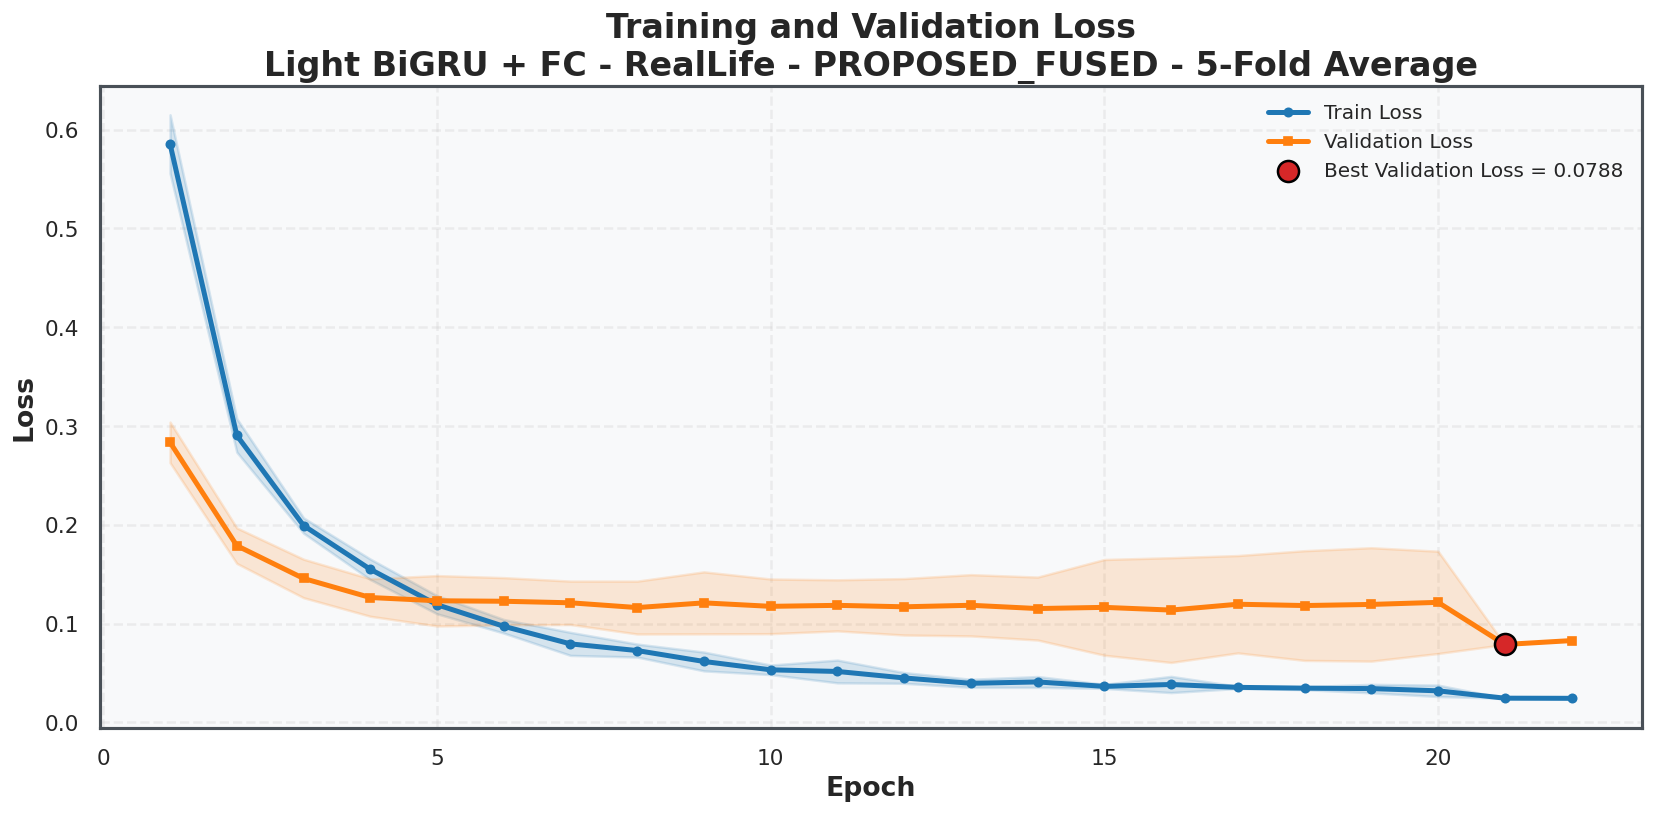

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure1_reallife_bigru_loss_curve.png


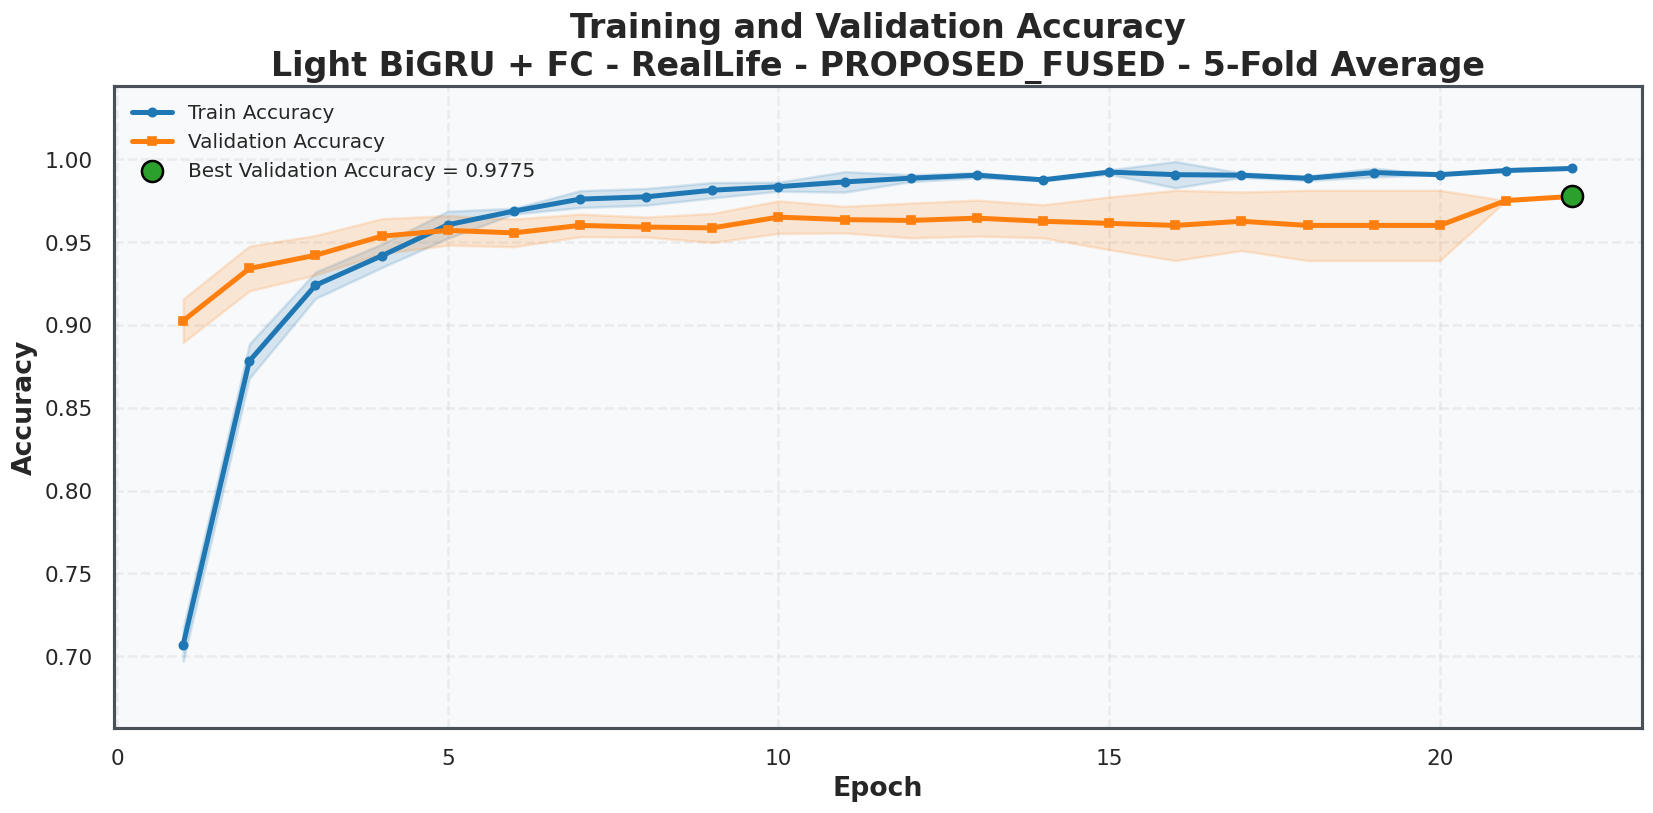

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure2_reallife_bigru_accuracy_curve.png


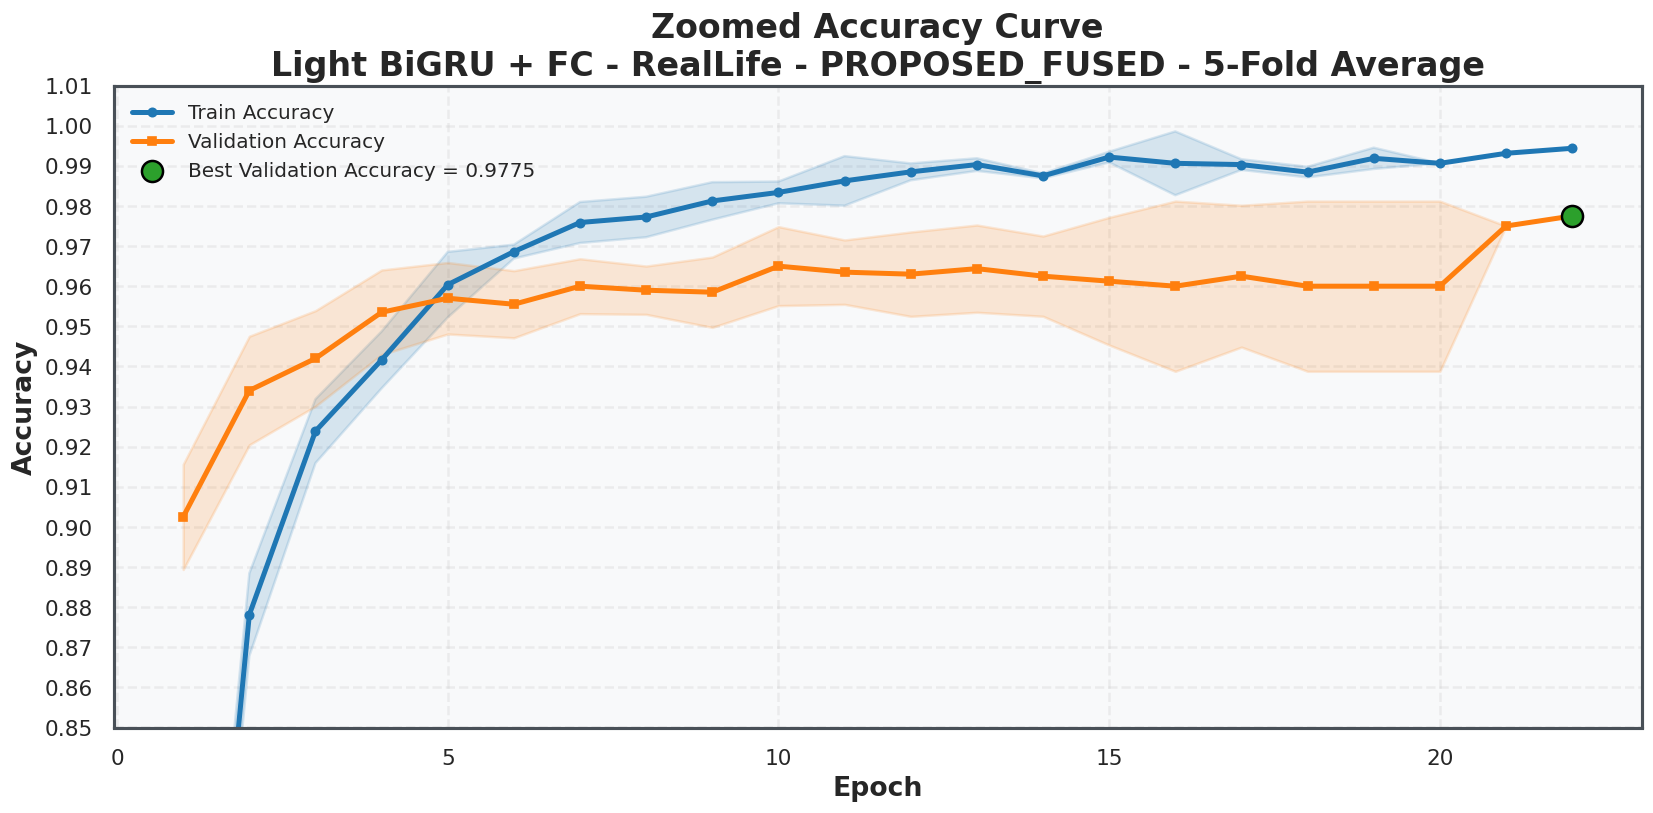

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure3_reallife_bigru_zoomed_accuracy_curve.png


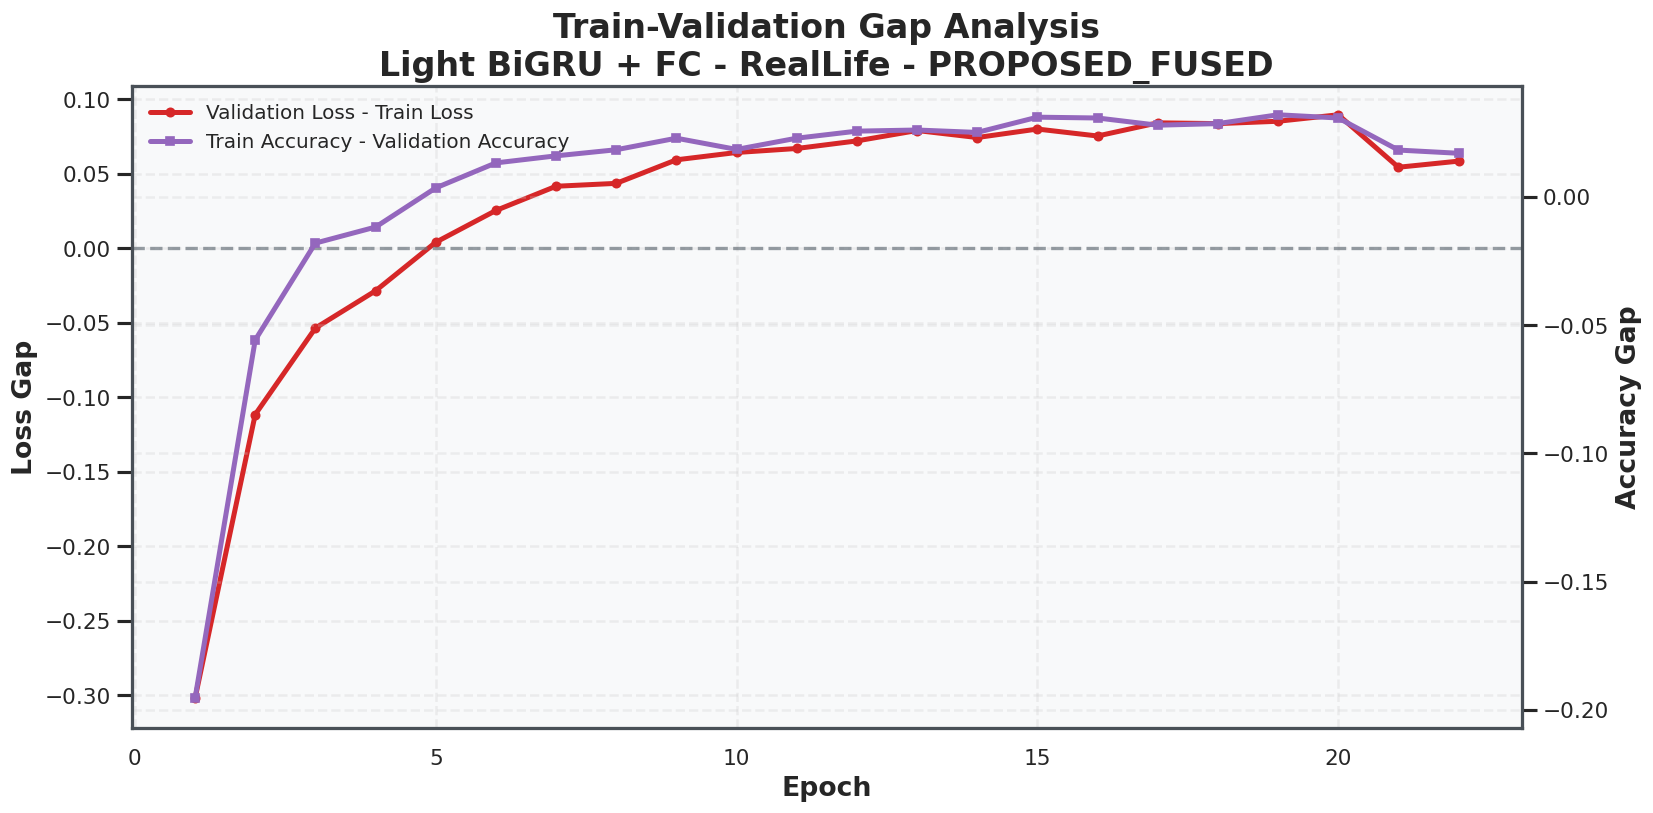

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure4_reallife_bigru_train_val_gap_curve.png


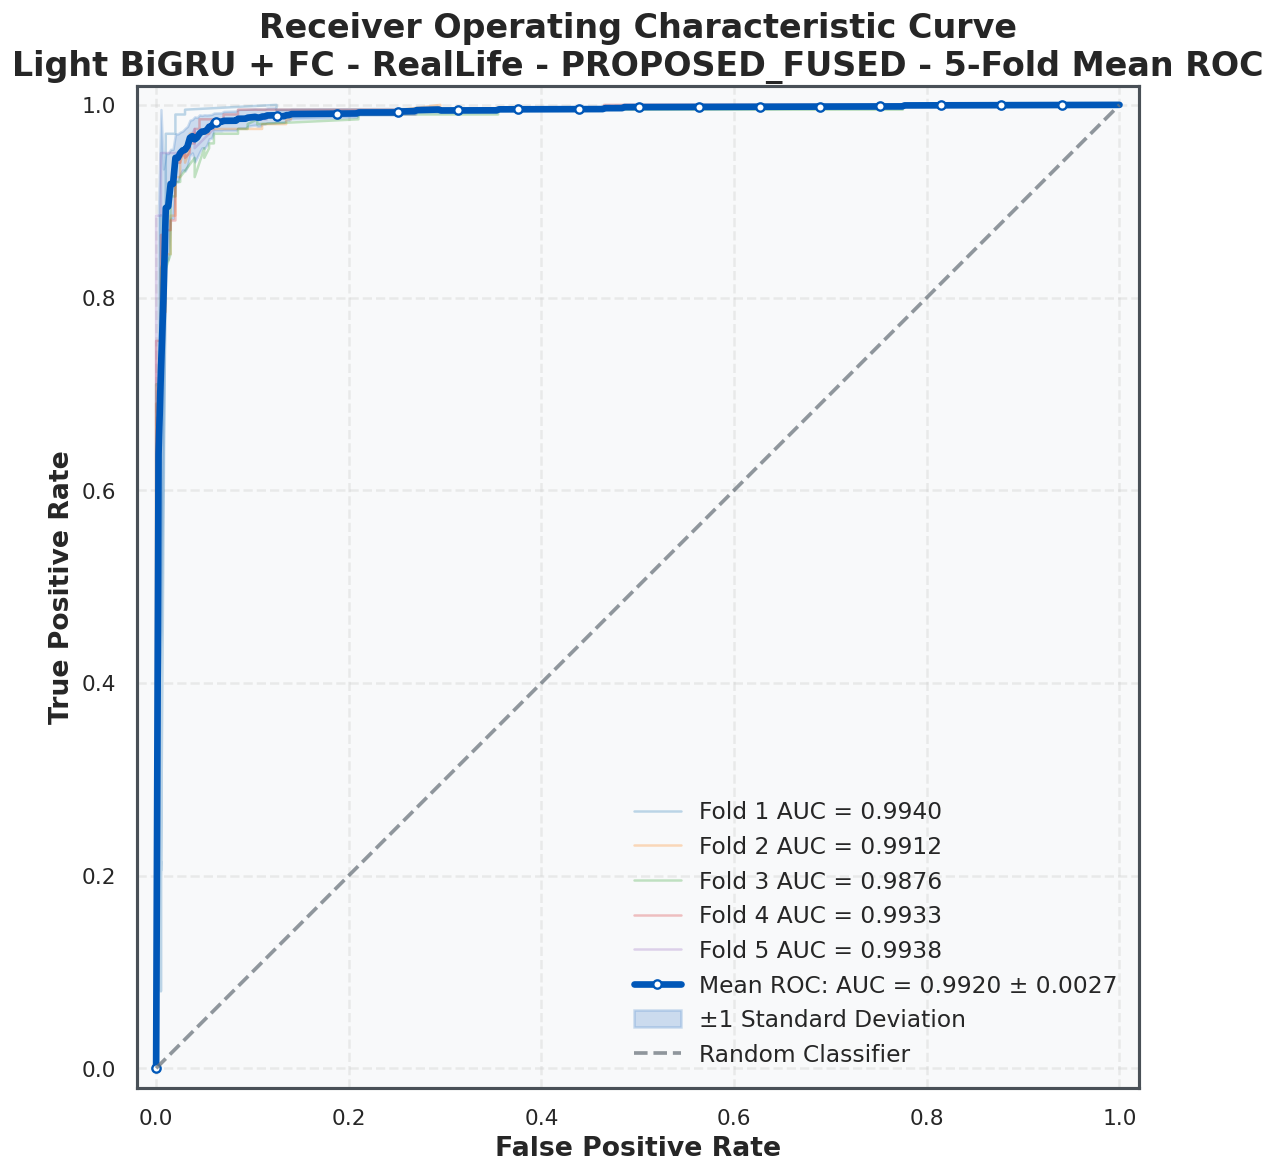

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure5_reallife_bigru_roc_curve.png


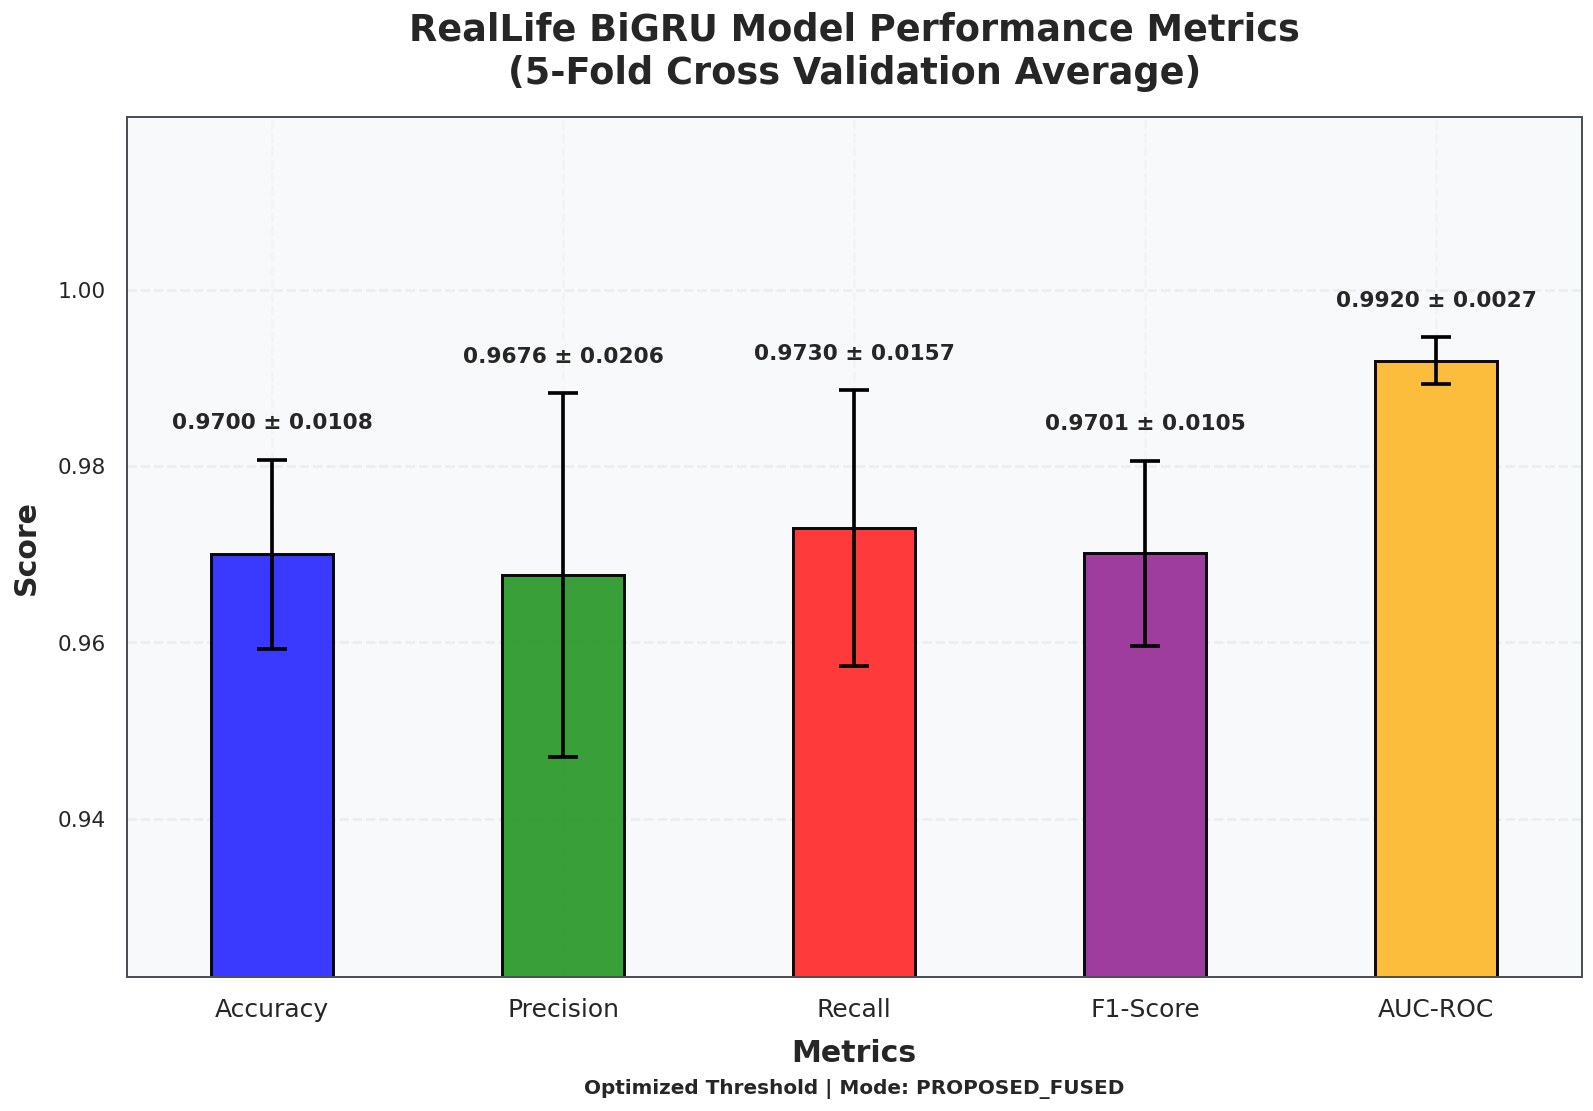

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure6_reallife_bigru_final_metrics_bar_chart.png


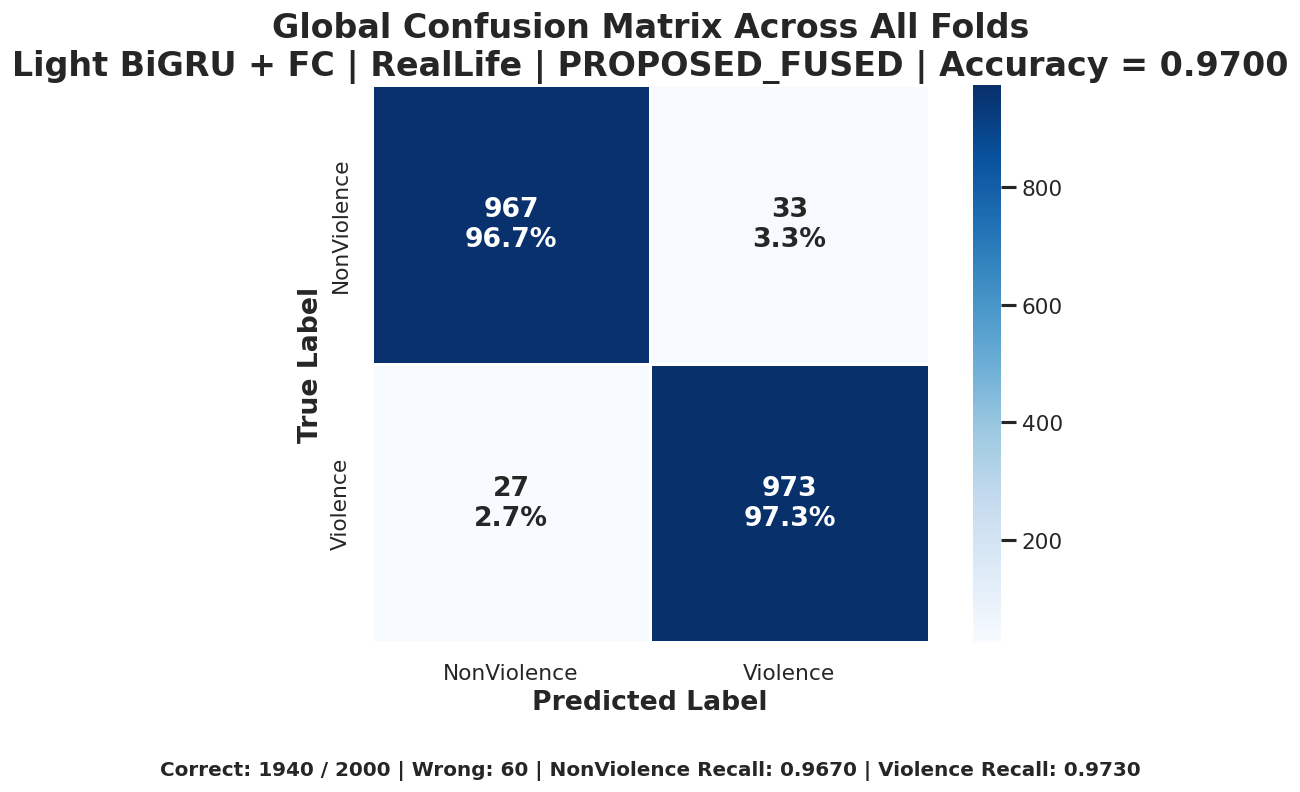

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure7_reallife_bigru_global_confusion_matrix.png


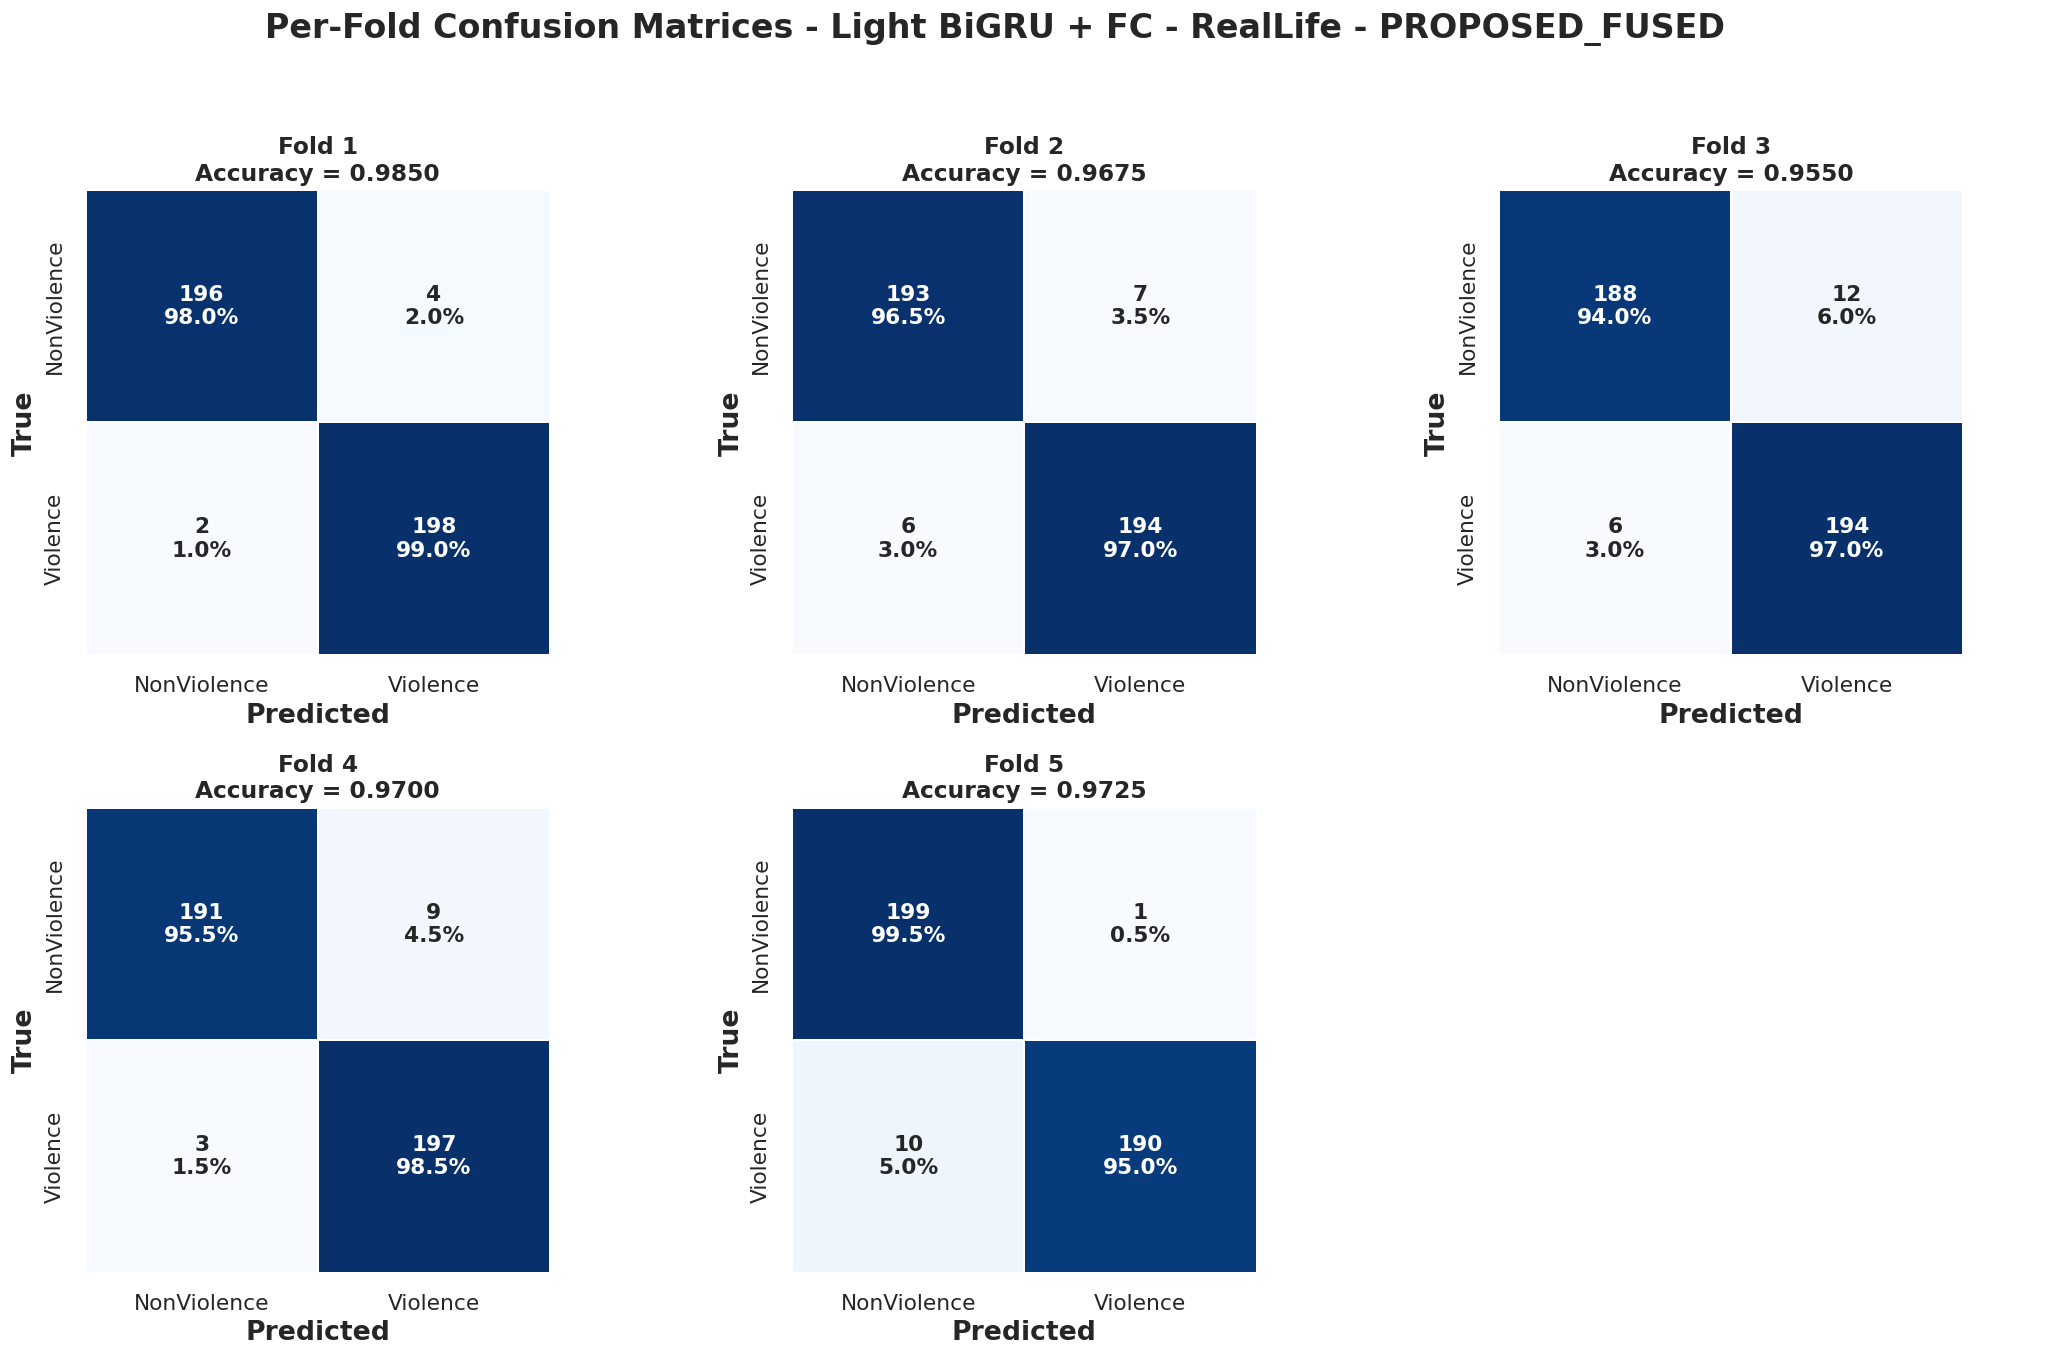

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure8_reallife_bigru_per_fold_confusion_matrices.png


C:\Users\LOQ\AppData\Local\Temp\ipykernel_10332\1883431053.py:290: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


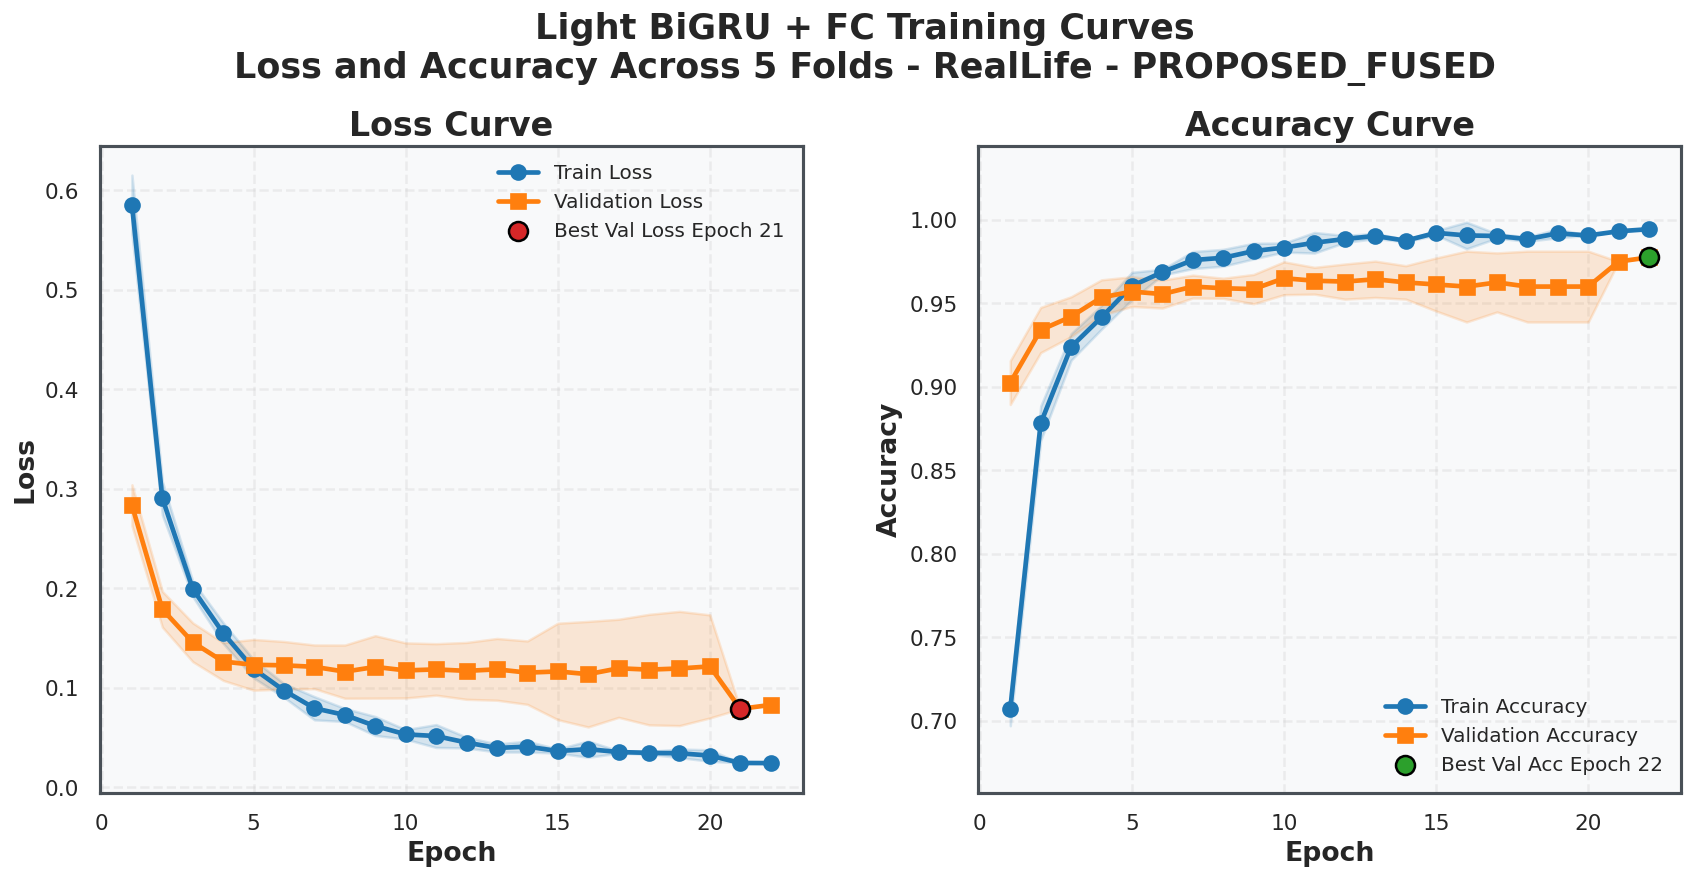

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure9_reallife_bigru_loss_accuracy_dashboard.png


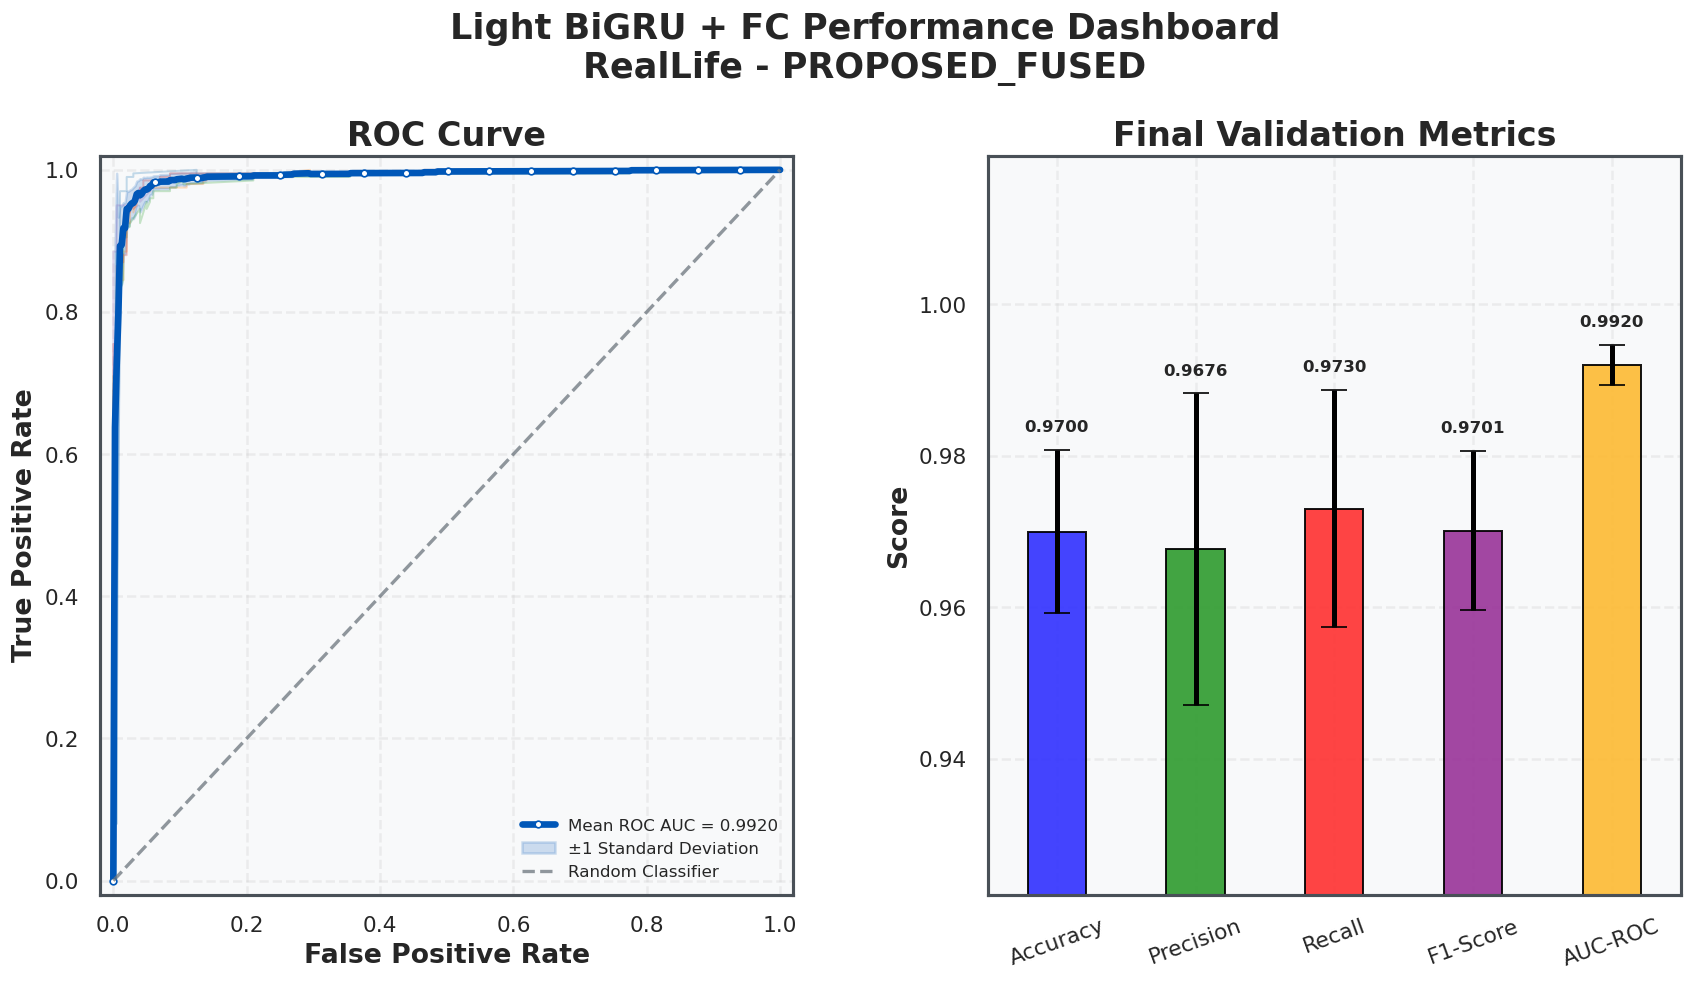

Saved: RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt\figure10_reallife_bigru_roc_metrics_dashboard.png

REAL LIFE BiGRU VISUALIZATION SUMMARY
Result folder : RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50
Plot folder   : RealLifeBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50\plots_paper_thr_opt
Mode          : PROPOSED_FUSED
Metrics mode  : optimized
Threshold info: Optimized Threshold

Curve Summary:
---------------------------------------------------------------------------
Best Validation Loss Epoch     : 21
Best Validation Loss           : 0.078833
Best Validation Accuracy Epoch : 22
Best Validation Accuracy       : 0.977500

Paper-Style Metrics:
---------------------------------------------------------------------------
Accuracy       : 0.9700 ± 0.0108
Precision      : 0.9676 ± 0.0206
Recall         : 0.97

In [2]:
# ============================================================
# CELL 2 - REAL LIFE BiGRU VISUALIZATION
# AUTO-DETECT VALID RESULT FOLDER VERSION
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    roc_curve,
    confusion_matrix
)


# ============================================================
# User Settings
# ============================================================

MODE = "PROPOSED_FUSED"

# MODE = "PROPOSED_FUSED"
# MODE = "PROPOSED_SPATIAL_ONLY"
# MODE = "PROPOSED_TEMPORAL_ONLY"

RESULTS_BASE_ROOT = Path("RealLifeBiGRUKerasResults")

MODEL_NAME = "BiGRU"
MODEL_LABEL = "Light BiGRU + FC"
DATASET_NAME = "RealLife"

SAVE_PLOTS = True
SHOW_PLOTS = True

CLASS_NAMES = ["NonViolence", "Violence"]

PROBABILITY_COLUMN = "violence_probability"

FIXED_DECISION_THRESHOLD = 0.5

METRICS_MODE_FOR_BAR = "optimized"

THRESHOLD_OPTIMIZATION_OBJECTIVE = "f1"

THRESHOLD_GRID = np.linspace(0.05, 0.95, 901)


# ============================================================
# Plot Settings
# ============================================================

USE_ZOOMED_ACCURACY_AXIS = True

ACCURACY_Y_MIN = 0.85
ACCURACY_Y_MAX = 1.00
ACCURACY_Y_TICK_STEP = 0.01

PAPER_BAR_TITLE = "RealLife BiGRU Model Performance Metrics\n(5-Fold Cross Validation Average)"

PAPER_BAR_METRICS = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC",
]

PAPER_BAR_COLORS = [
    "#3030FF",
    "#2E9B2E",
    "#FF3030",
    "#993399",
    "#FDBA32",
]

PAPER_BAR_FIGSIZE = (13.5, 9.5)
PAPER_BAR_WIDTH = 0.42
PAPER_BAR_TEXT_OFFSET = 0.003
PAPER_BAR_VALUE_FONTSIZE = 13
PAPER_BAR_XLABEL_FONTSIZE = 15
PAPER_BAR_TITLE_FONTSIZE = 22

FORCE_PAPER_BAR_YLIM = False

PAPER_BAR_Y_MIN = 0.70
PAPER_BAR_Y_MAX = 1.005


# ============================================================
# Valid Folder Detection
# ============================================================

REQUIRED_CSV_FILES = [
    "all_folds_summary.csv",
    "all_folds_epoch_metrics.csv",
    "all_folds_predictions.csv",
]

PREFERRED_RESULT_NAMES = [
    f"BiGRU_FC_{MODE}_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50",
    f"BiGRU_FC_{MODE}_FAST_BATCHPAD_LIGHT_NATURAL_EARLYSTOP_EPOCH50",
    f"BiGRU_FC_{MODE}_LIGHT_NATURAL_EARLYSTOP_EPOCH50",
]

def has_required_csvs(folder):
    return all((folder / name).exists() for name in REQUIRED_CSV_FILES)


def missing_csvs(folder):
    return [name for name in REQUIRED_CSV_FILES if not (folder / name).exists()]


def detect_result_folder():
    for name in PREFERRED_RESULT_NAMES:
        candidate = RESULTS_BASE_ROOT / name
        if candidate.exists() and has_required_csvs(candidate):
            return candidate

    if RESULTS_BASE_ROOT.exists():
        all_candidates = sorted([
            p for p in RESULTS_BASE_ROOT.glob("BiGRU_FC_*")
            if p.is_dir()
        ])

        valid_candidates = [
            p for p in all_candidates
            if has_required_csvs(p)
        ]

        if len(valid_candidates) > 0:
            for p in valid_candidates:
                if MODE in p.name:
                    return p

            return valid_candidates[0]

        print("\nAvailable result folders but missing required CSV files:")
        print("-" * 100)

        for p in all_candidates:
            print(p)
            print("Missing:", missing_csvs(p))
            print("-" * 100)

    raise FileNotFoundError(
        "\nNo valid result folder found.\n\n"
        "A valid folder must contain:\n"
        "  - all_folds_summary.csv\n"
        "  - all_folds_epoch_metrics.csv\n"
        "  - all_folds_predictions.csv\n\n"
        "First run the BiGRU training cell successfully."
    )


results_root = detect_result_folder()
RESULT_NAME = results_root.name

if "PROPOSED_FUSED" in RESULT_NAME:
    MODE = "PROPOSED_FUSED"
elif "PROPOSED_SPATIAL_ONLY" in RESULT_NAME:
    MODE = "PROPOSED_SPATIAL_ONLY"
elif "PROPOSED_TEMPORAL_ONLY" in RESULT_NAME:
    MODE = "PROPOSED_TEMPORAL_ONLY"

plot_output_dir = results_root / "plots_paper_thr_opt"
plot_output_dir.mkdir(parents=True, exist_ok=True)

print("=" * 110)
print("Using valid result folder:")
print(results_root)
print("Detected mode:", MODE)
print("Plot output folder:")
print(plot_output_dir)
print("=" * 110)


# ============================================================
# Load CSV Files
# ============================================================

summary_csv = results_root / "all_folds_summary.csv"
epoch_metrics_csv = results_root / "all_folds_epoch_metrics.csv"
predictions_csv = results_root / "all_folds_predictions.csv"
final_metrics_csv = results_root / "final_metrics_mean_std.csv"

fold_summary_df = pd.read_csv(summary_csv)
epoch_df = pd.read_csv(epoch_metrics_csv)
predictions_df = pd.read_csv(predictions_csv)

if final_metrics_csv.exists():
    final_metrics_df_original = pd.read_csv(final_metrics_csv)
else:
    final_metrics_df_original = pd.DataFrame()

probability_candidates = [
    PROBABILITY_COLUMN,
    "violence_probability",
    "fight_probability",
    "probability",
    "pred_prob",
    "y_prob",
    "score",
]

detected_probability_column = None

for col in probability_candidates:
    if col in predictions_df.columns:
        detected_probability_column = col
        break

if detected_probability_column is None:
    raise ValueError(
        f"No probability column found.\n"
        f"Available columns:\n{list(predictions_df.columns)}"
    )

PROBABILITY_COLUMN = detected_probability_column

print("\nLoaded data:")
print("Fold summary shape :", fold_summary_df.shape)
print("Epoch metrics shape:", epoch_df.shape)
print("Predictions shape  :", predictions_df.shape)
print("Original final metrics shape:", final_metrics_df_original.shape)
print("Probability column:", PROBABILITY_COLUMN)


# ============================================================
# Plot Style
# ============================================================

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("default")

sns.set_style("whitegrid")
sns.set_context("talk")

plt.rcParams.update({
    "font.size": 14,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.framealpha": 0.95,
    "lines.linewidth": 3,
    "figure.figsize": (14, 7),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.facecolor": "#F8F9FA",
    "figure.facecolor": "white",
    "axes.edgecolor": "#495057",
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.linestyle": "--",
})

COLOR_TRAIN = "#1F77B4"
COLOR_VAL = "#FF7F0E"
COLOR_ROC_MEAN = "#0057B8"
COLOR_RANDOM = "#6C757D"
COLOR_BEST = "#2CA02C"
COLOR_ERROR = "#D62728"
COLOR_GAP = "#9467BD"


# ============================================================
# Helper Functions
# ============================================================

def save_and_show(filename):
    plot_output_dir.mkdir(parents=True, exist_ok=True)
    path = plot_output_dir / filename

    plt.tight_layout()

    if SAVE_PLOTS:
        plt.savefig(
            path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()

    print("Saved:", path)


def make_cm_array(tn, fp, fn, tp):
    return np.array([
        [tn, fp],
        [fn, tp]
    ], dtype=int)


def normalize_cm_rows(cm):
    cm = cm.astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return cm / row_sum


def annotate_confusion_matrix(cm, normalize=True):
    if not normalize:
        return cm.astype(str)

    cm_norm = normalize_cm_rows(cm)
    annot = np.empty_like(cm).astype(object)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_norm[i, j] * 100:.1f}%"

    return annot


def apply_zoomed_accuracy_axis(ax):
    if USE_ZOOMED_ACCURACY_AXIS:
        ax.set_ylim(ACCURACY_Y_MIN, ACCURACY_Y_MAX)

        ticks = np.arange(
            ACCURACY_Y_MIN,
            ACCURACY_Y_MAX + ACCURACY_Y_TICK_STEP,
            ACCURACY_Y_TICK_STEP
        )

        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{t:.2f}" for t in ticks])
        ax.grid(True, which="major", axis="y", alpha=0.35, linestyle="--")
    else:
        ax.set_ylim(0.0, 1.05)


def compute_metrics_from_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    if len(np.unique(y_true)) >= 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "Accuracy": float(acc),
        "Precision": float(pre),
        "Recall": float(rec),
        "F1-Score": float(f1),
        "AUC-ROC": float(auc) if not np.isnan(auc) else np.nan,
        "MCC": float(mcc) if not np.isnan(mcc) else np.nan,
        "Sensitivity": float(sensitivity),
        "Specificity": float(specificity),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def find_best_threshold(y_true, y_prob, objective="f1"):
    best_threshold = 0.5
    best_score = -np.inf
    best_metrics = None

    for threshold in THRESHOLD_GRID:
        metrics = compute_metrics_from_threshold(
            y_true=y_true,
            y_prob=y_prob,
            threshold=threshold
        )

        if objective == "accuracy":
            score = metrics["Accuracy"]
        elif objective == "mcc":
            score = metrics["MCC"]
        else:
            score = metrics["F1-Score"]

        if np.isnan(score):
            score = -np.inf

        if score > best_score:
            best_score = score
            best_threshold = threshold
            best_metrics = metrics

    return best_threshold, best_metrics


def build_final_metrics_mean_std(metrics_per_fold_df, metrics_for_summary):
    rows = []

    for metric in metrics_for_summary:
        rows.append({
            "mode": MODE,
            "metric": metric,
            "mean": float(metrics_per_fold_df[metric].mean()),
            "std": float(metrics_per_fold_df[metric].std(ddof=1)),
        })

    return pd.DataFrame(rows)


# ============================================================
# Prepare Epoch Curves
# ============================================================

required_cols = [
    "epoch",
    "loss",
    "val_loss",
    "accuracy",
    "val_accuracy"
]

for col in required_cols:
    if col not in epoch_df.columns:
        raise ValueError(
            f"Required column not found: {col}\n"
            f"Available columns:\n{list(epoch_df.columns)}"
        )

epoch_df = epoch_df.copy()
epoch_df["epoch"] = epoch_df["epoch"].astype(int)

grouped = epoch_df.groupby("epoch")

epochs = grouped["epoch"].mean().index.values

train_loss_mean = grouped["loss"].mean()
train_loss_std = grouped["loss"].std().fillna(0)

val_loss_mean = grouped["val_loss"].mean()
val_loss_std = grouped["val_loss"].std().fillna(0)

train_acc_mean = grouped["accuracy"].mean()
train_acc_std = grouped["accuracy"].std().fillna(0)

val_acc_mean = grouped["val_accuracy"].mean()
val_acc_std = grouped["val_accuracy"].std().fillna(0)

loss_gap_mean = val_loss_mean - train_loss_mean
acc_gap_mean = train_acc_mean - val_acc_mean


# ============================================================
# Threshold Optimization
# ============================================================

fixed_rows = []
optimized_rows = []
optimized_prediction_rows = []

for fold in sorted(predictions_df["fold"].unique()):
    sub = predictions_df[predictions_df["fold"] == fold].copy()

    y_true = sub["true_label"].astype(int).values
    y_prob = sub[PROBABILITY_COLUMN].astype(float).values

    fixed_metrics = compute_metrics_from_threshold(
        y_true=y_true,
        y_prob=y_prob,
        threshold=FIXED_DECISION_THRESHOLD
    )

    fixed_metrics["fold"] = int(fold)
    fixed_metrics["mode"] = MODE
    fixed_rows.append(fixed_metrics)

    best_threshold, best_metrics = find_best_threshold(
        y_true=y_true,
        y_prob=y_prob,
        objective=THRESHOLD_OPTIMIZATION_OBJECTIVE
    )

    best_metrics["fold"] = int(fold)
    best_metrics["mode"] = MODE
    best_metrics["optimization_objective"] = THRESHOLD_OPTIMIZATION_OBJECTIVE
    optimized_rows.append(best_metrics)

    sub["optimized_threshold"] = best_threshold
    sub["optimized_pred_label"] = (
        sub[PROBABILITY_COLUMN].astype(float).values >= best_threshold
    ).astype(int)

    sub["optimized_pred_class"] = sub["optimized_pred_label"].map({
        0: "NonViolence",
        1: "Violence"
    })

    optimized_prediction_rows.append(sub)

fixed_metrics_per_fold_df = pd.DataFrame(fixed_rows)
optimized_metrics_per_fold_df = pd.DataFrame(optimized_rows)
optimized_predictions_df = pd.concat(optimized_prediction_rows, ignore_index=True)

all_metrics_for_summary = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC",
    "MCC",
    "Sensitivity",
    "Specificity",
]

fixed_final_metrics_df = build_final_metrics_mean_std(
    fixed_metrics_per_fold_df,
    all_metrics_for_summary
)

optimized_final_metrics_df = build_final_metrics_mean_std(
    optimized_metrics_per_fold_df,
    all_metrics_for_summary
)

fixed_metrics_per_fold_df.to_csv(
    plot_output_dir / "fixed_threshold_metrics_per_fold.csv",
    index=False
)

optimized_metrics_per_fold_df.to_csv(
    plot_output_dir / "optimized_threshold_metrics_per_fold.csv",
    index=False
)

fixed_final_metrics_df.to_csv(
    plot_output_dir / "fixed_threshold_final_metrics_mean_std.csv",
    index=False
)

optimized_final_metrics_df.to_csv(
    plot_output_dir / "optimized_threshold_final_metrics_mean_std.csv",
    index=False
)

optimized_predictions_df.to_csv(
    plot_output_dir / "optimized_threshold_predictions.csv",
    index=False
)

if METRICS_MODE_FOR_BAR == "optimized":
    final_metrics_df = optimized_final_metrics_df.copy()
    predictions_for_cm_df = optimized_predictions_df.copy()
    threshold_label = "Optimized Threshold"
else:
    final_metrics_df = fixed_final_metrics_df.copy()
    predictions_for_cm_df = predictions_df.copy()
    threshold_label = "Fixed Threshold = 0.5"

print("\nThreshold optimization summary:")
print("-" * 100)
print("Metrics mode for bar:", METRICS_MODE_FOR_BAR)
print("Optimization objective:", THRESHOLD_OPTIMIZATION_OBJECTIVE)
print("\nFixed threshold metrics:")
print(fixed_final_metrics_df)
print("\nOptimized threshold metrics:")
print(optimized_final_metrics_df)
print("-" * 100)


# ============================================================
# Figure 1: Loss Curve
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    epochs,
    train_loss_mean,
    marker="o",
    markersize=5,
    color=COLOR_TRAIN,
    label="Train Loss"
)

ax.fill_between(
    epochs,
    train_loss_mean - train_loss_std,
    train_loss_mean + train_loss_std,
    alpha=0.16,
    color=COLOR_TRAIN
)

ax.plot(
    epochs,
    val_loss_mean,
    marker="s",
    markersize=5,
    color=COLOR_VAL,
    label="Validation Loss"
)

ax.fill_between(
    epochs,
    val_loss_mean - val_loss_std,
    val_loss_mean + val_loss_std,
    alpha=0.16,
    color=COLOR_VAL
)

best_val_loss_epoch = int(val_loss_mean.idxmin())
best_val_loss = float(val_loss_mean.min())

ax.scatter(
    [best_val_loss_epoch],
    [best_val_loss],
    s=160,
    color=COLOR_ERROR,
    edgecolor="black",
    zorder=5,
    label=f"Best Validation Loss = {best_val_loss:.4f}"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(
    f"Training and Validation Loss\n"
    f"{MODEL_LABEL} - {DATASET_NAME} - {MODE} - 5-Fold Average"
)

ax.legend()
ax.grid(True, alpha=0.3)

save_and_show("figure1_reallife_bigru_loss_curve.png")


# ============================================================
# Figure 2: Accuracy Curve
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    epochs,
    train_acc_mean,
    marker="o",
    markersize=5,
    color=COLOR_TRAIN,
    label="Train Accuracy"
)

ax.fill_between(
    epochs,
    train_acc_mean - train_acc_std,
    train_acc_mean + train_acc_std,
    alpha=0.16,
    color=COLOR_TRAIN
)

ax.plot(
    epochs,
    val_acc_mean,
    marker="s",
    markersize=5,
    color=COLOR_VAL,
    label="Validation Accuracy"
)

ax.fill_between(
    epochs,
    val_acc_mean - val_acc_std,
    val_acc_mean + val_acc_std,
    alpha=0.16,
    color=COLOR_VAL
)

best_val_acc_epoch = int(val_acc_mean.idxmax())
best_val_acc = float(val_acc_mean.max())

ax.scatter(
    [best_val_acc_epoch],
    [best_val_acc],
    s=160,
    color=COLOR_BEST,
    edgecolor="black",
    zorder=5,
    label=f"Best Validation Accuracy = {best_val_acc:.4f}"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title(
    f"Training and Validation Accuracy\n"
    f"{MODEL_LABEL} - {DATASET_NAME} - {MODE} - 5-Fold Average"
)

ax.set_ylim(
    max(0.0, min(train_acc_mean.min(), val_acc_mean.min()) - 0.05),
    min(1.05, max(train_acc_mean.max(), val_acc_mean.max()) + 0.05)
)

ax.legend()
ax.grid(True, alpha=0.3)

save_and_show("figure2_reallife_bigru_accuracy_curve.png")


# ============================================================
# Figure 3: Zoomed Accuracy Curve
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    epochs,
    train_acc_mean,
    marker="o",
    markersize=5,
    color=COLOR_TRAIN,
    label="Train Accuracy"
)

ax.fill_between(
    epochs,
    train_acc_mean - train_acc_std,
    train_acc_mean + train_acc_std,
    alpha=0.16,
    color=COLOR_TRAIN
)

ax.plot(
    epochs,
    val_acc_mean,
    marker="s",
    markersize=5,
    color=COLOR_VAL,
    label="Validation Accuracy"
)

ax.fill_between(
    epochs,
    val_acc_mean - val_acc_std,
    val_acc_mean + val_acc_std,
    alpha=0.16,
    color=COLOR_VAL
)

ax.scatter(
    [best_val_acc_epoch],
    [best_val_acc],
    s=160,
    color=COLOR_BEST,
    edgecolor="black",
    zorder=5,
    label=f"Best Validation Accuracy = {best_val_acc:.4f}"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title(
    f"Zoomed Accuracy Curve\n"
    f"{MODEL_LABEL} - {DATASET_NAME} - {MODE} - 5-Fold Average"
)

apply_zoomed_accuracy_axis(ax)

ax.legend()
ax.grid(True, alpha=0.3)

save_and_show("figure3_reallife_bigru_zoomed_accuracy_curve.png")


# ============================================================
# Figure 4: Train-Val Gap Curve
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(
    epochs,
    loss_gap_mean,
    marker="o",
    markersize=5,
    color=COLOR_ERROR,
    label="Validation Loss - Train Loss"
)

ax1.axhline(
    0,
    color=COLOR_RANDOM,
    linestyle="--",
    linewidth=2,
    alpha=0.7
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss Gap")
ax1.set_title(
    f"Train-Validation Gap Analysis\n"
    f"{MODEL_LABEL} - {DATASET_NAME} - {MODE}"
)

ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    epochs,
    acc_gap_mean,
    marker="s",
    markersize=5,
    color=COLOR_GAP,
    label="Train Accuracy - Validation Accuracy"
)

ax2.set_ylabel("Accuracy Gap")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

save_and_show("figure4_reallife_bigru_train_val_gap_curve.png")


# ============================================================
# Figure 5: ROC Curve
# ============================================================

roc_rows = []

for fold in sorted(predictions_df["fold"].unique()):
    sub = predictions_df[predictions_df["fold"] == fold].copy()

    y_true = sub["true_label"].astype(int).values
    y_prob = sub[PROBABILITY_COLUMN].astype(float).values

    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_prob,
        pos_label=1
    )

    fold_auc = roc_auc_score(y_true, y_prob)

    temp = pd.DataFrame({
        "fold": fold,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
        "auc": fold_auc
    })

    roc_rows.append(temp)

if len(roc_rows) == 0:
    raise ValueError("No valid ROC data found.")

roc_df = pd.concat(roc_rows, ignore_index=True)
roc_df.to_csv(plot_output_dir / "roc_points_all_folds.csv", index=False)

mean_fpr = np.linspace(0, 1, 400)

fold_tprs = []
fold_aucs = []

fig, ax = plt.subplots(figsize=(10, 10))

for fold in sorted(roc_df["fold"].unique()):
    sub = roc_df[roc_df["fold"] == fold].copy()
    sub = sub.sort_values("fpr")

    fpr = sub["fpr"].values.astype(float)
    tpr = sub["tpr"].values.astype(float)
    fold_auc = float(sub["auc"].iloc[0])

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    interp_tpr[-1] = 1.0

    fold_tprs.append(interp_tpr)
    fold_aucs.append(fold_auc)

    ax.plot(
        fpr,
        tpr,
        linewidth=1.5,
        alpha=0.28,
        label=f"Fold {int(fold)} AUC = {fold_auc:.4f}"
    )

fold_tprs = np.asarray(fold_tprs)

mean_tpr = fold_tprs.mean(axis=0)
std_tpr = fold_tprs.std(axis=0)

mean_tpr[0] = 0.0
mean_tpr[-1] = 1.0

mean_auc = float(np.mean(fold_aucs))
std_auc = float(np.std(fold_aucs, ddof=1)) if len(fold_aucs) > 1 else 0.0

lower_tpr = np.maximum(mean_tpr - std_tpr, 0)
upper_tpr = np.minimum(mean_tpr + std_tpr, 1)

ax.plot(
    mean_fpr,
    mean_tpr,
    color=COLOR_ROC_MEAN,
    linewidth=4,
    marker="o",
    markevery=25,
    markersize=5,
    markerfacecolor="white",
    markeredgecolor=COLOR_ROC_MEAN,
    markeredgewidth=1.4,
    label=f"Mean ROC: AUC = {mean_auc:.4f} ± {std_auc:.4f}"
)

ax.fill_between(
    mean_fpr,
    lower_tpr,
    upper_tpr,
    color=COLOR_ROC_MEAN,
    alpha=0.18,
    label="±1 Standard Deviation"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2.2,
    color=COLOR_RANDOM,
    alpha=0.75,
    label="Random Classifier"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    f"Receiver Operating Characteristic Curve\n"
    f"{MODEL_LABEL} - {DATASET_NAME} - {MODE} - 5-Fold Mean ROC"
)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="lower right", fontsize=14)

save_and_show("figure5_reallife_bigru_roc_curve.png")


# ============================================================
# Figure 6: Paper-Style Metrics Bar Chart
# ============================================================

selected_metrics_df = final_metrics_df[
    final_metrics_df["metric"].isin(PAPER_BAR_METRICS)
].copy()

selected_metrics_df["metric"] = pd.Categorical(
    selected_metrics_df["metric"],
    categories=PAPER_BAR_METRICS,
    ordered=True
)

selected_metrics_df = selected_metrics_df.sort_values("metric")

bar_metrics = selected_metrics_df["metric"].astype(str).tolist()
bar_values = selected_metrics_df["mean"].values.astype(float)
bar_std = selected_metrics_df["std"].fillna(0).values.astype(float)

fig, ax = plt.subplots(figsize=PAPER_BAR_FIGSIZE)

x_pos = np.arange(len(bar_metrics))

bars = ax.bar(
    x_pos,
    bar_values,
    yerr=bar_std,
    capsize=9,
    color=PAPER_BAR_COLORS[:len(bar_metrics)],
    edgecolor="black",
    linewidth=1.8,
    alpha=0.95,
    width=PAPER_BAR_WIDTH,
    error_kw={
        "elinewidth": 2.2,
        "ecolor": "black",
        "capthick": 2.2,
        "capsize": 9
    }
)

for bar, val, err in zip(bars, bar_values, bar_std):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        val + err + PAPER_BAR_TEXT_OFFSET,
        f"{val:.4f} ± {err:.4f}",
        ha="center",
        va="bottom",
        fontsize=PAPER_BAR_VALUE_FONTSIZE,
        fontweight="bold"
    )

ax.set_xlabel("Metrics", fontsize=18, fontweight="bold", labelpad=10)
ax.set_ylabel("Score", fontsize=18, fontweight="bold", labelpad=10)

ax.set_title(
    PAPER_BAR_TITLE,
    fontsize=PAPER_BAR_TITLE_FONTSIZE,
    fontweight="bold",
    pad=20
)

ax.set_xticks(x_pos)
ax.set_xticklabels(bar_metrics, fontsize=PAPER_BAR_XLABEL_FONTSIZE)

if FORCE_PAPER_BAR_YLIM:
    ax.set_ylim(PAPER_BAR_Y_MIN, PAPER_BAR_Y_MAX)
else:
    y_min_auto = max(0.0, min(bar_values - bar_std) - 0.025)
    y_max_auto = min(1.02, max(bar_values + bar_std) + 0.025)
    ax.set_ylim(y_min_auto, y_max_auto)

ax.set_xlim(-0.5, len(bar_metrics) - 0.5)

ax.grid(True, axis="y", linestyle="--", alpha=0.28)
ax.grid(True, axis="x", linestyle="--", alpha=0.12)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("#495057")

ax.text(
    0.5,
    -0.13,
    f"{threshold_label} | Mode: {MODE}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

save_and_show("figure6_reallife_bigru_final_metrics_bar_chart.png")


# ============================================================
# Confusion Matrix Data
# ============================================================

cm_rows = []

for fold in sorted(predictions_for_cm_df["fold"].unique()):
    sub = predictions_for_cm_df[predictions_for_cm_df["fold"] == fold].copy()

    y_true = sub["true_label"].astype(int).values

    if METRICS_MODE_FOR_BAR == "optimized" and "optimized_pred_label" in sub.columns:
        y_pred = sub["optimized_pred_label"].astype(int).values
    else:
        if "pred_label" in sub.columns:
            y_pred = sub["pred_label"].astype(int).values
        else:
            y_prob = sub[PROBABILITY_COLUMN].astype(float).values
            y_pred = (y_prob >= FIXED_DECISION_THRESHOLD).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "fold": int(fold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

cm_folds_df = pd.DataFrame(cm_rows)
cm_folds_df.to_csv(plot_output_dir / "confusion_matrix_per_fold.csv", index=False)

total_tn = int(cm_folds_df["tn"].sum())
total_fp = int(cm_folds_df["fp"].sum())
total_fn = int(cm_folds_df["fn"].sum())
total_tp = int(cm_folds_df["tp"].sum())

global_cm = make_cm_array(
    total_tn,
    total_fp,
    total_fn,
    total_tp
)

total_samples = int(global_cm.sum())
total_correct = int(total_tn + total_tp)
total_wrong = int(total_fp + total_fn)

global_accuracy = total_correct / max(total_samples, 1)

violence_recall = total_tp / max(total_tp + total_fn, 1)
nonviolence_recall = total_tn / max(total_tn + total_fp, 1)

precision_violence = total_tp / max(total_tp + total_fp, 1)
precision_nonviolence = total_tn / max(total_tn + total_fn, 1)


# ============================================================
# Figure 7: Global Confusion Matrix
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

annot = annotate_confusion_matrix(
    global_cm,
    normalize=True
)

sns.heatmap(
    global_cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=1.5,
    linecolor="white",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={
        "size": 16,
        "weight": "bold"
    },
    ax=ax
)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(
    f"Global Confusion Matrix Across All Folds\n"
    f"{MODEL_LABEL} | {DATASET_NAME} | {MODE} | Accuracy = {global_accuracy:.4f}"
)

ax.text(
    0.5,
    -0.23,
    f"Correct: {total_correct} / {total_samples} | "
    f"Wrong: {total_wrong} | "
    f"NonViolence Recall: {nonviolence_recall:.4f} | "
    f"Violence Recall: {violence_recall:.4f}",
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold"
)

save_and_show("figure7_reallife_bigru_global_confusion_matrix.png")


# ============================================================
# Figure 8: Per-Fold Confusion Matrices
# ============================================================

n_folds = len(cm_folds_df)
n_cols = min(3, n_folds)
n_rows = int(np.ceil(n_folds / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5.5 * n_rows)
)

if n_folds == 1:
    axes = np.array([axes])
else:
    axes = np.asarray(axes).reshape(-1)

for idx, (_, row) in enumerate(cm_folds_df.iterrows()):
    ax = axes[idx]

    fold = int(row["fold"])

    cm = make_cm_array(
        int(row["tn"]),
        int(row["fp"]),
        int(row["fn"]),
        int(row["tp"])
    )

    fold_acc = (cm[0, 0] + cm[1, 1]) / max(cm.sum(), 1)

    annot = annotate_confusion_matrix(
        cm,
        normalize=True
    )

    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=1.2,
        linecolor="white",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot_kws={
            "size": 13,
            "weight": "bold"
        },
        ax=ax
    )

    ax.set_title(
        f"Fold {fold}\nAccuracy = {fold_acc:.4f}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for idx in range(n_folds, len(axes)):
    axes[idx].axis("off")

fig.suptitle(
    f"Per-Fold Confusion Matrices - {MODEL_LABEL} - {DATASET_NAME} - {MODE}",
    fontsize=20,
    fontweight="bold",
    y=1.03
)

save_and_show("figure8_reallife_bigru_per_fold_confusion_matrices.png")


# ============================================================
# Figure 9: Loss + Accuracy Dashboard
# ============================================================

fig = plt.figure(figsize=(17, 7))
gs = fig.add_gridspec(1, 2, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(
    epochs,
    train_loss_mean,
    marker="o",
    linewidth=2.8,
    color=COLOR_TRAIN,
    label="Train Loss"
)

ax1.plot(
    epochs,
    val_loss_mean,
    marker="s",
    linewidth=2.8,
    color=COLOR_VAL,
    label="Validation Loss"
)

ax1.fill_between(
    epochs,
    train_loss_mean - train_loss_std,
    train_loss_mean + train_loss_std,
    color=COLOR_TRAIN,
    alpha=0.16
)

ax1.fill_between(
    epochs,
    val_loss_mean - val_loss_std,
    val_loss_mean + val_loss_std,
    color=COLOR_VAL,
    alpha=0.16
)

ax1.scatter(
    [best_val_loss_epoch],
    [best_val_loss],
    s=130,
    color=COLOR_ERROR,
    edgecolor="black",
    zorder=5,
    label=f"Best Val Loss Epoch {best_val_loss_epoch}"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curve", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])

ax2.plot(
    epochs,
    train_acc_mean,
    marker="o",
    linewidth=2.8,
    color=COLOR_TRAIN,
    label="Train Accuracy"
)

ax2.plot(
    epochs,
    val_acc_mean,
    marker="s",
    linewidth=2.8,
    color=COLOR_VAL,
    label="Validation Accuracy"
)

ax2.fill_between(
    epochs,
    train_acc_mean - train_acc_std,
    train_acc_mean + train_acc_std,
    color=COLOR_TRAIN,
    alpha=0.16
)

ax2.fill_between(
    epochs,
    val_acc_mean - val_acc_std,
    val_acc_mean + val_acc_std,
    color=COLOR_VAL,
    alpha=0.16
)

ax2.scatter(
    [best_val_acc_epoch],
    [best_val_acc],
    s=130,
    color=COLOR_BEST,
    edgecolor="black",
    zorder=5,
    label=f"Best Val Acc Epoch {best_val_acc_epoch}"
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curve", fontweight="bold")

ax2.set_ylim(
    max(0.0, min(train_acc_mean.min(), val_acc_mean.min()) - 0.05),
    min(1.05, max(train_acc_mean.max(), val_acc_mean.max()) + 0.05)
)

ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"{MODEL_LABEL} Training Curves\n"
    f"Loss and Accuracy Across 5 Folds - {DATASET_NAME} - {MODE}",
    fontsize=21,
    fontweight="bold",
    y=1.04
)

save_and_show("figure9_reallife_bigru_loss_accuracy_dashboard.png")


# ============================================================
# Figure 10: ROC + Metrics Dashboard
# ============================================================

fig = plt.figure(figsize=(17, 8))
gs = fig.add_gridspec(1, 2, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])

for fold in sorted(roc_df["fold"].unique()):
    sub = roc_df[roc_df["fold"] == fold].copy()
    sub = sub.sort_values("fpr")

    ax1.plot(
        sub["fpr"],
        sub["tpr"],
        linewidth=1.2,
        alpha=0.25
    )

ax1.plot(
    mean_fpr,
    mean_tpr,
    color=COLOR_ROC_MEAN,
    linewidth=4,
    marker="o",
    markevery=25,
    markersize=4,
    markerfacecolor="white",
    markeredgecolor=COLOR_ROC_MEAN,
    label=f"Mean ROC AUC = {mean_auc:.4f}"
)

ax1.fill_between(
    mean_fpr,
    lower_tpr,
    upper_tpr,
    color=COLOR_ROC_MEAN,
    alpha=0.18,
    label="±1 Standard Deviation"
)

ax1.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=COLOR_RANDOM,
    linewidth=2,
    alpha=0.75,
    label="Random Classifier"
)

ax1.set_title("ROC Curve", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])

bars = ax2.bar(
    bar_metrics,
    bar_values,
    yerr=bar_std,
    capsize=8,
    color=PAPER_BAR_COLORS[:len(bar_metrics)],
    alpha=0.90,
    edgecolor="black",
    linewidth=1.2,
    width=PAPER_BAR_WIDTH
)

for bar, val, err in zip(bars, bar_values, bar_std):
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        val + err + 0.002,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax2.set_title("Final Validation Metrics", fontweight="bold")
ax2.set_ylabel("Score")

if FORCE_PAPER_BAR_YLIM:
    ax2.set_ylim(PAPER_BAR_Y_MIN, PAPER_BAR_Y_MAX)
else:
    ax2.set_ylim(
        max(0.0, min(bar_values - bar_std) - 0.025),
        min(1.02, max(bar_values + bar_std) + 0.025)
    )

ax2.set_xlim(-0.5, len(bar_metrics) - 0.5)
ax2.tick_params(axis="x", rotation=20)
ax2.grid(True, alpha=0.3, axis="y")

fig.suptitle(
    f"{MODEL_LABEL} Performance Dashboard\n{DATASET_NAME} - {MODE}",
    fontsize=21,
    fontweight="bold",
    y=1.03
)

save_and_show("figure10_reallife_bigru_roc_metrics_dashboard.png")


# ============================================================
# Print Final Summary
# ============================================================

print("\n" + "=" * 110)
print("REAL LIFE BiGRU VISUALIZATION SUMMARY")
print("=" * 110)

print(f"Result folder : {results_root}")
print(f"Plot folder   : {plot_output_dir}")
print(f"Mode          : {MODE}")
print(f"Metrics mode  : {METRICS_MODE_FOR_BAR}")
print(f"Threshold info: {threshold_label}")

print("\nCurve Summary:")
print("-" * 75)
print(f"Best Validation Loss Epoch     : {best_val_loss_epoch}")
print(f"Best Validation Loss           : {best_val_loss:.6f}")
print(f"Best Validation Accuracy Epoch : {best_val_acc_epoch}")
print(f"Best Validation Accuracy       : {best_val_acc:.6f}")

print("\nPaper-Style Metrics:")
print("-" * 75)

for _, row in selected_metrics_df.iterrows():
    print(f"{str(row['metric']):15s}: {row['mean']:.4f} ± {row['std']:.4f}")

print("-" * 75)

print(f"Mean ROC AUC: {mean_auc:.4f} ± {std_auc:.4f}")

print("\nGlobal Confusion Matrix:")
print(f"TN: {total_tn}")
print(f"FP: {total_fp}")
print(f"FN: {total_fn}")
print(f"TP: {total_tp}")

print("\nConfusion Matrix Summary:")
print(f"Total samples        : {total_samples}")
print(f"Correct samples      : {total_correct}")
print(f"Wrong samples        : {total_wrong}")
print(f"Global accuracy      : {global_accuracy:.4f}")
print(f"NonViolence recall   : {nonviolence_recall:.4f}")
print(f"Violence recall      : {violence_recall:.4f}")
print(f"NonViolence precision: {precision_nonviolence:.4f}")
print(f"Violence precision   : {precision_violence:.4f}")

print("\nOverfitting Gap Summary:")
print("-" * 75)
print(f"Final Loss Gap     val_loss - train_loss : {float(loss_gap_mean.iloc[-1]):.6f}")
print(f"Final Accuracy Gap train_acc - val_acc   : {float(acc_gap_mean.iloc[-1]):.6f}")
print(f"Max Loss Gap       val_loss - train_loss : {float(loss_gap_mean.max()):.6f}")
print(f"Max Accuracy Gap   train_acc - val_acc   : {float(acc_gap_mean.max()):.6f}")

if "epochs_trained" in fold_summary_df.columns:
    print("\nEarly Stopping Summary:")
    print("-" * 75)
    print(f"Mean epochs trained: {fold_summary_df['epochs_trained'].mean():.2f}")
    print(f"Std epochs trained : {fold_summary_df['epochs_trained'].std(ddof=1):.2f}")
    print(f"Min epochs trained : {fold_summary_df['epochs_trained'].min()}")
    print(f"Max epochs trained : {fold_summary_df['epochs_trained'].max()}")

if METRICS_MODE_FOR_BAR == "optimized":
    print("\nOptimized Threshold Per Fold:")
    print("-" * 75)
    print(
        optimized_metrics_per_fold_df[
            [
                "fold",
                "threshold",
                "Accuracy",
                "Precision",
                "Recall",
                "F1-Score",
                "AUC-ROC",
                "MCC"
            ]
        ]
    )

print("\nSaved plots folder:")
print(plot_output_dir)

print("=" * 110)

In [5]:
# ============================================================
# CELL - REAL LIFE FULL-KEYFRAME FAST BiLSTM + FC
# KERAS / TENSORFLOW VERSION
# ============================================================

import os
import gc
import json
import time
import random
import math

import numpy as np
import pandas as pd

from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


USE_MIXED_PRECISION = True
USE_TRAIN_ONLY_NORMALIZATION = True

BUCKET_BOUNDARIES = [16, 24, 32, 48, 64, 80, 96, 128, 160, 192, 256, 320, 384, 512]
PAD_TO_MULTIPLE = 8

SHUFFLE_TRAIN = True
AUTOTUNE = tf.data.AUTOTUNE


try:
    gpus = tf.config.list_physical_devices("GPU")

    if len(gpus) > 0:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU devices found:")
        for gpu in gpus:
            print(" -", gpu)

        if USE_MIXED_PRECISION:
            try:
                tf.keras.mixed_precision.set_global_policy("mixed_float16")
                print("Mixed precision enabled: mixed_float16")
            except Exception as e:
                print("Could not enable mixed precision:", e)
    else:
        print("No GPU found. Running on CPU.")

except Exception as e:
    print("Could not set GPU memory growth:", e)


FEATURE_ROOT = Path("RealLifeFeatures")
RESULTS_ROOT = Path("RealLifeBiLSTMKerasResults")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


MODE = "PROPOSED_FUSED"

# MODE = "PROPOSED_FUSED"
# MODE = "PROPOSED_SPATIAL_ONLY"
# MODE = "PROPOSED_TEMPORAL_ONLY"
# MODE = "UNIFORM_STRIDE_STEP_4"
# MODE = "UNIFORM_FIXED_16"
# MODE = "UNIFORM_FIXED_32"


if not FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nFeature root folder not found:\n"
        f"    {FEATURE_ROOT}\n\n"
        f"First extract features, then run this BiLSTM training cell."
    )

available_feature_dirs = sorted([
    p.name for p in FEATURE_ROOT.glob("*") if p.is_dir()
])

print("\nAvailable feature folders inside RealLifeFeatures:")
for d in available_feature_dirs:
    print(" -", d)

MODE_FEATURE_ROOT = FEATURE_ROOT / MODE

if not MODE_FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nSelected feature folder not found:\n"
        f"    {MODE_FEATURE_ROOT}\n\n"
        f"You selected MODE:\n"
        f"    {MODE}\n\n"
        f"Available folders inside RealLifeFeatures are:\n"
        f"    {available_feature_dirs}\n"
    )

MODES_TO_RUN = [MODE]

print("=" * 110)
print("FULL-KEYFRAME FAST BiLSTM TRAINING ENABLED")
print("Selected MODE :", MODE)
print("Feature folder:", MODE_FEATURE_ROOT)
print("=" * 110)


RUN_FOLDS = [1, 2, 3, 4, 5]

CLASSES = ["Violence", "NonViolence"]

CLASS_TO_LABEL = {
    "NonViolence": 0,
    "Violence": 1
}

LABEL_TO_CLASS = {
    0: "NonViolence",
    1: "Violence"
}

FEATURE_DIM = 1280
DECISION_THRESHOLD = 0.5


BATCH_SIZE = 32
EPOCHS = 50

USE_CLASS_WEIGHT = True

MODEL_MONITOR = "val_loss"
MODEL_MONITOR_MODE = "min"

USE_EARLY_STOPPING = True
PATIENCE = 6
MIN_DELTA = 1e-4


INITIAL_LR = 3e-4

USE_REDUCE_LR_ON_PLATEAU = True

REDUCE_LR_MONITOR = "val_loss"
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_PATIENCE = 3
REDUCE_LR_MIN_LR = 1e-7


BILSTM_UNITS = 128
BILSTM_DROPOUT = 0.25
BILSTM_RECURRENT_DROPOUT = 0.0

SPATIAL_DROPOUT_RATE = 0.10
DENSE_DROPOUT = 0.35

L2_WEIGHT = 0.00
LABEL_SMOOTHING = 0.00
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0


def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def ceil_to_multiple(x, multiple):
    if multiple is None or multiple <= 1:
        return int(x)

    return int(math.ceil(float(x) / float(multiple)) * multiple)


def safe_load_feature(path):
    arr = np.load(path)

    if arr.ndim != 2:
        raise ValueError(
            f"Expected feature shape [T, 1280], got {arr.shape} in {path}"
        )

    if arr.shape[0] == 0:
        raise ValueError(f"Empty feature sequence: {path}")

    if arr.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Feature dimension mismatch in {path}. "
            f"Expected {FEATURE_DIM}, got {arr.shape[1]}"
        )

    return arr.astype(np.float32)


def collect_files_for_fold(mode, fold_idx):
    train_files = []
    train_labels = []
    val_files = []
    val_labels = []

    mode_root = FEATURE_ROOT / mode

    for cls in CLASSES:
        label = CLASS_TO_LABEL[cls]

        train_dir = mode_root / f"fold_{fold_idx}" / "train" / cls
        val_dir = mode_root / f"fold_{fold_idx}" / "val" / cls

        if train_dir.exists():
            files = sorted(train_dir.glob("*.npy"))
            train_files.extend(files)
            train_labels.extend([label] * len(files))
        else:
            print(f"Missing train folder: {train_dir}")

        if val_dir.exists():
            files = sorted(val_dir.glob("*.npy"))
            val_files.extend(files)
            val_labels.extend([label] * len(files))
        else:
            print(f"Missing val folder: {val_dir}")

    return train_files, np.array(train_labels), val_files, np.array(val_labels)


def describe_lengths(files):
    lengths = []

    for f in files:
        arr = np.load(f, mmap_mode="r")
        lengths.append(arr.shape[0])

    lengths = np.array(lengths, dtype=np.int64)

    return {
        "min": int(lengths.min()) if len(lengths) > 0 else 0,
        "max": int(lengths.max()) if len(lengths) > 0 else 0,
        "mean": float(lengths.mean()) if len(lengths) > 0 else 0.0,
        "median": float(np.median(lengths)) if len(lengths) > 0 else 0.0,
        "std": float(lengths.std()) if len(lengths) > 0 else 0.0,
    }


def compute_train_mean_std(train_files):
    total_count = 0
    total_sum = np.zeros(FEATURE_DIM, dtype=np.float64)
    total_sq_sum = np.zeros(FEATURE_DIM, dtype=np.float64)

    for f in train_files:
        arr = safe_load_feature(f)

        total_sum += arr.sum(axis=0)
        total_sq_sum += np.square(arr).sum(axis=0)
        total_count += arr.shape[0]

    mean = total_sum / max(total_count, 1)
    var = total_sq_sum / max(total_count, 1) - np.square(mean)
    var = np.maximum(var, 1e-8)
    std = np.sqrt(var)

    return mean.astype(np.float32), std.astype(np.float32)


def load_sequences_to_ram(files, mean=None, std=None):
    sequences = []
    lengths = []

    for f in files:
        arr = safe_load_feature(f)

        if USE_TRAIN_ONLY_NORMALIZATION and mean is not None and std is not None:
            arr = (arr - mean) / std

        arr = arr.astype(np.float32)
        sequences.append(arr)
        lengths.append(arr.shape[0])

    return sequences, np.array(lengths, dtype=np.int64)


def compute_class_weight_dict(labels):
    labels = np.asarray(labels).astype(int)
    counts = np.bincount(labels, minlength=2).astype(np.float32)
    total = counts.sum()

    weights = total / np.maximum(2.0 * counts, 1.0)

    return {
        0: float(weights[0]),
        1: float(weights[1]),
    }


def make_sample_weights(labels, class_weight_dict):
    labels = np.asarray(labels).astype(int)
    sample_weights = np.ones_like(labels, dtype=np.float32)

    for label_id, weight in class_weight_dict.items():
        sample_weights[labels == int(label_id)] = float(weight)

    return sample_weights.astype(np.float32)


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    if len(np.unique(y_true)) >= 2:
        auc_value = roc_auc_score(y_true, y_prob)
    else:
        auc_value = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "auc": float(auc_value) if not np.isnan(auc_value) else np.nan,
        "mcc": float(mcc) if not np.isnan(mcc) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def make_bucketed_tf_dataset(
    sequences,
    labels,
    sample_weights=None,
    batch_size=32,
    shuffle=True,
    bucket_boundaries=None
):
    labels = np.asarray(labels).astype(np.float32)

    if sample_weights is None:
        sample_weights = np.ones_like(labels, dtype=np.float32)
    else:
        sample_weights = np.asarray(sample_weights).astype(np.float32)

    def generator():
        indices = np.arange(len(sequences))

        if shuffle:
            np.random.shuffle(indices)

        for idx in indices:
            x = sequences[idx].astype(np.float32)
            y = np.array([labels[idx]], dtype=np.float32)
            w = np.array([sample_weights[idx]], dtype=np.float32)

            yield x, y, w

    output_signature = (
        tf.TensorSpec(shape=(None, FEATURE_DIM), dtype=tf.float32),
        tf.TensorSpec(shape=(1,), dtype=tf.float32),
        tf.TensorSpec(shape=(1,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=output_signature
    )

    if bucket_boundaries is None:
        bucket_boundaries = BUCKET_BOUNDARIES

    bucket_batch_sizes = [batch_size] * (len(bucket_boundaries) + 1)

    ds = ds.bucket_by_sequence_length(
        element_length_func=lambda x, y, w: tf.shape(x)[0],
        bucket_boundaries=bucket_boundaries,
        bucket_batch_sizes=bucket_batch_sizes,
        padded_shapes=(
            tf.TensorShape([None, FEATURE_DIM]),
            tf.TensorShape([1]),
            tf.TensorShape([1]),
        ),
        padding_values=(
            tf.constant(0.0, dtype=tf.float32),
            tf.constant(0.0, dtype=tf.float32),
            tf.constant(1.0, dtype=tf.float32),
        ),
        drop_remainder=False
    )

    ds = ds.prefetch(AUTOTUNE)

    return ds


def predict_full_keyframe_sequences(model, sequences, files, labels, batch_size=32):
    lengths = np.array([seq.shape[0] for seq in sequences], dtype=np.int64)
    sorted_indices = np.argsort(lengths)

    all_rows = []
    all_probs = []
    all_true = []

    for start in range(0, len(sorted_indices), batch_size):
        batch_indices = sorted_indices[start:start + batch_size]
        batch_sequences = [sequences[i] for i in batch_indices]

        max_len = max(seq.shape[0] for seq in batch_sequences)
        max_len = ceil_to_multiple(max_len, PAD_TO_MULTIPLE)

        x_batch = np.zeros(
            (len(batch_sequences), max_len, FEATURE_DIM),
            dtype=np.float32
        )

        for j, seq in enumerate(batch_sequences):
            t = seq.shape[0]
            x_batch[j, :t, :] = seq

        probs = model.predict(
            x_batch,
            batch_size=len(batch_sequences),
            verbose=0
        ).reshape(-1)

        for idx, prob in zip(batch_indices, probs):
            true_label = int(labels[idx])
            pred_label = int(prob >= DECISION_THRESHOLD)

            all_probs.append(float(prob))
            all_true.append(true_label)

            all_rows.append({
                "video_id": files[idx].stem,
                "true_label": true_label,
                "true_class": LABEL_TO_CLASS[true_label],
                "violence_probability": float(prob),
                "decision_threshold": DECISION_THRESHOLD,
                "pred_label": pred_label,
                "pred_class": LABEL_TO_CLASS[pred_label],
                "num_keyframes_used": int(sequences[idx].shape[0]),
            })

    return np.array(all_true), np.array(all_probs), all_rows


class PrettyEpochLogger(callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_loss = logs.get("loss", np.nan)
        train_acc = logs.get("accuracy", np.nan)
        val_loss = logs.get("val_loss", np.nan)
        val_acc = logs.get("val_accuracy", np.nan)

        print(
            f"Epoch {epoch + 1}/{self.total_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )


def build_bilstm_fc_model(input_dim=1280):
    if L2_WEIGHT > 0:
        reg = regularizers.l2(L2_WEIGHT)
    else:
        reg = None

    inputs = layers.Input(
        shape=(None, input_dim),
        name="efficientnet_sequence_features"
    )

    x = layers.Masking(
        mask_value=0.0,
        name="padding_mask"
    )(inputs)

    x = layers.SpatialDropout1D(
        SPATIAL_DROPOUT_RATE,
        name="spatial_dropout_features"
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            BILSTM_UNITS,
            return_sequences=False,
            dropout=BILSTM_DROPOUT,
            recurrent_dropout=BILSTM_RECURRENT_DROPOUT,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
            name="lstm_core"
        ),
        merge_mode="concat",
        name="bilstm"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_128"
    )(x)

    x = layers.BatchNormalization(
        name="bn_128"
    )(x)

    x = layers.Dropout(
        DENSE_DROPOUT,
        name="dropout_128"
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_64"
    )(x)

    x = layers.BatchNormalization(
        name="bn_64"
    )(x)

    x = layers.Dropout(
        DENSE_DROPOUT * 0.75,
        name="dropout_64"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="binary_output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Full_Keyframe_Fast_BiLSTM_FC"
    )

    loss_fn = tf.keras.losses.BinaryCrossentropy(
        label_smoothing=LABEL_SMOOTHING,
        name="binary_crossentropy"
    )

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=INITIAL_LR,
            weight_decay=WEIGHT_DECAY,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "AdamW"
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=INITIAL_LR,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "Adam"

    compile_kwargs = {
        "loss": loss_fn,
        "optimizer": optimizer,
        "metrics": [
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Precision(
                name="precision",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Recall(
                name="recall",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ],
    }

    try:
        compile_kwargs["steps_per_execution"] = 8
        model.compile(**compile_kwargs)
    except TypeError:
        compile_kwargs.pop("steps_per_execution", None)
        model.compile(**compile_kwargs)

    model.optimizer_name_for_config = optimizer_name

    return model


global_start = time.perf_counter()
global_summary_rows = []

print("\n" + "=" * 110)
print("REAL LIFE FULL-KEYFRAME FAST BiLSTM + FULLY CONNECTED TRAINING")
print("=" * 110)
print("Feature root      :", FEATURE_ROOT)
print("Results root      :", RESULTS_ROOT)
print("Selected mode     :", MODE)
print("Modes to run      :", MODES_TO_RUN)
print("Epochs            :", EPOCHS)
print("Batch size        :", BATCH_SIZE)
print("BiLSTM units      :", BILSTM_UNITS)
print("=" * 110)

for mode in MODES_TO_RUN:
    mode_start = time.perf_counter()

    print("\n" + "#" * 110)
    print(f"STARTING MODE: {mode}")
    print("#" * 110)

    mode_feature_root = FEATURE_ROOT / mode

    if not mode_feature_root.exists():
        print(f"Skipping mode because feature folder not found: {mode_feature_root}")
        continue

    mode_result_root = RESULTS_ROOT / f"BiLSTM_FC_{mode}_FULLKEY_FAST_BUCKET_LIGHT_NATURAL_EARLYSTOP_EPOCH50"
    mode_result_root.mkdir(parents=True, exist_ok=True)

    mode_epoch_rows = []
    mode_fold_rows = []
    mode_prediction_rows = []

    config = {
        "dataset": "Real Life Violence Dataset",
        "mode": mode,
        "feature_root": str(mode_feature_root),
        "result_root": str(mode_result_root),
        "model": "Full-Keyframe Fast BiLSTM + Fully Connected + Sigmoid",
        "version": "No MAX_SEQ_LEN + tf.data bucket_by_sequence_length + batch-wise padding",
        "feature_dim": FEATURE_DIM,
        "model_input_shape": "[None, 1280]",
        "max_seq_len": None,
        "all_selected_keyframes_used": True,
        "temporal_truncation": False,
        "temporal_resampling": False,
        "bucket_boundaries": BUCKET_BOUNDARIES,
        "pad_to_multiple": PAD_TO_MULTIPLE,
        "mixed_precision": USE_MIXED_PRECISION,
        "bilstm_units": BILSTM_UNITS,
        "bilstm_dropout": BILSTM_DROPOUT,
        "bilstm_recurrent_dropout": BILSTM_RECURRENT_DROPOUT,
        "spatial_dropout_rate": SPATIAL_DROPOUT_RATE,
        "dense_dropout": DENSE_DROPOUT,
        "l2_weight_inside_loss": L2_WEIGHT,
        "label_smoothing": LABEL_SMOOTHING,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "initial_lr": INITIAL_LR,
        "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "decision_threshold": DECISION_THRESHOLD,
        "use_reduce_lr_on_plateau": USE_REDUCE_LR_ON_PLATEAU,
        "use_train_only_normalization": USE_TRAIN_ONLY_NORMALIZATION,
        "use_class_weight": USE_CLASS_WEIGHT,
        "class_weight_as_sample_weight": True,
        "monitor": MODEL_MONITOR,
        "monitor_mode": MODEL_MONITOR_MODE,
        "early_stopping": USE_EARLY_STOPPING,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "run_folds": RUN_FOLDS,
        "classes": CLASSES,
        "class_to_label": CLASS_TO_LABEL,
        "label_to_class": LABEL_TO_CLASS,
        "seed": SEED,
    }

    with open(mode_result_root / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4, ensure_ascii=False)

    for fold_idx in RUN_FOLDS:
        fold_start = time.perf_counter()

        print("\n" + "=" * 110)
        print(f"FULL-KEYFRAME FAST BiLSTM Fold {fold_idx}")
        print(f"MODE: {mode}")
        print("=" * 110)

        train_files, train_labels, val_files, val_labels = collect_files_for_fold(
            mode=mode,
            fold_idx=fold_idx
        )

        print(f"Train files: {len(train_files)}")
        print(f"Val files  : {len(val_files)}")

        if len(train_files) == 0 or len(val_files) == 0:
            print("Skipping fold because train or validation files are empty.")
            continue

        print("\nTrain class distribution:")
        print(pd.Series(train_labels).map(LABEL_TO_CLASS).value_counts())

        print("\nValidation class distribution:")
        print(pd.Series(val_labels).map(LABEL_TO_CLASS).value_counts())

        train_len_stats = describe_lengths(train_files)
        val_len_stats = describe_lengths(val_files)

        print("\nTrain sequence length stats:", train_len_stats)
        print("Val sequence length stats  :", val_len_stats)

        if USE_TRAIN_ONLY_NORMALIZATION:
            print("\nComputing train-only mean/std normalization...")
            train_mean, train_std = compute_train_mean_std(train_files)
        else:
            train_mean, train_std = None, None

        print("\nLoading train sequences...")
        x_train_sequences, train_lengths = load_sequences_to_ram(
            files=train_files,
            mean=train_mean,
            std=train_std
        )

        print("Loading validation sequences...")
        x_val_sequences, val_lengths = load_sequences_to_ram(
            files=val_files,
            mean=train_mean,
            std=train_std
        )

        y_train = train_labels.astype(np.float32)
        y_val = val_labels.astype(np.float32)

        class_weight = compute_class_weight_dict(train_labels) if USE_CLASS_WEIGHT else None

        if class_weight is not None:
            print("\nClass weight:", class_weight)
            train_sample_weights = make_sample_weights(
                labels=train_labels,
                class_weight_dict=class_weight
            )
        else:
            print("\nClass weight: None")
            train_sample_weights = None

        train_dataset = make_bucketed_tf_dataset(
            sequences=x_train_sequences,
            labels=y_train,
            sample_weights=train_sample_weights,
            batch_size=BATCH_SIZE,
            shuffle=SHUFFLE_TRAIN,
            bucket_boundaries=BUCKET_BOUNDARIES
        )

        val_dataset = make_bucketed_tf_dataset(
            sequences=x_val_sequences,
            labels=y_val,
            sample_weights=None,
            batch_size=BATCH_SIZE,
            shuffle=False,
            bucket_boundaries=BUCKET_BOUNDARIES
        )

        print("\nDataset prepared:")
        print("Train videos:", len(x_train_sequences))
        print("Val videos  :", len(x_val_sequences))
        print("Train mean length:", float(train_lengths.mean()))
        print("Val mean length  :", float(val_lengths.mean()))

        tf.keras.backend.clear_session()
        model = build_bilstm_fc_model(input_dim=FEATURE_DIM)

        if fold_idx == RUN_FOLDS[0]:
            model.summary()

        best_model_path = mode_result_root / f"fold_{fold_idx}_best_fullkey_fast_bilstm_model.keras"

        fold_callbacks = [
            PrettyEpochLogger(total_epochs=EPOCHS),

            callbacks.ModelCheckpoint(
                filepath=str(best_model_path),
                monitor=MODEL_MONITOR,
                mode=MODEL_MONITOR_MODE,
                save_best_only=True,
                save_weights_only=False,
                verbose=0
            ),

            callbacks.TerminateOnNaN()
        ]

        if USE_EARLY_STOPPING:
            fold_callbacks.append(
                callbacks.EarlyStopping(
                    monitor=MODEL_MONITOR,
                    mode=MODEL_MONITOR_MODE,
                    patience=PATIENCE,
                    min_delta=MIN_DELTA,
                    restore_best_weights=True,
                    verbose=1
                )
            )

        if USE_REDUCE_LR_ON_PLATEAU:
            fold_callbacks.append(
                callbacks.ReduceLROnPlateau(
                    monitor=REDUCE_LR_MONITOR,
                    mode="min",
                    factor=REDUCE_LR_FACTOR,
                    patience=REDUCE_LR_PATIENCE,
                    min_lr=REDUCE_LR_MIN_LR,
                    verbose=1
                )
            )

        print("\nStarting training...")

        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=EPOCHS,
            callbacks=fold_callbacks,
            verbose=0
        )

        history_df = pd.DataFrame(history.history)
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
        history_df.insert(0, "fold", fold_idx)
        history_df.insert(0, "mode", mode)

        fold_history_csv = mode_result_root / f"fold_{fold_idx}_epoch_metrics.csv"
        history_df.to_csv(fold_history_csv, index=False)

        mode_epoch_rows.extend(history_df.to_dict("records"))

        if best_model_path.exists():
            best_model = tf.keras.models.load_model(best_model_path)
        else:
            best_model = model

        y_val_flat, val_probs, prediction_base_rows = predict_full_keyframe_sequences(
            model=best_model,
            sequences=x_val_sequences,
            files=val_files,
            labels=val_labels,
            batch_size=BATCH_SIZE
        )

        val_metrics = compute_binary_metrics(
            y_true=y_val_flat,
            y_prob=val_probs,
            threshold=DECISION_THRESHOLD
        )

        prediction_rows = []

        for base_row in prediction_base_rows:
            row = {
                "mode": mode,
                "fold": fold_idx,
                **base_row
            }

            prediction_rows.append(row)
            mode_prediction_rows.append(row)

        fold_predictions_df = pd.DataFrame(prediction_rows)
        fold_predictions_csv = mode_result_root / f"fold_{fold_idx}_predictions.csv"
        fold_predictions_df.to_csv(fold_predictions_csv, index=False)

        if MODEL_MONITOR in history.history:
            best_epoch = int(np.argmin(history.history[MODEL_MONITOR]) + 1)
            best_monitor_value = float(np.min(history.history[MODEL_MONITOR]))
        else:
            best_epoch = len(history.history["loss"])
            best_monitor_value = float(history.history["val_loss"][-1])

        final_train_loss = float(history.history["loss"][-1])
        final_val_loss = float(history.history["val_loss"][-1])

        best_train_loss = float(np.min(history.history["loss"]))
        best_val_loss = float(np.min(history.history["val_loss"]))

        final_train_acc = float(history.history["accuracy"][-1])
        final_val_acc = float(history.history["val_accuracy"][-1])

        fold_time = time.perf_counter() - fold_start

        fold_summary = {
            "mode": mode,
            "fold": fold_idx,
            "model": "Full_Keyframe_Fast_BiLSTM_FC_binary_sigmoid",
            "loss": "binary_crossentropy_no_label_smoothing",
            "optimizer": getattr(model, "optimizer_name_for_config", "AdamW_or_Adam"),

            "train_videos": len(train_files),
            "val_videos": len(val_files),

            "train_min_keyframes": train_len_stats["min"],
            "train_max_keyframes": train_len_stats["max"],
            "train_mean_keyframes": train_len_stats["mean"],

            "val_min_keyframes": val_len_stats["min"],
            "val_max_keyframes": val_len_stats["max"],
            "val_mean_keyframes": val_len_stats["mean"],

            "max_seq_len": None,
            "all_selected_keyframes_used": True,
            "temporal_truncation": False,
            "temporal_resampling": False,

            "bucket_boundaries": str(BUCKET_BOUNDARIES),
            "pad_to_multiple": PAD_TO_MULTIPLE,
            "mixed_precision": USE_MIXED_PRECISION,

            "best_epoch": best_epoch,
            "best_monitor": MODEL_MONITOR,
            "best_monitor_value": best_monitor_value,

            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,

            "final_train_accuracy": final_train_acc,
            "final_val_accuracy": final_val_acc,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_mcc": val_metrics["mcc"],

            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "decision_threshold": DECISION_THRESHOLD,

            "bilstm_units": BILSTM_UNITS,
            "bilstm_dropout": BILSTM_DROPOUT,
            "bilstm_recurrent_dropout": BILSTM_RECURRENT_DROPOUT,
            "spatial_dropout_rate": SPATIAL_DROPOUT_RATE,
            "dense_dropout": DENSE_DROPOUT,
            "l2_weight_inside_loss": L2_WEIGHT,
            "label_smoothing": LABEL_SMOOTHING,
            "weight_decay": WEIGHT_DECAY,
            "initial_lr": INITIAL_LR,

            "batch_size": BATCH_SIZE,
            "epochs_requested": EPOCHS,
            "epochs_trained": len(history.history["loss"]),

            "best_model_path": str(best_model_path),
            "epoch_metrics_csv": str(fold_history_csv),
            "predictions_csv": str(fold_predictions_csv),

            "fold_time_sec": fold_time,
            "fold_time_hms": format_seconds(fold_time),
        }

        mode_fold_rows.append(fold_summary)

        print("\n" + "-" * 110)
        print(f"FOLD {fold_idx} SUMMARY | MODE: {mode}")
        print("-" * 110)
        print(f"Best epoch              : {best_epoch}")
        print(f"Best val_loss           : {best_val_loss:.6f}")
        print(f"Final train loss        : {final_train_loss:.6f}")
        print(f"Final val loss          : {final_val_loss:.6f}")
        print(f"Final train accuracy    : {final_train_acc:.4f}")
        print(f"Final val accuracy      : {final_val_acc:.4f}")
        print(f"Evaluation accuracy     : {val_metrics['accuracy']:.4f}")
        print(f"Precision               : {val_metrics['precision']:.4f}")
        print(f"Recall                  : {val_metrics['recall']:.4f}")
        print(f"F1-score                : {val_metrics['f1']:.4f}")
        print(f"AUC                     : {val_metrics['auc']:.4f}")
        print(f"MCC                     : {val_metrics['mcc']:.4f}")
        print(
            f"CM                      : "
            f"TN={val_metrics['tn']} | "
            f"FP={val_metrics['fp']} | "
            f"FN={val_metrics['fn']} | "
            f"TP={val_metrics['tp']}"
        )
        print(f"Epochs trained          : {len(history.history['loss'])}")
        print(f"Fold time               : {format_seconds(fold_time)}")
        print("-" * 110)

        del model
        del best_model
        del x_train_sequences
        del x_val_sequences
        del train_dataset
        del val_dataset

        gc.collect()
        tf.keras.backend.clear_session()

    mode_time = time.perf_counter() - mode_start

    mode_epoch_df = pd.DataFrame(mode_epoch_rows)
    mode_fold_df = pd.DataFrame(mode_fold_rows)
    mode_prediction_df = pd.DataFrame(mode_prediction_rows)

    mode_epoch_csv = mode_result_root / "all_folds_epoch_metrics.csv"
    mode_summary_csv = mode_result_root / "all_folds_summary.csv"
    mode_predictions_csv = mode_result_root / "all_folds_predictions.csv"

    mode_epoch_df.to_csv(mode_epoch_csv, index=False)
    mode_fold_df.to_csv(mode_summary_csv, index=False)
    mode_prediction_df.to_csv(mode_predictions_csv, index=False)

    if len(mode_fold_df) > 0:
        metric_cols = {
            "Accuracy": "val_accuracy",
            "Precision": "val_precision",
            "Recall": "val_recall",
            "F1-Score": "val_f1",
            "AUC-ROC": "val_auc",
            "MCC": "val_mcc",
            "Sensitivity": "val_sensitivity",
            "Specificity": "val_specificity",
        }

        final_metric_rows = []

        for metric_name, col in metric_cols.items():
            final_metric_rows.append({
                "mode": mode,
                "metric": metric_name,
                "mean": float(mode_fold_df[col].mean()),
                "std": float(mode_fold_df[col].std(ddof=1)),
            })

        final_metrics_df = pd.DataFrame(final_metric_rows)

        final_metrics_csv = mode_result_root / "final_metrics_mean_std.csv"
        final_metrics_df.to_csv(final_metrics_csv, index=False)

        final_summary = {
            "mode": mode,
            "model": "Full-Keyframe Fast BiLSTM + Fully Connected + Sigmoid",
            "version": "No MAX_SEQ_LEN + tf.data bucket_by_sequence_length + batch-wise padding",

            "folds_completed": int(len(mode_fold_df)),
            "max_seq_len": None,
            "all_selected_keyframes_used": True,

            "mean_best_val_loss": float(mode_fold_df["best_val_loss"].mean()),
            "std_best_val_loss": float(mode_fold_df["best_val_loss"].std(ddof=1)),

            "mean_final_train_loss": float(mode_fold_df["final_train_loss"].mean()),
            "std_final_train_loss": float(mode_fold_df["final_train_loss"].std(ddof=1)),

            "mean_final_val_loss": float(mode_fold_df["final_val_loss"].mean()),
            "std_final_val_loss": float(mode_fold_df["final_val_loss"].std(ddof=1)),

            "mean_val_accuracy": float(mode_fold_df["val_accuracy"].mean()),
            "std_val_accuracy": float(mode_fold_df["val_accuracy"].std(ddof=1)),

            "mean_val_precision": float(mode_fold_df["val_precision"].mean()),
            "std_val_precision": float(mode_fold_df["val_precision"].std(ddof=1)),

            "mean_val_recall": float(mode_fold_df["val_recall"].mean()),
            "std_val_recall": float(mode_fold_df["val_recall"].std(ddof=1)),

            "mean_val_f1": float(mode_fold_df["val_f1"].mean()),
            "std_val_f1": float(mode_fold_df["val_f1"].std(ddof=1)),

            "mean_val_auc": float(mode_fold_df["val_auc"].mean()),
            "std_val_auc": float(mode_fold_df["val_auc"].std(ddof=1)),

            "mean_val_mcc": float(mode_fold_df["val_mcc"].mean()),
            "std_val_mcc": float(mode_fold_df["val_mcc"].std(ddof=1)),

            "mean_epochs_trained": float(mode_fold_df["epochs_trained"].mean()),
            "std_epochs_trained": float(mode_fold_df["epochs_trained"].std(ddof=1)),

            "mode_time_sec": mode_time,
            "mode_time_hms": format_seconds(mode_time),

            "all_folds_summary_csv": str(mode_summary_csv),
            "all_folds_epoch_metrics_csv": str(mode_epoch_csv),
            "all_folds_predictions_csv": str(mode_predictions_csv),
            "final_metrics_mean_std_csv": str(final_metrics_csv),
        }

        final_summary_df = pd.DataFrame([final_summary])

        final_summary_csv = mode_result_root / "final_summary.csv"
        final_summary_df.to_csv(final_summary_csv, index=False)

        global_summary_rows.append(final_summary)

        print("\n" + "#" * 110)
        print(f"MODE COMPLETED: {mode}")
        print("#" * 110)
        print(f"Best Val Loss Mean  : {final_summary['mean_best_val_loss']:.6f} ± {final_summary['std_best_val_loss']:.6f}")
        print(f"Final Train Loss    : {final_summary['mean_final_train_loss']:.6f} ± {final_summary['std_final_train_loss']:.6f}")
        print(f"Final Val Loss      : {final_summary['mean_final_val_loss']:.6f} ± {final_summary['std_final_val_loss']:.6f}")
        print(f"Accuracy            : {final_summary['mean_val_accuracy']:.4f} ± {final_summary['std_val_accuracy']:.4f}")
        print(f"Precision           : {final_summary['mean_val_precision']:.4f} ± {final_summary['std_val_precision']:.4f}")
        print(f"Recall              : {final_summary['mean_val_recall']:.4f} ± {final_summary['std_val_recall']:.4f}")
        print(f"F1-score            : {final_summary['mean_val_f1']:.4f} ± {final_summary['std_val_f1']:.4f}")
        print(f"AUC                 : {final_summary['mean_val_auc']:.4f} ± {final_summary['std_val_auc']:.4f}")
        print(f"MCC                 : {final_summary['mean_val_mcc']:.4f} ± {final_summary['std_val_mcc']:.4f}")
        print(f"Mean epochs trained : {final_summary['mean_epochs_trained']:.2f} ± {final_summary['std_epochs_trained']:.2f}")
        print(f"Mode time           : {format_seconds(mode_time)}")
        print("#" * 110)

    else:
        print(f"No fold completed for mode: {mode}")


global_time = time.perf_counter() - global_start

global_summary_df = pd.DataFrame(global_summary_rows)

global_summary_csv = RESULTS_ROOT / f"global_fullkey_fast_bucket_bilstm_fc_summary_{MODE}.csv"
global_summary_df.to_csv(global_summary_csv, index=False)

print("\n" + "=" * 110)
print("FULL-KEYFRAME FAST SINGLE-MODE LIGHT BiLSTM + FC TRAINING COMPLETED")
print("=" * 110)

print(global_summary_df)

print("\nGlobal summary CSV:", global_summary_csv)
print("Total time:", format_seconds(global_time))
print("=" * 110)

No GPU found. Running on CPU.

Available feature folders inside RealLifeFeatures:
 - PROPOSED_FUSED
FULL-KEYFRAME FAST BiLSTM TRAINING ENABLED
Selected MODE : PROPOSED_FUSED
Feature folder: RealLifeFeatures\PROPOSED_FUSED

REAL LIFE FULL-KEYFRAME FAST BiLSTM + FULLY CONNECTED TRAINING
Feature root      : RealLifeFeatures
Results root      : RealLifeBiLSTMKerasResults
Selected mode     : PROPOSED_FUSED
Modes to run      : ['PROPOSED_FUSED']
Epochs            : 50
Batch size        : 32
BiLSTM units      : 128

##############################################################################################################
STARTING MODE: PROPOSED_FUSED
##############################################################################################################

FULL-KEYFRAME FAST BiLSTM Fold 1
MODE: PROPOSED_FUSED
Train files: 1600
Val files  : 400

Train class distribution:
Violence       800
NonViolence    800
Name: count, dtype: int64

Validation class distribution:
Violence       200
N

Model: "Full_Keyframe_Fast_BiLSTM_FC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ efficientnet_sequence_featur… │ (None, None, 1280)        │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (Masking)        │ (None, None, 1280)        │               0 │ efficientnet_sequence_fea… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, None, 1280)        │               0 │ efficientnet_sequence_fea… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout_features      │ (None, None, 1280)        │               0 │ padding_mask[0][0]         │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any (Any)                     │ (None, None)              │               0 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm (Bidirectional)        │ (None, 256)               │       1,442,816 │ spatial_dropout_features[… │
│                               │                           │                 │ any[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc_128 (Dense)                │ (None, 128)               │          32,896 │ bilstm[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_128 (BatchNormalization)   │ (None, 128)               │             512 │ fc_128[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_128 (Dropout)         │ (None, 128)               │               0 │ bn_128[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc_64 (Dense)                 │ (None, 64)                │           8,256 │ dropout_128[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_64 (BatchNormalization)    │ (None, 64)                │             256 │ fc_64[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_64 (Dropout)          │ (None, 64)                │               0 │ bn_64[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ binary_output (Dense)         │ (None, 1)                 │              65 │ dropout_64[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,484,801 (5.66 MB)

 Trainable params: 1,484,417 (5.66 MB)

...

Epoch 1/50 | Train Loss: 0.6251 | Train Acc: 0.6737 | Val Loss: 0.4518 | Val Acc: 0.8725
Epoch 2/50 | Train Loss: 0.3294 | Train Acc: 0.8625 | Val Loss: 0.2898 | Val Acc: 0.9025
Epoch 3/50 | Train Loss: 0.2221 | Train Acc: 0.9094 | Val Loss: 0.1992 | Val Acc: 0.9400
Epoch 4/50 | Train Loss: 0.1556 | Train Acc: 0.9406 | Val Loss: 0.1648 | Val Acc: 0.9400
Epoch 5/50 | Train Loss: 0.1175 | Train Acc: 0.9556 | Val Loss: 0.1619 | Val Acc: 0.9425
Epoch 6/50 | Train Loss: 0.0856 | Train Acc: 0.9731 | Val Loss: 0.1550 | Val Acc: 0.9550
Epoch 7/50 | Train Loss: 0.0669 | Train Acc: 0.9800 | Val Loss: 0.1568 | Val Acc: 0.9500
Epoch 8/50 | Train Loss: 0.0585 | Train Acc: 0.9825 | Val Loss: 0.1821 | Val Acc: 0.9375
Epoch 9/50 | Train Loss: 0.0513 | Train Acc: 0.9825 | Val Loss: 0.1420 | Val Acc: 0.9525
Epoch 10/50 | Train Loss: 0.0341 | Train Acc: 0.9925 | Val Loss: 0.1532 | Val Acc: 0.9525
Epoch 11/50 | Train Loss: 0.0308 | Train Acc: 0.9937 | Val Loss: 0.1723 | Val Acc: 0.9525
Epoch 12/50 | Train

C:\Users\LOQ\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 1/50 | Train Loss: 0.6769 | Train Acc: 0.6706 | Val Loss: 0.4161 | Val Acc: 0.8750
Epoch 2/50 | Train Loss: 0.3561 | Train Acc: 0.8444 | Val Loss: 0.2568 | Val Acc: 0.9300
Epoch 3/50 | Train Loss: 0.2382 | Train Acc: 0.8988 | Val Loss: 0.1762 | Val Acc: 0.9325
Epoch 4/50 | Train Loss: 0.1718 | Train Acc: 0.9381 | Val Loss: 0.1287 | Val Acc: 0.9500
Epoch 5/50 | Train Loss: 0.1523 | Train Acc: 0.9406 | Val Loss: 0.1260 | Val Acc: 0.9575
Epoch 6/50 | Train Loss: 0.1056 | Train Acc: 0.9619 | Val Loss: 0.1133 | Val Acc: 0.9650
Epoch 7/50 | Train Loss: 0.0879 | Train Acc: 0.9731 | Val Loss: 0.1111 | Val Acc: 0.9625
Epoch 8/50 | Train Loss: 0.0734 | Train Acc: 0.9794 | Val Loss: 0.1192 | Val Acc: 0.9675
Epoch 9/50 | Train Loss: 0.0592 | Train Acc: 0.9825 | Val Loss: 0.1114 | Val Acc: 0.9675
Epoch 10/50 | Train Loss: 0.0599 | Train Acc: 0.9812 | Val Loss: 0.1189 | Val Acc: 0.9725

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
Epoch 11/50 | Train Loss: 0.044

C:\Users\LOQ\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 1/50 | Train Loss: 0.6252 | Train Acc: 0.6881 | Val Loss: 0.3972 | Val Acc: 0.8875
Epoch 2/50 | Train Loss: 0.3616 | Train Acc: 0.8544 | Val Loss: 0.2474 | Val Acc: 0.9350
Epoch 3/50 | Train Loss: 0.2236 | Train Acc: 0.9050 | Val Loss: 0.1593 | Val Acc: 0.9450
Epoch 4/50 | Train Loss: 0.1721 | Train Acc: 0.9375 | Val Loss: 0.1283 | Val Acc: 0.9500
Epoch 5/50 | Train Loss: 0.1250 | Train Acc: 0.9563 | Val Loss: 0.1071 | Val Acc: 0.9650
Epoch 6/50 | Train Loss: 0.1022 | Train Acc: 0.9644 | Val Loss: 0.1061 | Val Acc: 0.9675
Epoch 7/50 | Train Loss: 0.0860 | Train Acc: 0.9719 | Val Loss: 0.0971 | Val Acc: 0.9675
Epoch 8/50 | Train Loss: 0.0580 | Train Acc: 0.9819 | Val Loss: 0.0846 | Val Acc: 0.9750
Epoch 9/50 | Train Loss: 0.0603 | Train Acc: 0.9831 | Val Loss: 0.0904 | Val Acc: 0.9775
Epoch 10/50 | Train Loss: 0.0403 | Train Acc: 0.9875 | Val Loss: 0.0856 | Val Acc: 0.9625
Epoch 11/50 | Train Loss: 0.0447 | Train Acc: 0.9856 | Val Loss: 0.1010 | Val Acc: 0.9650

Epoch 11: ReduceLR

In [3]:
# ============================================================
# CELL - REAL LIFE SINGLE-FEATURE FC BASELINE
# KERAS / TENSORFLOW VERSION
# SINGLE-MODE VERSION
# ============================================================

import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd

from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


# ============================================================
# GPU Memory Growth
# ============================================================

try:
    gpus = tf.config.list_physical_devices("GPU")

    if len(gpus) > 0:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU devices found:")
        for gpu in gpus:
            print(" -", gpu)
    else:
        print("No GPU found. Running on CPU.")

except Exception as e:
    print("Could not set GPU memory growth:", e)


# ============================================================
# Paths
# ============================================================

FEATURE_ROOT = Path("RealLifeFeatures")
RESULTS_ROOT = Path("RealLifeSingleFeatureFCKerasResults")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# Single Mode Selection
# ============================================================

MODE = "PROPOSED_FUSED"

# MODE = "PROPOSED_FUSED"
# MODE = "PROPOSED_SPATIAL_ONLY"
# MODE = "PROPOSED_TEMPORAL_ONLY"
# MODE = "UNIFORM_STRIDE_STEP_4"
# MODE = "UNIFORM_FIXED_16"
# MODE = "UNIFORM_FIXED_32"


if not FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nFeature root folder not found:\n"
        f"    {FEATURE_ROOT}\n"
    )

available_feature_dirs = sorted([
    p.name for p in FEATURE_ROOT.glob("*") if p.is_dir()
])

print("\nAvailable feature folders inside RealLifeFeatures:")
for d in available_feature_dirs:
    print(" -", d)

MODE_FEATURE_ROOT = FEATURE_ROOT / MODE

if not MODE_FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nSelected feature folder not found:\n"
        f"    {MODE_FEATURE_ROOT}\n\n"
        f"Available folders:\n"
        f"    {available_feature_dirs}\n"
    )

MODES_TO_RUN = [MODE]

print("=" * 110)
print("SINGLE-FEATURE FC BASELINE ENABLED")
print("Selected MODE :", MODE)
print("Feature folder:", MODE_FEATURE_ROOT)
print("=" * 110)


# ============================================================
# Dataset Settings
# ============================================================

RUN_FOLDS = [1, 2, 3, 4, 5]

CLASSES = ["Violence", "NonViolence"]

CLASS_TO_LABEL = {
    "NonViolence": 0,
    "Violence": 1
}

LABEL_TO_CLASS = {
    0: "NonViolence",
    1: "Violence"
}

FEATURE_DIM = 1280
INPUT_VECTOR_DIM = 1280

DECISION_THRESHOLD = 0.5

SINGLE_FEATURE_STRATEGY = "middle"


# ============================================================
# Training Settings
# ============================================================

BATCH_SIZE = 32
EPOCHS = 50

USE_TRAIN_ONLY_NORMALIZATION = True
USE_CLASS_WEIGHT = True

MODEL_MONITOR = "val_loss"
MODEL_MONITOR_MODE = "min"

USE_EARLY_STOPPING = True
PATIENCE = 6
MIN_DELTA = 1e-4


# ============================================================
# Learning Rate Settings
# ============================================================

INITIAL_LR = 2e-4

USE_REDUCE_LR_ON_PLATEAU = True

REDUCE_LR_MONITOR = "val_loss"
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_PATIENCE = 3
REDUCE_LR_MIN_LR = 1e-7


# ============================================================
# FC Baseline Model Settings
# ============================================================

DENSE_UNITS_1 = 32
DENSE_UNITS_2 = 16

DROPOUT_1 = 0.45
DROPOUT_2 = 0.35

L2_WEIGHT = 0.00
LABEL_SMOOTHING = 0.00
WEIGHT_DECAY = 1e-4

GRADIENT_CLIP_NORM = 1.0


# ============================================================
# Utility Functions
# ============================================================

def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def safe_load_feature(path):
    arr = np.load(path)

    if arr.ndim != 2:
        raise ValueError(
            f"Expected feature shape [T, 1280], got {arr.shape} in {path}"
        )

    if arr.shape[0] == 0:
        raise ValueError(f"Empty feature sequence: {path}")

    if arr.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Feature dimension mismatch in {path}. "
            f"Expected {FEATURE_DIM}, got {arr.shape[1]}"
        )

    return arr.astype(np.float32)


def collect_files_for_fold(mode, fold_idx):
    train_files = []
    train_labels = []
    val_files = []
    val_labels = []

    mode_root = FEATURE_ROOT / mode

    for cls in CLASSES:
        label = CLASS_TO_LABEL[cls]

        train_dir = mode_root / f"fold_{fold_idx}" / "train" / cls
        val_dir = mode_root / f"fold_{fold_idx}" / "val" / cls

        if train_dir.exists():
            files = sorted(train_dir.glob("*.npy"))
            train_files.extend(files)
            train_labels.extend([label] * len(files))
        else:
            print(f"Missing train folder: {train_dir}")

        if val_dir.exists():
            files = sorted(val_dir.glob("*.npy"))
            val_files.extend(files)
            val_labels.extend([label] * len(files))
        else:
            print(f"Missing val folder: {val_dir}")

    return train_files, np.array(train_labels), val_files, np.array(val_labels)


def describe_lengths(files):
    lengths = []

    for f in files:
        arr = safe_load_feature(f)
        lengths.append(arr.shape[0])

    lengths = np.array(lengths, dtype=np.int64)

    return {
        "min": int(lengths.min()) if len(lengths) > 0 else 0,
        "max": int(lengths.max()) if len(lengths) > 0 else 0,
        "mean": float(lengths.mean()) if len(lengths) > 0 else 0.0,
        "median": float(np.median(lengths)) if len(lengths) > 0 else 0.0,
        "std": float(lengths.std()) if len(lengths) > 0 else 0.0,
    }


def compute_train_mean_std(train_files):
    total_count = 0
    total_sum = np.zeros(FEATURE_DIM, dtype=np.float64)
    total_sq_sum = np.zeros(FEATURE_DIM, dtype=np.float64)

    for f in train_files:
        arr = safe_load_feature(f)

        total_sum += arr.sum(axis=0)
        total_sq_sum += np.square(arr).sum(axis=0)
        total_count += arr.shape[0]

    mean = total_sum / max(total_count, 1)
    var = total_sq_sum / max(total_count, 1) - np.square(mean)
    var = np.maximum(var, 1e-8)
    std = np.sqrt(var)

    return mean.astype(np.float32), std.astype(np.float32)


def select_single_feature_vector(arr, strategy="middle"):
    t = arr.shape[0]

    if strategy == "middle":
        idx = t // 2
    elif strategy == "first":
        idx = 0
    elif strategy == "last":
        idx = t - 1
    else:
        raise ValueError(
            f"Invalid SINGLE_FEATURE_STRATEGY: {strategy}. "
            f"Use 'middle', 'first', or 'last'."
        )

    vector = arr[idx]

    return vector.astype(np.float32), int(idx)


def load_single_feature_vectors(files, mean=None, std=None):
    vectors = []
    lengths = []
    selected_indices = []

    for f in files:
        arr = safe_load_feature(f)

        if USE_TRAIN_ONLY_NORMALIZATION and mean is not None and std is not None:
            arr = (arr - mean) / std

        vector, selected_idx = select_single_feature_vector(
            arr=arr,
            strategy=SINGLE_FEATURE_STRATEGY
        )

        vectors.append(vector)
        lengths.append(arr.shape[0])
        selected_indices.append(selected_idx)

    x = np.stack(vectors, axis=0).astype(np.float32)
    lengths = np.array(lengths, dtype=np.int64)
    selected_indices = np.array(selected_indices, dtype=np.int64)

    return x, lengths, selected_indices


def compute_class_weight_dict(labels):
    labels = np.asarray(labels).astype(int)
    counts = np.bincount(labels, minlength=2).astype(np.float32)
    total = counts.sum()

    weights = total / np.maximum(2.0 * counts, 1.0)

    return {
        0: float(weights[0]),
        1: float(weights[1]),
    }


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    if len(np.unique(y_true)) >= 2:
        auc_value = roc_auc_score(y_true, y_prob)
    else:
        auc_value = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "auc": float(auc_value) if not np.isnan(auc_value) else np.nan,
        "mcc": float(mcc) if not np.isnan(mcc) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# ============================================================
# Pretty Epoch Logger
# ============================================================

class PrettyEpochLogger(callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_loss = logs.get("loss", np.nan)
        train_acc = logs.get("accuracy", np.nan)
        val_loss = logs.get("val_loss", np.nan)
        val_acc = logs.get("val_accuracy", np.nan)

        print(
            f"Epoch {epoch + 1}/{self.total_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )


# ============================================================
# Build Single-Feature FC Model
# ============================================================

def build_single_feature_fc_model(input_dim=INPUT_VECTOR_DIM):
    if L2_WEIGHT > 0:
        reg = regularizers.l2(L2_WEIGHT)
    else:
        reg = None

    inputs = layers.Input(
        shape=(input_dim,),
        name="single_1280_feature"
    )

    x = layers.Dense(
        DENSE_UNITS_1,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_32"
    )(inputs)

    x = layers.BatchNormalization(
        name="bn_32"
    )(x)

    x = layers.Dropout(
        DROPOUT_1,
        name="dropout_32"
    )(x)

    x = layers.Dense(
        DENSE_UNITS_2,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_16"
    )(x)

    x = layers.BatchNormalization(
        name="bn_16"
    )(x)

    x = layers.Dropout(
        DROPOUT_2,
        name="dropout_16"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="binary_output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Single_Feature_FC_Classifier"
    )

    loss_fn = tf.keras.losses.BinaryCrossentropy(
        label_smoothing=LABEL_SMOOTHING,
        name="binary_crossentropy"
    )

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=INITIAL_LR,
            weight_decay=WEIGHT_DECAY,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "AdamW"
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=INITIAL_LR,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "Adam"

    model.compile(
        loss=loss_fn,
        optimizer=optimizer,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Precision(
                name="precision",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Recall(
                name="recall",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ]
    )

    model.optimizer_name_for_config = optimizer_name

    return model


# ============================================================
# Main Training Loop
# ============================================================

global_start = time.perf_counter()
global_summary_rows = []

print("\n" + "=" * 110)
print("REAL LIFE SINGLE-FEATURE FULLY CONNECTED TRAINING")
print("=" * 110)
print("Feature root           :", FEATURE_ROOT)
print("Results root           :", RESULTS_ROOT)
print("Selected mode          :", MODE)
print("Modes to run           :", MODES_TO_RUN)
print("Epochs                 :", EPOCHS)
print("Batch size             :", BATCH_SIZE)
print("Monitor                :", MODEL_MONITOR)
print("Patience               :", PATIENCE)
print("Initial LR             :", INITIAL_LR)
print("Weight decay           :", WEIGHT_DECAY)
print("Input vector dim       :", INPUT_VECTOR_DIM)
print("Selected feature       :", SINGLE_FEATURE_STRATEGY)
print("=" * 110)

for mode in MODES_TO_RUN:
    mode_start = time.perf_counter()

    print("\n" + "#" * 110)
    print(f"STARTING MODE: {mode}")
    print("#" * 110)

    mode_feature_root = FEATURE_ROOT / mode

    if not mode_feature_root.exists():
        print(f"Skipping mode because feature folder not found: {mode_feature_root}")
        continue

    mode_result_root = RESULTS_ROOT / f"FC_SINGLE_FEATURE_{mode}_HEAD32_16_EPOCH50"
    mode_result_root.mkdir(parents=True, exist_ok=True)

    mode_epoch_rows = []
    mode_fold_rows = []
    mode_prediction_rows = []

    config = {
        "dataset": "Real Life Violence Dataset",
        "mode": mode,
        "feature_root": str(mode_feature_root),
        "result_root": str(mode_result_root),

        "model": "Single-Feature Fully Connected Classifier",
        "version": "Single 1280 feature + FC(32,16) + EarlyStopping + AdamW",

        "original_feature_shape": "[T, 1280]",
        "input_vector_shape": "[1280]",
        "single_feature_strategy": SINGLE_FEATURE_STRATEGY,

        "feature_dim": FEATURE_DIM,
        "input_vector_dim": INPUT_VECTOR_DIM,

        "dense_units_1": DENSE_UNITS_1,
        "dense_units_2": DENSE_UNITS_2,
        "dropout_1": DROPOUT_1,
        "dropout_2": DROPOUT_2,

        "l2_weight_inside_loss": L2_WEIGHT,
        "label_smoothing": LABEL_SMOOTHING,
        "weight_decay": WEIGHT_DECAY,

        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "initial_lr": INITIAL_LR,
        "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "decision_threshold": DECISION_THRESHOLD,

        "use_reduce_lr_on_plateau": USE_REDUCE_LR_ON_PLATEAU,
        "reduce_lr_monitor": REDUCE_LR_MONITOR,
        "reduce_lr_factor": REDUCE_LR_FACTOR,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "reduce_lr_min_lr": REDUCE_LR_MIN_LR,

        "use_train_only_normalization": USE_TRAIN_ONLY_NORMALIZATION,
        "use_class_weight": USE_CLASS_WEIGHT,

        "monitor": MODEL_MONITOR,
        "monitor_mode": MODEL_MONITOR_MODE,
        "early_stopping": USE_EARLY_STOPPING,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,

        "run_folds": RUN_FOLDS,
        "classes": CLASSES,
        "class_to_label": CLASS_TO_LABEL,
        "label_to_class": LABEL_TO_CLASS,
        "seed": SEED,
    }

    with open(mode_result_root / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4, ensure_ascii=False)

    for fold_idx in RUN_FOLDS:
        fold_start = time.perf_counter()

        print("\n" + "=" * 110)
        print(f"SINGLE-FEATURE FC Fold {fold_idx}")
        print(f"MODE: {mode}")
        print("=" * 110)

        train_files, train_labels, val_files, val_labels = collect_files_for_fold(
            mode=mode,
            fold_idx=fold_idx
        )

        print(f"Train files: {len(train_files)}")
        print(f"Val files  : {len(val_files)}")

        if len(train_files) == 0 or len(val_files) == 0:
            print("Skipping fold because train or validation files are empty.")
            continue

        print("\nTrain class distribution:")
        print(pd.Series(train_labels).map(LABEL_TO_CLASS).value_counts())

        print("\nValidation class distribution:")
        print(pd.Series(val_labels).map(LABEL_TO_CLASS).value_counts())

        train_len_stats = describe_lengths(train_files)
        val_len_stats = describe_lengths(val_files)

        print("\nTrain feature sequence length stats:", train_len_stats)
        print("Val feature sequence length stats  :", val_len_stats)

        if USE_TRAIN_ONLY_NORMALIZATION:
            print("\nComputing train-only normalization...")
            train_mean, train_std = compute_train_mean_std(train_files)
        else:
            train_mean, train_std = None, None

        print("Loading train single-feature vectors...")
        x_train, train_lengths, train_selected_indices = load_single_feature_vectors(
            files=train_files,
            mean=train_mean,
            std=train_std
        )

        print("Loading validation single-feature vectors...")
        x_val, val_lengths, val_selected_indices = load_single_feature_vectors(
            files=val_files,
            mean=train_mean,
            std=train_std
        )

        y_train = train_labels.astype(np.float32).reshape(-1, 1)
        y_val = val_labels.astype(np.float32).reshape(-1, 1)

        print("\nLoaded arrays:")
        print("x_train:", x_train.shape, x_train.dtype)
        print("y_train:", y_train.shape, y_train.dtype)
        print("x_val  :", x_val.shape, x_val.dtype)
        print("y_val  :", y_val.shape, y_val.dtype)

        tf.keras.backend.clear_session()
        model = build_single_feature_fc_model(input_dim=INPUT_VECTOR_DIM)

        if fold_idx == RUN_FOLDS[0]:
            model.summary()

        class_weight = compute_class_weight_dict(train_labels) if USE_CLASS_WEIGHT else None

        if class_weight is not None:
            print("\nClass weight:", class_weight)
        else:
            print("\nClass weight: None")

        best_model_path = mode_result_root / f"fold_{fold_idx}_best_single_feature_fc_model.keras"

        fold_callbacks = [
            PrettyEpochLogger(total_epochs=EPOCHS),

            callbacks.ModelCheckpoint(
                filepath=str(best_model_path),
                monitor=MODEL_MONITOR,
                mode=MODEL_MONITOR_MODE,
                save_best_only=True,
                save_weights_only=False,
                verbose=0
            ),

            callbacks.TerminateOnNaN()
        ]

        if USE_EARLY_STOPPING:
            fold_callbacks.append(
                callbacks.EarlyStopping(
                    monitor=MODEL_MONITOR,
                    mode=MODEL_MONITOR_MODE,
                    patience=PATIENCE,
                    min_delta=MIN_DELTA,
                    restore_best_weights=True,
                    verbose=1
                )
            )

        if USE_REDUCE_LR_ON_PLATEAU:
            fold_callbacks.append(
                callbacks.ReduceLROnPlateau(
                    monitor=REDUCE_LR_MONITOR,
                    mode="min",
                    factor=REDUCE_LR_FACTOR,
                    patience=REDUCE_LR_PATIENCE,
                    min_lr=REDUCE_LR_MIN_LR,
                    verbose=1
                )
            )

        print("\nStarting training...")

        history = model.fit(
            x=x_train,
            y=y_train,
            validation_data=(x_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            class_weight=class_weight,
            callbacks=fold_callbacks,
            verbose=0
        )

        history_df = pd.DataFrame(history.history)
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
        history_df.insert(0, "fold", fold_idx)
        history_df.insert(0, "mode", mode)

        fold_history_csv = mode_result_root / f"fold_{fold_idx}_epoch_metrics.csv"
        history_df.to_csv(fold_history_csv, index=False)

        mode_epoch_rows.extend(history_df.to_dict("records"))

        if best_model_path.exists():
            best_model = tf.keras.models.load_model(best_model_path)
        else:
            best_model = model

        val_probs = best_model.predict(
            x_val,
            batch_size=BATCH_SIZE,
            verbose=0
        ).reshape(-1)

        y_val_flat = y_val.reshape(-1)

        val_metrics = compute_binary_metrics(
            y_true=y_val_flat,
            y_prob=val_probs,
            threshold=DECISION_THRESHOLD
        )

        val_preds = (val_probs >= DECISION_THRESHOLD).astype(int)

        prediction_rows = []

        for file, true_label, prob, pred, length, selected_idx in zip(
            val_files,
            y_val_flat,
            val_probs,
            val_preds,
            val_lengths,
            val_selected_indices
        ):
            row = {
                "mode": mode,
                "fold": fold_idx,
                "video_id": file.stem,

                "true_label": int(true_label),
                "true_class": LABEL_TO_CLASS[int(true_label)],

                "violence_probability": float(prob),
                "decision_threshold": DECISION_THRESHOLD,

                "pred_label": int(pred),
                "pred_class": LABEL_TO_CLASS[int(pred)],

                "num_feature_vectors": int(length),
                "selected_feature_index": int(selected_idx),
                "single_feature_strategy": SINGLE_FEATURE_STRATEGY,
            }

            prediction_rows.append(row)
            mode_prediction_rows.append(row)

        fold_predictions_df = pd.DataFrame(prediction_rows)
        fold_predictions_csv = mode_result_root / f"fold_{fold_idx}_predictions.csv"
        fold_predictions_df.to_csv(fold_predictions_csv, index=False)

        if MODEL_MONITOR in history.history:
            best_epoch = int(np.argmin(history.history[MODEL_MONITOR]) + 1)
            best_monitor_value = float(np.min(history.history[MODEL_MONITOR]))
        else:
            best_epoch = len(history.history["loss"])
            best_monitor_value = float(history.history["val_loss"][-1])

        final_train_loss = float(history.history["loss"][-1])
        final_val_loss = float(history.history["val_loss"][-1])

        best_train_loss = float(np.min(history.history["loss"]))
        best_val_loss = float(np.min(history.history["val_loss"]))

        final_train_acc = float(history.history["accuracy"][-1])
        final_val_acc = float(history.history["val_accuracy"][-1])

        fold_time = time.perf_counter() - fold_start

        fold_summary = {
            "mode": mode,
            "fold": fold_idx,

            "model": "Single_Feature_FC_binary_sigmoid",
            "loss": "binary_crossentropy_no_label_smoothing",
            "optimizer": getattr(model, "optimizer_name_for_config", "AdamW_or_Adam"),

            "input_vector_shape": "[1280]",
            "single_feature_strategy": SINGLE_FEATURE_STRATEGY,

            "train_videos": len(train_files),
            "val_videos": len(val_files),

            "train_min_feature_vectors": train_len_stats["min"],
            "train_max_feature_vectors": train_len_stats["max"],
            "train_mean_feature_vectors": train_len_stats["mean"],

            "val_min_feature_vectors": val_len_stats["min"],
            "val_max_feature_vectors": val_len_stats["max"],
            "val_mean_feature_vectors": val_len_stats["mean"],

            "best_epoch": best_epoch,
            "best_monitor": MODEL_MONITOR,
            "best_monitor_value": best_monitor_value,

            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,

            "final_train_accuracy": final_train_acc,
            "final_val_accuracy": final_val_acc,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_mcc": val_metrics["mcc"],

            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "decision_threshold": DECISION_THRESHOLD,

            "dense_units_1": DENSE_UNITS_1,
            "dense_units_2": DENSE_UNITS_2,
            "dropout_1": DROPOUT_1,
            "dropout_2": DROPOUT_2,

            "l2_weight_inside_loss": L2_WEIGHT,
            "label_smoothing": LABEL_SMOOTHING,
            "weight_decay": WEIGHT_DECAY,
            "initial_lr": INITIAL_LR,

            "batch_size": BATCH_SIZE,
            "epochs_requested": EPOCHS,
            "epochs_trained": len(history.history["loss"]),

            "best_model_path": str(best_model_path),
            "epoch_metrics_csv": str(fold_history_csv),
            "predictions_csv": str(fold_predictions_csv),

            "fold_time_sec": fold_time,
            "fold_time_hms": format_seconds(fold_time),
        }

        mode_fold_rows.append(fold_summary)

        print("\n" + "-" * 110)
        print(f"FOLD {fold_idx} SUMMARY | MODE: {mode}")
        print("-" * 110)
        print("Model type              : Single-feature FC")
        print(f"Best epoch              : {best_epoch}")
        print(f"Best val_loss           : {best_val_loss:.6f}")
        print(f"Final train loss        : {final_train_loss:.6f}")
        print(f"Final val loss          : {final_val_loss:.6f}")
        print(f"Final train accuracy    : {final_train_acc:.4f}")
        print(f"Final val accuracy      : {final_val_acc:.4f}")
        print(f"Evaluation accuracy     : {val_metrics['accuracy']:.4f}")
        print(f"Precision               : {val_metrics['precision']:.4f}")
        print(f"Recall                  : {val_metrics['recall']:.4f}")
        print(f"F1-score                : {val_metrics['f1']:.4f}")
        print(f"AUC                     : {val_metrics['auc']:.4f}")
        print(f"MCC                     : {val_metrics['mcc']:.4f}")
        print(
            f"CM                      : "
            f"TN={val_metrics['tn']} | "
            f"FP={val_metrics['fp']} | "
            f"FN={val_metrics['fn']} | "
            f"TP={val_metrics['tp']}"
        )
        print(f"Epochs trained          : {len(history.history['loss'])}")
        print(f"Fold time               : {format_seconds(fold_time)}")
        print("-" * 110)

        del model
        del best_model
        del x_train
        del x_val
        del y_train
        del y_val

        gc.collect()
        tf.keras.backend.clear_session()

    mode_time = time.perf_counter() - mode_start

    mode_epoch_df = pd.DataFrame(mode_epoch_rows)
    mode_fold_df = pd.DataFrame(mode_fold_rows)
    mode_prediction_df = pd.DataFrame(mode_prediction_rows)

    mode_epoch_csv = mode_result_root / "all_folds_epoch_metrics.csv"
    mode_summary_csv = mode_result_root / "all_folds_summary.csv"
    mode_predictions_csv = mode_result_root / "all_folds_predictions.csv"

    mode_epoch_df.to_csv(mode_epoch_csv, index=False)
    mode_fold_df.to_csv(mode_summary_csv, index=False)
    mode_prediction_df.to_csv(mode_predictions_csv, index=False)

    if len(mode_fold_df) > 0:
        metric_cols = {
            "Accuracy": "val_accuracy",
            "Precision": "val_precision",
            "Recall": "val_recall",
            "F1-Score": "val_f1",
            "AUC-ROC": "val_auc",
            "MCC": "val_mcc",
            "Sensitivity": "val_sensitivity",
            "Specificity": "val_specificity",
        }

        final_metric_rows = []

        for metric_name, col in metric_cols.items():
            final_metric_rows.append({
                "mode": mode,
                "metric": metric_name,
                "mean": float(mode_fold_df[col].mean()),
                "std": float(mode_fold_df[col].std(ddof=1)),
            })

        final_metrics_df = pd.DataFrame(final_metric_rows)

        final_metrics_csv = mode_result_root / "final_metrics_mean_std.csv"
        final_metrics_df.to_csv(final_metrics_csv, index=False)

        final_summary = {
            "mode": mode,
            "model": "Single-Feature Fully Connected Classifier",
            "version": "Single 1280 feature + FC(32,16) + EarlyStopping + AdamW",

            "folds_completed": int(len(mode_fold_df)),

            "mean_best_val_loss": float(mode_fold_df["best_val_loss"].mean()),
            "std_best_val_loss": float(mode_fold_df["best_val_loss"].std(ddof=1)),

            "mean_final_train_loss": float(mode_fold_df["final_train_loss"].mean()),
            "std_final_train_loss": float(mode_fold_df["final_train_loss"].std(ddof=1)),

            "mean_final_val_loss": float(mode_fold_df["final_val_loss"].mean()),
            "std_final_val_loss": float(mode_fold_df["final_val_loss"].std(ddof=1)),

            "mean_val_accuracy": float(mode_fold_df["val_accuracy"].mean()),
            "std_val_accuracy": float(mode_fold_df["val_accuracy"].std(ddof=1)),

            "mean_val_precision": float(mode_fold_df["val_precision"].mean()),
            "std_val_precision": float(mode_fold_df["val_precision"].std(ddof=1)),

            "mean_val_recall": float(mode_fold_df["val_recall"].mean()),
            "std_val_recall": float(mode_fold_df["val_recall"].std(ddof=1)),

            "mean_val_f1": float(mode_fold_df["val_f1"].mean()),
            "std_val_f1": float(mode_fold_df["val_f1"].std(ddof=1)),

            "mean_val_auc": float(mode_fold_df["val_auc"].mean()),
            "std_val_auc": float(mode_fold_df["val_auc"].std(ddof=1)),

            "mean_val_mcc": float(mode_fold_df["val_mcc"].mean()),
            "std_val_mcc": float(mode_fold_df["val_mcc"].std(ddof=1)),

            "mean_epochs_trained": float(mode_fold_df["epochs_trained"].mean()),
            "std_epochs_trained": float(mode_fold_df["epochs_trained"].std(ddof=1)),

            "mode_time_sec": mode_time,
            "mode_time_hms": format_seconds(mode_time),

            "all_folds_summary_csv": str(mode_summary_csv),
            "all_folds_epoch_metrics_csv": str(mode_epoch_csv),
            "all_folds_predictions_csv": str(mode_predictions_csv),
            "final_metrics_mean_std_csv": str(final_metrics_csv),
        }

        final_summary_df = pd.DataFrame([final_summary])

        final_summary_csv = mode_result_root / "final_summary.csv"
        final_summary_df.to_csv(final_summary_csv, index=False)

        global_summary_rows.append(final_summary)

        print("\n" + "#" * 110)
        print(f"MODE COMPLETED: {mode}")
        print("#" * 110)
        print("Model type          : Single-feature FC")
        print(f"Best Val Loss Mean  : {final_summary['mean_best_val_loss']:.6f} ± {final_summary['std_best_val_loss']:.6f}")
        print(f"Final Train Loss    : {final_summary['mean_final_train_loss']:.6f} ± {final_summary['std_final_train_loss']:.6f}")
        print(f"Final Val Loss      : {final_summary['mean_final_val_loss']:.6f} ± {final_summary['std_final_val_loss']:.6f}")
        print(f"Accuracy            : {final_summary['mean_val_accuracy']:.4f} ± {final_summary['std_val_accuracy']:.4f}")
        print(f"Precision           : {final_summary['mean_val_precision']:.4f} ± {final_summary['std_val_precision']:.4f}")
        print(f"Recall              : {final_summary['mean_val_recall']:.4f} ± {final_summary['std_val_recall']:.4f}")
        print(f"F1-score            : {final_summary['mean_val_f1']:.4f} ± {final_summary['std_val_f1']:.4f}")
        print(f"AUC                 : {final_summary['mean_val_auc']:.4f} ± {final_summary['std_val_auc']:.4f}")
        print(f"MCC                 : {final_summary['mean_val_mcc']:.4f} ± {final_summary['std_val_mcc']:.4f}")
        print(f"Mean epochs trained : {final_summary['mean_epochs_trained']:.2f} ± {final_summary['std_epochs_trained']:.2f}")
        print(f"Mode time           : {format_seconds(mode_time)}")
        print("#" * 110)

    else:
        print(f"No fold completed for mode: {mode}")


# ============================================================
# Global Summary
# ============================================================

global_time = time.perf_counter() - global_start

global_summary_df = pd.DataFrame(global_summary_rows)

global_summary_csv = RESULTS_ROOT / f"global_single_feature_fc_summary_{MODE}.csv"
global_summary_df.to_csv(global_summary_csv, index=False)

print("\n" + "=" * 110)
print("SINGLE-FEATURE FC TRAINING COMPLETED")
print("=" * 110)

print(global_summary_df)

print("\nGlobal summary CSV:", global_summary_csv)
print("Total time:", format_seconds(global_time))
print("=" * 110)

No GPU found. Running on CPU.

Available feature folders inside RealLifeFeatures:
 - PROPOSED_FUSED
SINGLE-FEATURE FC BASELINE ENABLED
Selected MODE : PROPOSED_FUSED
Feature folder: RealLifeFeatures\PROPOSED_FUSED

REAL LIFE SINGLE-FEATURE FULLY CONNECTED TRAINING
Feature root           : RealLifeFeatures
Results root           : RealLifeSingleFeatureFCKerasResults
Selected mode          : PROPOSED_FUSED
Modes to run           : ['PROPOSED_FUSED']
Epochs                 : 50
Batch size             : 32
Monitor                : val_loss
Patience               : 6
Initial LR             : 0.0002
Weight decay           : 0.0001
Input vector dim       : 1280
Selected feature       : middle

##############################################################################################################
STARTING MODE: PROPOSED_FUSED
##############################################################################################################

SINGLE-FEATURE FC Fold 1
MODE: PROPOSED_FUSED
Train

Model: "Single_Feature_FC_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ single_1280_feature (InputLayer)     │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc_32 (Dense)                        │ (None, 32)                  │          40,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_32 (BatchNormalization)           │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc_16 (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_16 (BatchNormalization)           │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ binary_output (Dense)                │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,729 (163.00 KB)

 Trainable params: 41,633 (162.63 KB)

 Non-trainable params: 96 (384.00 B)


Class weight: {0: 1.0, 1: 1.0}

Starting training...
Epoch 1/50 | Train Loss: 0.8239 | Train Acc: 0.5800 | Val Loss: 0.4881 | Val Acc: 0.7775
Epoch 2/50 | Train Loss: 0.5885 | Train Acc: 0.7019 | Val Loss: 0.3719 | Val Acc: 0.8575
Epoch 3/50 | Train Loss: 0.4657 | Train Acc: 0.7713 | Val Loss: 0.3128 | Val Acc: 0.8825
Epoch 4/50 | Train Loss: 0.4185 | Train Acc: 0.8062 | Val Loss: 0.2775 | Val Acc: 0.9050
Epoch 5/50 | Train Loss: 0.3691 | Train Acc: 0.8425 | Val Loss: 0.2479 | Val Acc: 0.9150
Epoch 6/50 | Train Loss: 0.3153 | Train Acc: 0.8737 | Val Loss: 0.2281 | Val Acc: 0.9350
Epoch 7/50 | Train Loss: 0.3104 | Train Acc: 0.8719 | Val Loss: 0.2117 | Val Acc: 0.9375
Epoch 8/50 | Train Loss: 0.2936 | Train Acc: 0.8850 | Val Loss: 0.1967 | Val Acc: 0.9475
Epoch 9/50 | Train Loss: 0.2729 | Train Acc: 0.8875 | Val Loss: 0.1826 | Val Acc: 0.9625
Epoch 10/50 | Train Loss: 0.2396 | Train Acc: 0.9125 | Val Loss: 0.1730 | Val Acc: 0.9575
Epoch 11/50 | Train Loss: 0.2279 | Train Acc: 0.9131 | 